# Final figures — cross-sectional OTC resection manuscript

Merged from `figures_harmonized__2_.ipynb`, `patients_figures_clean.ipynb`, and
`tfce_cluster_figure_trimmed.ipynb`. Run top to bottom on the cluster.

**Figure set.** The six figures in `only_figs.docx`, plus the three additions:
peak selectivity, Procrustes/MDS geometry, and the TFCE surface figure with Table 2.

**What changed in the merge**

| | |
|---|---|
| `plot_primary_panel` | now takes `q_map`; the peak-selectivity call failed with `TypeError` before |
| params | `from params import processed_dir` only — `sym_pt_params` is not imported |
| TFCE run | `tfce_votc_harmonized` (harmonized is primary). The `tfce_votc_fdr` reference came in with the stacked-WTA cell, which is not in this figure set |
| TFCE surfaces | inflated (`infl_*`), `kind='line'` / `interpolation='linear'` / vertex threshold 0.3 — no connected-component floor |
| session/exclusion filtering | one `load_harmonized()` instead of seven copies |
| `coords` | split into `peak_xy()` (MNI peak scatter) and `mds_coords()` (MDS embedding) — the two source notebooks gave the same name to different functions |
| MDS source | `rsa_v1_harmonized.csv`, matching §7/§8. The pasted cell read unharmonized `fisher_r` from `peak_coords_mni.csv`, so these panels will differ from that version |
| MDS source | §9 now reads harmonized `fisher_r` from `rsa_v1_harmonized.csv`; it previously read the unharmonized `fisher_r` from `peak_coords_mni.csv`, and used `house_PPA` instead of `house_PPA_strict` |
| defined once | `CAT_COLORS`, `CATEGORIES`, `EXCLUDE_SES`, `RSA_HARM`, `ROI_ORDER`/`ROI_TITLE`/`ROI_CAT`, `SLOTS`, `stars`, `tint`, `shade`, `stratum` |
| box panels | §5, §6 and §7 share one `panel_row()`. Box = IQR, bar = mean, no whiskers (every subject is drawn, so the range is already on the page), open-circle points, slots ordered ctrl L / pt L / ctrl R / pt R, two-tier x axis. `plot_primary_panel` retired |
| dropped | sum-selectivity panel (retired), the older distinctiveness panel, the single-row between-category panel, the duplicate Procrustes cell, WTA bars, stacked within-cluster WTA, PPA-parcel and rVWFA-adjacency diagnostics, CLR sensitivity print |

**Two things to check on the first run** — each prints its own answer:
1. `STATS['measure'].unique()` (Config cell). Stars for peak selectivity and
   selective voxels need `peak_selectivity` and `selective_voxels` rows in
   `stats_results_harmonized_corrected.csv`; each panel prints how many q cells resolved.
2. §8 prints the q values resolved from `STATS_CSV` beside the four values that
   were hardcoded in the source cell. Set `USE_STATS_Q = False` in that cell to
   fall back to the hardcoded set.

## 0 · Config — paths, cohort, style

In [1]:
# ─── Config: single source of truth ──────────────────────────────────────
import sys
import colorsys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Ellipse

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from params import processed_dir          # params.py only (superset); sym_pt_params unused

REPO = Path('/user_data/csimmon2/git_repos/sym_pt')
BASE = Path(processed_dir)

STATS_CSV   = REPO / 'D_liu' / 'stats_results_harmonized_corrected.csv'
UNIVAR_SQRT = REPO / 'D_liu' / 'univariate_v1_harmonized_sqrt.csv'   # combat_05b: peak_z + volume
RSA_HARM    = REPO / 'D_liu' / 'rsa_v1_harmonized.csv'
SUB_INFO    = REPO / 'sub_info.csv'
MNI_CSV     = BASE / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'
TFCE_DIR    = BASE / 'group_results' / 'tfce_votc_harmonized'        # harmonized = primary
FIG_DIR     = REPO / 'C_results' / 'figures' / 'liu_exact'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Must match EXCLUDE in D_liu/verified/05_stats_harmony.py.
EXCLUDE     = ['sub-017',                        # polymicrogyria
               'sub-091', 'sub-095', 'sub-096',  # age cap <= 23
               'sub-027', 'sub-084']             # control exclusions
EXCLUDE_SES = [('sub-108', 2)]
AGE_CAP     = 23.0

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

HOUSE_ROI   = 'house_PPA_strict'                 # primary house parcel
CAT_PRIMARY = {'face': 'face_FFA', 'house': HOUSE_ROI,
               'object': 'object_LOC', 'word': 'word_VWFA'}
ROI_CAT     = {v: k for k, v in CAT_PRIMARY.items()}
ROI_ORDER   = ['word_VWFA', 'face_FFA', HOUSE_ROI, 'object_LOC']
ROI_TITLE   = {'word_VWFA': 'VWFA', 'face_FFA': 'FFA',
               HOUSE_ROI: 'PPA', 'object_LOC': 'LO'}

PAIRS_ORDERED = ['face-word', 'house-word', 'object-word',
                 'face-house', 'face-object', 'house-object']
CATS4  = ['face', 'object', 'house', 'word']     # MDS matrix order; subj_rdm indexes on this
PAIRS6 = [('face', 'object'), ('face', 'house'), ('face', 'word'),
          ('house', 'object'), ('object', 'word'), ('house', 'word')]

# Shared x geometry for the box panels (§5, §6, §7). Patient-vs-control is the
# primary comparison, so those two slots are adjacent within each hemisphere.
# Fill alpha encodes GROUP (control darker, patient lighter) and is read off the
# key above the first panel; hemisphere is carried by the LH/RH tier under the
# axis and the divider, which falls between pt L and ctrl R.
SLOTS = [('ctrl L', 0.00, 'l', 0.50), ('pt L',   0.90, 'l', 0.20),
         ('ctrl R', 1.95, 'r', 0.50), ('pt R',   2.85, 'r', 0.20)]
HEMI_DIV = 1.425       # midpoint of pt L and ctrl R
SLOT_XLIM = (-0.55, 3.40)

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})

for _p in (STATS_CSV, UNIVAR_SQRT, RSA_HARM, SUB_INFO, MNI_CSV, TFCE_DIR):
    print(f'{"ok      " if _p.exists() else "MISSING "}{_p}')

/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


ok      /user_data/csimmon2/git_repos/sym_pt/D_liu/stats_results_harmonized_corrected.csv
ok      /user_data/csimmon2/git_repos/sym_pt/D_liu/univariate_v1_harmonized_sqrt.csv
ok      /user_data/csimmon2/git_repos/sym_pt/D_liu/rsa_v1_harmonized.csv
ok      /user_data/csimmon2/git_repos/sym_pt/sub_info.csv
ok      /user_data/csimmon2/sym_pt/group_results/peak_coords/peak_coords_mni.csv
ok      /user_data/csimmon2/sym_pt/group_results/tfce_votc_harmonized


## 1 · Shared helpers and loader
`load_harmonized()` replaces the seven copies of the exclusion + session-selection block that were spread across the source notebooks. Controls take their first session, OTC patients their last.

In [2]:
# ─── Helpers ─────────────────────────────────────────────────────────────
def stars(q):
    """BH-FDR q -> asterisks. Empty string for NaN/None/non-significant."""
    if q is None or pd.isna(q):
        return ''
    return '***' if q < .001 else '**' if q < .01 else '*' if q < .05 else ''


def _rgb(hexc):
    hexc = hexc.lstrip('#')
    return [int(hexc[i:i + 2], 16) / 255 for i in (0, 2, 4)]


def _hex(r, g, b):
    return '#%02X%02X%02X' % (int(r * 255), int(g * 255), int(b * 255))


def shade(hexc, f):
    """Scale lightness by f (<1 darker, >1 lighter)."""
    h, l, s = colorsys.rgb_to_hls(*_rgb(hexc))
    return _hex(*colorsys.hls_to_rgb(h, max(0, min(1, l * f)), s))


def _merge_age(d):
    si = pd.read_csv(SUB_INFO)
    si['subject_id'] = si['sub'].astype(str)
    si['ses_num'] = pd.to_numeric(
        si['ses'].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')
    si = (si[['subject_id', 'ses_num', 'age']].dropna()
            .drop_duplicates(['subject_id', 'ses_num']))
    si['ses_num'] = si['ses_num'].astype(int)
    d = d.drop(columns=[c for c in ('age',) if c in d.columns])
    return d.merge(si, on=['subject_id', 'ses_num'], how='left')


def load_harmonized(path, label, collapse_pairs=False, drop_negative=None,
                    age_cap=None, intact_only=True):
    """EXCLUDE + EXCLUDE_SES applied, controls -> first session, OTC -> last.

    collapse_pairs  drop the long-by-pair columns and dedupe (RSA files)
    drop_negative   drop rows where this column is < 0 (ComBat sqrt residuals)
    age_cap         merge age from sub_info.csv and cap; prints who it drops
    intact_only     restrict patients to rows in their intact hemisphere
    """
    d = pd.read_csv(path)
    d = d[d['group'].isin(['OTC', 'control'])]
    d = d[~d['subject_id'].isin(EXCLUDE)].copy()
    d['ses_num'] = pd.to_numeric(d['session'], errors='coerce').astype(int)
    for bad_sub, bad_ses in EXCLUDE_SES:
        d = d[~((d['subject_id'] == bad_sub) & (d['ses_num'] == bad_ses))]

    if drop_negative is not None:
        n0 = len(d)
        d = d[d[drop_negative] >= 0]
        print(f'  {label}: dropped {n0 - len(d)} rows with {drop_negative} < 0')
    if collapse_pairs and 'pair' in d.columns:
        d = d.drop(columns=['pair', 'fisher_r']).drop_duplicates()
    if age_cap is not None:
        d = _merge_age(d)
        over = sorted(d.loc[d['age'] > age_cap, 'subject_id'].unique())
        miss = sorted(d.loc[d['age'].isna(), 'subject_id'].unique())
        print(f'  {label}: above cap {age_cap:g} after EXCLUDE -> {over or "none"}'
              f' | no age row in sub_info -> {miss or "none"}')
        d = d[d['age'] <= age_cap]

    ctrl = d[d['status'] == 'control'].copy()
    ctrl = ctrl[ctrl['ses_num'] == ctrl.groupby('subject_id')['ses_num'].transform('min')]
    pt = d[d['group'] == 'OTC'].copy()
    pt = pt[pt['ses_num'] == pt.groupby('subject_id')['ses_num'].transform('max')]
    if intact_only:
        pt = pt[pt['hemi'] == pt['intact_hemi'].map({'left': 'l', 'right': 'r'})]

    by = pt.groupby('intact_hemi')['subject_id'].nunique().to_dict()
    print(f'{label}: ctrl n={ctrl.subject_id.nunique()}  '
          f'pt n={pt.subject_id.nunique()}  {by}')
    return ctrl, pt

In [3]:
# ─── Load once ───────────────────────────────────────────────────────────
STATS = pd.read_csv(STATS_CSV)
print('measures   :', sorted(STATS['measure'].astype(str).unique()))
print('comparisons:', sorted(STATS['comparison'].astype(str).unique()))
print()

# RSA: long by pair for the geometry panels, collapsed for distinctiveness
rsa_c_long, rsa_p_long = load_harmonized(RSA_HARM, 'rsa long (by pair)')
rsa_c = rsa_c_long.drop(columns=['pair', 'fisher_r']).drop_duplicates()
rsa_p = rsa_p_long.drop(columns=['pair', 'fisher_r']).drop_duplicates()

# Univariate: peak_z, then volume with the ComBat sqrt-scale negatives dropped
peak_c, peak_p = load_harmonized(UNIVAR_SQRT, 'univariate peak_z', age_cap=AGE_CAP)
vox_c,  vox_p  = load_harmonized(UNIVAR_SQRT, 'univariate volume',
                                 drop_negative='volume', age_cap=AGE_CAP)

measures   : ['distinctiveness', 'geometry', 'peak_distance', 'peak_selectivity', 'selective_voxels', 'sum_selectivity', 'wta', 'wta_selective_prop', 'wta_within_cluster']
comparisons: ['control_asymmetry', 'descriptive', 'group_main_effect', 'omnibus', 'patient_subgroup', 'patient_vs_control']

rsa long (by pair): ctrl n=36  pt n=24  {'left': 12, 'right': 12}
  univariate peak_z: above cap 23 after EXCLUDE -> none | no age row in sub_info -> none
univariate peak_z: ctrl n=36  pt n=24  {'left': 12, 'right': 12}
  univariate volume: dropped 33 rows with volume < 0
  univariate volume: above cap 23 after EXCLUDE -> none | no age row in sub_info -> none
univariate volume: ctrl n=36  pt n=24  {'left': 12, 'right': 12}


In [4]:
# ─── Shared box-panel renderer for §5, §6, §7 ────────────────────────────
# box = IQR, bar = mean, no whiskers, every subject drawn as an open circle.
# Whiskers are dropped because all points are plotted, so the range is already
# on the page; the box is the IQR rather than a CI of the mean, since a
# whiskerless box is read as a quantile.
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

MIN_N = 3
BRACKET_L0, BRACKET_STEP, BRACKET_PAD = 0.06, 0.11, 0.09   # fractions of panel span


def q_sets(measure, verbose=True):
    """(patient_vs_control, control_asymmetry, patient_subgroup) q dicts."""
    d = STATS[STATS['measure'] == measure]
    pvc = {(r.level, r.hemi): r.q_fdr
           for r in d[d['comparison'] == 'patient_vs_control'].itertuples()}
    casy = {r.level: r.q_fdr
            for r in d[d['comparison'] == 'control_asymmetry'].itertuples()}
    psub = {r.level: r.q_fdr
            for r in d[d['comparison'] == 'patient_subgroup'].itertuples()}
    if verbose:
        print(f'{measure}: q cells pt-vs-ctrl {len(pvc)}/8, '
              f'ctrl asym {len(casy)}/4, pt subgroup {len(psub)}/4')
        if not pvc:
            print(f"  no measure == '{measure}' rows in STATS_CSV"
                  f' -> panels draw without stars')
    return pvc, casy, psub


def slot_vals(ctrl_df, pt_df, col):
    """Build the f(roi, slot, hemi) -> array that panel_row() consumes."""
    def f(roi, slot, hemi):
        if slot.startswith('ctrl'):
            d = ctrl_df[(ctrl_df['category'] == roi) & (ctrl_df['hemi'] == hemi)]
        else:
            intact = 'left' if hemi == 'l' else 'right'
            d = pt_df[(pt_df['category'] == roi) & (pt_df['intact_hemi'] == intact)]
        return d[col].dropna().values
    return f


def panel_row(get_vals, rois, ylabel, fname, q_pvc, q_casy, q_psub,
              own_scale=(), zero_line=False, seed=0, ydecimals=None,
              legend=True, legend_loc='upper left', legend_xy=(0.02, 0.985),
              pt_size=55, box_w=0.34, jit=0.055, dpi=200):
    """One row of category panels, slots in SLOTS order (ctrl L, pt L, ctrl R, pt R).

    Fill alpha encodes group, per the key above the first panel; hemisphere is
    labelled by the LH/RH tier under the axis. Dashed bracket = patient vs
    matched-hemisphere control, now adjacent slots. Solid brackets = left vs right within controls,
    then within patients; those two span each other in x, so they stack.
    A bracket level is only reserved if that comparison is significant somewhere
    in the row, so a row with no stars keeps its full plotting height.

    own_scale  ROIs given their own y limits instead of the shared ones
    zero_line  draw a rule at y = 0
    ydecimals  decimals on the y tick labels; None picks 0 when the panel
               spans >= 5 units and 1 otherwise, so a -0.5-1.5 scale does
               not collapse to three integer ticks
    """
    rois = [r for r in rois
            if len(get_vals(r, 'ctrl L', 'l')) or len(get_vals(r, 'ctrl R', 'r'))]
    print('panels:', [ROI_TITLE.get(r, r) for r in rois])
    for r in rois:
        print(' ', ROI_TITLE.get(r, r),
              {s[0]: len(get_vals(r, s[0], s[2])) for s in SLOTS})

    def pool(rs):
        v = np.concatenate([get_vals(r, s[0], s[2]) for r in rs for s in SLOTS
                            if len(get_vals(r, s[0], s[2])) >= MIN_N])
        lo, hi = float(v.min()), float(v.max())
        return lo, hi, (hi - lo) or 1.0

    shared = [r for r in rois if r not in own_scale]
    lims = {r: pool(shared) for r in shared}
    lims.update({r: pool([r]) for r in rois if r in own_scale})

    # reserve a bracket level only for families that are significant somewhere
    lv, nxt = {}, 0
    for kind, present in (
            ('pvc', any(stars(q_pvc.get((r, h))) for r in rois for h in ('l', 'r'))),
            ('casy', any(stars(q_casy.get(r)) for r in rois)),
            ('psub', any(stars(q_psub.get(r)) for r in rois))):
        if present:
            lv[kind] = nxt
            nxt += 1

    rng = np.random.RandomState(seed)
    wsp = 0.10 if any(r in own_scale for r in rois) else 0.04
    fig, axes = plt.subplots(1, len(rois), figsize=(4.4 * len(rois), 7.8),
                             sharey=False, gridspec_kw={'wspace': wsp})
    axes = np.atleast_1d(axes)
    fig.patch.set_facecolor('white')

    for i, (ax, roi) in enumerate(zip(axes, rois)):
        base = CAT_COLORS[ROI_CAT[roi]]
        dark = shade(base, 0.62)
        gmin, gmax, span = lims[roi]
        ax.set_facecolor('white')
        ax.yaxis.grid(True, color='#ededed', lw=0.8)
        ax.set_axisbelow(True)
        if zero_line:
            ax.axhline(0, color='#999', lw=0.9)
        ax.axvline(HEMI_DIV, color='#ddd', lw=0.9, ls=':')    # LH | RH divider

        xs = {}
        for slot, xpos, hemi, alpha in SLOTS:
            v = get_vals(roi, slot, hemi)
            if len(v) < MIN_N:
                continue
            xs[slot] = xpos
            q1, q3 = np.percentile(v, [25, 75])
            m = v.mean()
            ax.add_patch(plt.Rectangle((xpos - box_w / 2, q1), box_w, q3 - q1,
                                       facecolor=base, alpha=alpha,
                                       edgecolor=dark, lw=0.9, zorder=2))
            ax.plot([xpos - box_w / 2, xpos + box_w / 2], [m, m],
                    color=dark, lw=2.0, zorder=4)
            ax.scatter(xpos + rng.uniform(-jit, jit, len(v)), v, s=pt_size,
                       facecolors='none', edgecolors=base, linewidths=1.1,
                       alpha=0.85, zorder=3)

        def bracket(x0, x1, s, kind, ls):
            yb = gmax + (BRACKET_L0 + BRACKET_STEP * lv[kind]) * span
            ax.plot([x0, x0, x1, x1],
                    [yb - 0.014 * span, yb, yb, yb - 0.014 * span],
                    color=dark, lw=1.4, ls=ls, alpha=0.9, zorder=5, clip_on=False)
            ax.text((x0 + x1) / 2, yb + 0.004 * span, s, ha='center', va='bottom',
                    fontsize=19, color=dark, fontweight='bold', clip_on=False)

        for hemi, cs, ps in (('l', 'ctrl L', 'pt L'), ('r', 'ctrl R', 'pt R')):
            s = stars(q_pvc.get((roi, hemi)))
            if s and 'pvc' in lv and cs in xs and ps in xs:
                bracket(xs[cs], xs[ps], s, 'pvc', '--')
        for kind, a, b, qv in (('casy', 'ctrl L', 'ctrl R', q_casy.get(roi)),
                               ('psub', 'pt L', 'pt R', q_psub.get(roi))):
            s = stars(qv)
            if s and kind in lv and a in xs and b in xs:
                bracket(xs[a], xs[b], s, kind, '-')

        head = ((BRACKET_L0 + BRACKET_STEP * max(lv.values()) + BRACKET_PAD)
                if lv else 0.05)
        ax.set_ylim(gmin - 0.05 * span, gmax + head * span)

        # x axis carries hemisphere only; group is in the key above panel 1
        ax.set_xticks([])
        tr = ax.get_xaxis_transform()
        for lab, x0, x1 in (('LH', SLOTS[0][1], SLOTS[1][1]),
                            ('RH', SLOTS[2][1], SLOTS[3][1])):
            ax.plot([x0, x1], [-0.028, -0.028], transform=tr,
                    color='#bbb', lw=0.9, clip_on=False)
            ax.text((x0 + x1) / 2, -0.048, lab, transform=tr, ha='center', va='top',
                    fontsize=17, fontweight='bold', color='#555', clip_on=False)

        nd = ydecimals if ydecimals is not None else (0 if span >= 5 else 1)
        if nd == 0:
            ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax.yaxis.set_major_formatter(FormatStrFormatter(f'%.{nd}f'))
        ax.tick_params(axis='y', labelsize=19, length=4)
        ax.set_title(ROI_TITLE.get(roi, roi), fontsize=27, fontweight='bold',
                     color=dark, pad=20)
        ax.add_patch(plt.Rectangle((0.0, 1.015), 1.0, 0.017, color=base,
                                   transform=ax.transAxes, clip_on=False, lw=0))
        ax.set_xlim(*SLOT_XLIM)
        ax.spines['left'].set_color('#999')
        ax.spines['bottom'].set_color('#999')
        if i > 0 and lims[roi] == lims[rois[i - 1]]:
            ax.spines['left'].set_visible(False)
            ax.tick_params(axis='y', length=0, labelleft=False)

    axes[0].set_ylabel(ylabel, fontsize=21)

    # Compact group key above the first panel. Everything else - box = IQR,
    # bar = mean, solid bracket = left vs right, dashed = patient vs
    # matched-hemisphere control - belongs in the figure caption.    
    if legend:
        axes[0].legend(handles=[Patch(facecolor='#888', alpha=0.50, edgecolor='#777',
                                      lw=0.8, label='Control'),
                                Patch(facecolor='#888', alpha=0.20, edgecolor='#777',
                                      lw=0.8, label='Patient (intact hemi)')],
                       loc=legend_loc, bbox_to_anchor=legend_xy,
                       frameon=True, framealpha=0.95, edgecolor='#bbb',
                       fontsize=15, handlelength=1.8,
                       borderpad=0.6, labelspacing=0.4)

## 2 · Patient cohort — timeline, metadata, scan age, surgery type
Panels A–D. Reads `sub_info.csv` for the control age strip; patient rows are the hardcoded `LH`/`RH` tables below.

controls: 38 -> 36 after age cap <= 23


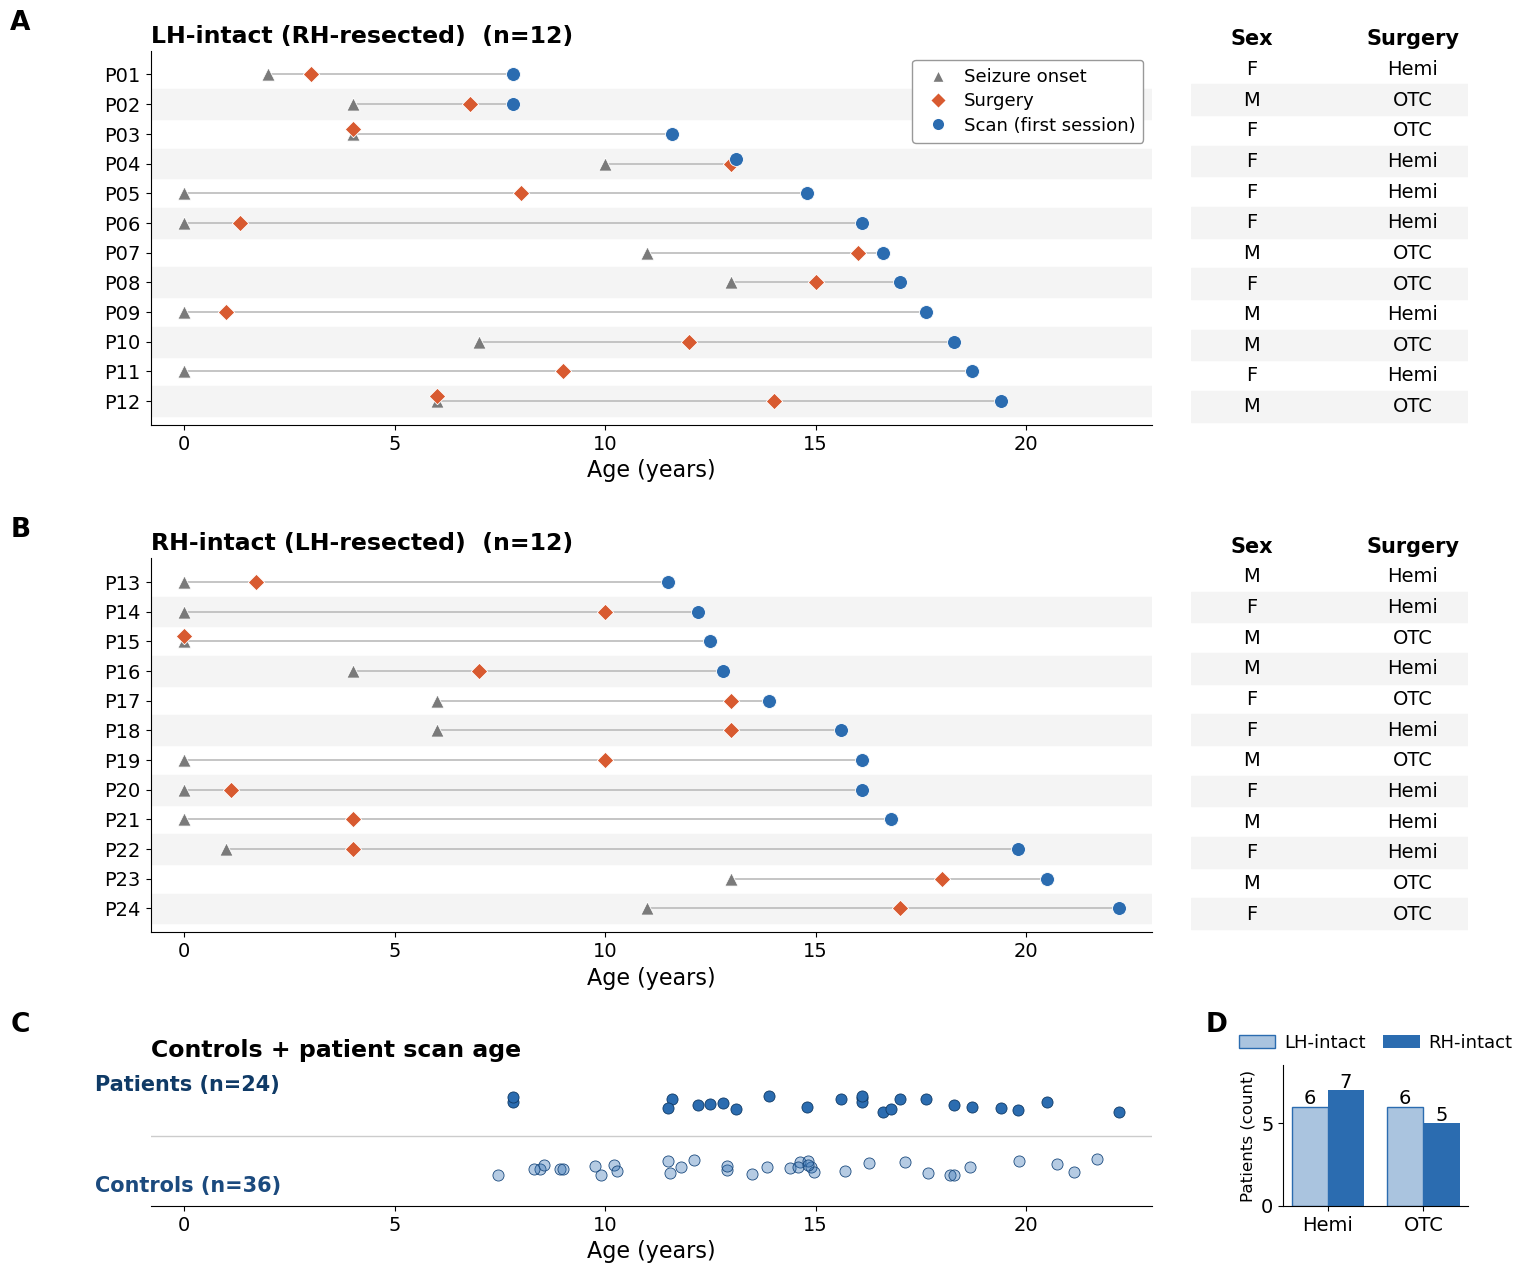

In [5]:
#!/usr/bin/env python
"""
Full cross-sectional figure, one canvas:
  A  LH-intact (RH-resected): timeline + metadata table
  B  RH-intact (LH-resected): timeline + metadata table
  C  Controls + patient scan age (jittered strip)
  D  Surgery type by hemisphere

AGE CAP <= 23 applied. Removes P13 (scan 37.3, = sub-091) and controls
sub-095 (38.5) and sub-096 (27.9). Those three were the only reason for the
37y axis break, so the break axes (axLb/axRb/axSb), the split() helper and the
diagonal break marks are gone. Cohort is now 12 LH-intact / 12 RH-intact and
34 controls.
"""

from matplotlib import gridspec

CSV = str(SUB_INFO)              # from Config
CTRL_EXCLUDE = {"sub-027","sub-084"}

C_SCAN  = "#2B6CB0"
C_EDGE_C= "#1B4A7E"
C_EDGE_P= "#0F3A66"
C_SEIZ, C_SURG = "#7A7A7A", "#D85A30"
LINE, BAND = "#BBBBBB", "#F4F4F4"
C_LH_BAR = (0.169, 0.424, 0.690, 0.40)   # translucent C_SCAN
AGE_MAX = 23
rng = np.random.default_rng(7)

# (pid, sex, surgery, seizure, surgery_age, scan)
LH = [
    ("P01","F","Hemi",  2.0,  3.0,   7.8),
    ("P02","M","OTC",   4.0,  6.8,   7.8),   # = sub-004 (UD in Liu 2025); surgery 6y9m
    ("P03","F","OTC",   4.0,  4.0,  11.6),
    ("P04","F","Hemi", 10.0, 13.0,  13.1),
    ("P05","F","Hemi",  0.0,  8.0,  14.8),
    ("P06","F","Hemi",  0.0,  1.33, 16.11),
    ("P07","M","OTC",  11.0, 16.0,  16.6),
    ("P08","F","OTC",  13.0, 15.0,  17.0),
    ("P09","M","Hemi",  0.0,  1.0,  17.62),
    ("P10","M","OTC",   7.0, 12.0,  18.3),
    ("P11","F","Hemi",  0.0,  9.0,  18.71),
    ("P12","M","OTC",   6.0,(6.0,14.0),19.4),
]
RH = [
    ("P13","M","Hemi",  0.0,  1.7, 11.5),
    ("P14","F","Hemi",  0.0, 10.0, 12.2),
    ("P15","M","OTC",   0.0,  0.0, 12.5),
    ("P16","M","Hemi",  4.0,  7.0, 12.8),
    ("P17","F","OTC",   6.0, 13.0, 13.9),
    ("P18","F","Hemi",  6.0, 13.0, 15.6),
    ("P19","M","OTC",   0.0, 10.0, 16.1),
    ("P20","F","Hemi",  0.0,  1.1, 16.1),
    ("P21","M","Hemi",  0.0,  4.0, 16.8),
    ("P22","F","Hemi",  1.0,  4.0, 19.8),
    ("P23","M","OTC",  13.0, 18.0, 20.5),
    ("P24","F","OTC",  11.0, 17.0, 22.2),
]
assert len(LH) == 12
assert len(RH) == 12
PT_SCAN = np.array([r[5] for r in LH+RH])
assert PT_SCAN.max() <= AGE_CAP, "a patient is above the age cap"

# The plotted scan must follow at least one surgery. Patients with more than
# one operation (surgery_age given as a tuple) can legitimately have a later
# surgery after the scan, so the check is against the EARLIEST surgery.
_su = lambda v: [x for x in (list(v) if isinstance(v,(tuple,list)) else [v])
                 if x is not None]
_bad = [(r[0], _su(r[4]), r[5]) for r in LH+RH if min(_su(r[4])) > r[5]]
if _bad:
    print("WARNING scan precedes all recorded surgeries:",
          ", ".join(f"{p} surgery {s} > scan {c}" for p,s,c in _bad))
COLX = {"Sex":0.22, "Surgery":0.80}

FS_TICK=14; FS_CELL=14; FS_HEADER=15; FS_TITLE=17; FS_XLAB=16; FS_NLAB=15
FS_LETTER=19; FS_LEGEND=13; FS_DLAB=15


def bands(ax, n):
    for r in range(n):
        if r % 2 == 0: ax.axhspan(r-0.5, r+0.5, color=BAND, zorder=0)


def panel_letter(ax, L, dx=-0.12, dy=1.04):
    ax.text(dx, dy, L, transform=ax.transAxes, fontsize=FS_LETTER, fontweight="bold",
            va="bottom", ha="right")


def draw_timeline(ax, rows):
    """One row per patient. Events at the same age are offset vertically so
    seizure onset, surgery and scan do not overlap."""
    n=len(rows); bands(ax,n)
    JIT, WIN = 0.16, 0.6          # vertical offset; collision window in years
    for i,row in enumerate(rows):
        pid,_,_,sz,su,sc=row; y=n-1-i
        su_list=[v for v in (list(su) if isinstance(su,(tuple,list)) else [su])
                 if v is not None]
        ax.plot([min([sz]+su_list+[sc]), max([sz]+su_list+[sc])],[y,y],
                color=LINE,lw=1.2,zorder=1)
        ev = ([(sz,"^",90,C_SEIZ)]
              + [(sv,"D",70,C_SURG) for sv in su_list]
              + [(sc,"o",100,C_SCAN)])
        seen=[]
        for age,mk,ms,col in ev:
            k=sum(1 for a in seen if abs(a-age) < WIN); seen.append(age)
            dy = 0 if k==0 else (JIT if k % 2 else -JIT) * ((k+1)//2)
            ax.scatter(age, y+dy, marker=mk, s=ms, color=col, zorder=3,
                       edgecolors="white", linewidths=.6)
    ax.set_yticks(range(n)); ax.set_yticklabels([r[0] for r in reversed(rows)],fontsize=FS_TICK)
    ax.set_ylim(-0.8,n-0.2); ax.set_xlim(-0.8,AGE_MAX)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)


def draw_table(ax, rows, header=False):
    n=len(rows); bands(ax,n); ax.set_xlim(0,1); ax.set_ylim(-0.6,n-0.4); ax.axis("off")
    for i,row in enumerate(rows):
        sex,surg=row[1],row[2]; y=n-1-i
        ax.text(COLX["Sex"],y,sex,ha="center",va="center",fontsize=FS_CELL)
        ax.text(COLX["Surgery"],y,surg,ha="center",va="center",fontsize=FS_CELL)
    if header:
        for label,x in COLX.items():
            ax.text(x,n-0.35,label,ha="center",va="bottom",fontsize=FS_HEADER,
                    fontweight="bold",clip_on=False)


def draw_strip(ax):
    df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
    ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
    ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
    ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
    n_before=len(ctrl)
    ctrl=ctrl[ctrl["age"]<=AGE_CAP]
    print(f'controls: {n_before} -> {len(ctrl)} after age cap <= {AGE_CAP:.0f}')
    cage=ctrl["age"].values
    ax.axhline(0,color="#CCCCCC",lw=1,zorder=0)
    ax.scatter(PT_SCAN,0.45+rng.uniform(-.12,.12,len(PT_SCAN)),s=64,color=C_SCAN,
               edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    ax.scatter(cage,-0.45+rng.uniform(-.12,.12,len(cage)),s=64,
               facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,
               linewidths=.6,zorder=3)
    ax.set_xlim(-0.8,AGE_MAX); ax.set_ylim(-1,1); ax.set_yticks([])
    ax.spines["top"].set_visible(False); ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)
    ax.set_xlabel("Age (years)",fontsize=FS_XLAB)
    ax.text(-0.055,.82,"Patients (n=" + str(len(PT_SCAN)) + ")",transform=ax.transAxes,
            fontsize=FS_NLAB,color=C_EDGE_P,fontweight="bold")
    ax.text(-0.055,.10,"Controls (n=" + str(len(cage)) + ")",transform=ax.transAxes,
            fontsize=FS_NLAB,color=C_EDGE_C,fontweight="bold")


def draw_surgtype(ax):
    cats=["Hemi","OTC"]
    lh_c=[sum(r[2]==c for r in LH) for c in cats]
    rh_c=[sum(r[2]==c for r in RH) for c in cats]
    x=np.arange(len(cats)); w=0.38
    ax.bar(x-w/2,lh_c,w,label="LH-intact",color=C_LH_BAR,edgecolor=C_SCAN,linewidth=1.0)
    ax.bar(x+w/2,rh_c,w,label="RH-intact",color=C_SCAN)
    for xi,(a,b) in enumerate(zip(lh_c,rh_c)):
        ax.text(xi-w/2,a+0.15,a,ha="center",fontsize=FS_CELL)
        ax.text(xi+w/2,b+0.15,b,ha="center",fontsize=FS_CELL)
    ax.set_xticks(x); ax.set_xticklabels(cats,fontsize=FS_DLAB)
    ax.set_ylabel("Patients (count)",fontsize=FS_DLAB-3)
    ax.set_ylim(0, max(max(lh_c),max(rh_c))+1.5)
    ax.legend(fontsize=FS_LEGEND,frameon=False,loc="lower center",
              bbox_to_anchor=(0.5,0.98),ncol=2,columnspacing=1.0,handletextpad=0.5)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)


fig=plt.figure(figsize=(17,15))
gs=gridspec.GridSpec(3,2,width_ratios=[13,3.6],
                     height_ratios=[len(LH),len(RH),4.5],wspace=0.06,hspace=0.45)

axLm,axLt=fig.add_subplot(gs[0,0]),fig.add_subplot(gs[0,1])
draw_timeline(axLm,LH); draw_table(axLt,LH,header=True)
axLm.set_title("LH-intact (RH-resected)  (n=" + str(len(LH)) + ")",
               fontsize=FS_TITLE,fontweight="bold",loc="left"); panel_letter(axLm,"A")
axLm.set_xlabel("Age (years)",fontsize=FS_XLAB)

axRm,axRt=fig.add_subplot(gs[1,0]),fig.add_subplot(gs[1,1])
draw_timeline(axRm,RH); draw_table(axRt,RH,header=True)
axRm.set_title("RH-intact (LH-resected)  (n=" + str(len(RH)) + ")",
               fontsize=FS_TITLE,fontweight="bold",loc="left"); panel_letter(axRm,"B")
axRm.set_xlabel("Age (years)",fontsize=FS_XLAB)

axSm=fig.add_subplot(gs[2,0])
draw_strip(axSm)
axSm.set_title("Controls + patient scan age",fontsize=FS_TITLE,fontweight="bold",loc="left")
panel_letter(axSm,"C",dy=1.20)

ndg=gs[2,1].subgridspec(1,2,width_ratios=[4.0,8],wspace=0)
axD=fig.add_subplot(ndg[0,1]); draw_surgtype(axD)
panel_letter(axD,"D",dx=-0.30,dy=1.20)

handles=[
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=10,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=9,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=10,label="Scan (first session)"),
]
axLm.legend(handles=handles, loc="upper right", ncol=1, fontsize=FS_LEGEND,
            frameon=True, edgecolor="#999999", framealpha=1.0,
            borderpad=0.45, labelspacing=0.35, handletextpad=0.4, markerscale=0.9)
plt.savefig(FIG_DIR / 'patients_cross_sectional.png', dpi=300, bbox_inches='tight')
plt.show()

## 3 · Representative anatomy
One exemplar per surgery type plus one control. Cut coordinates are per-subject and were tuned by eye.

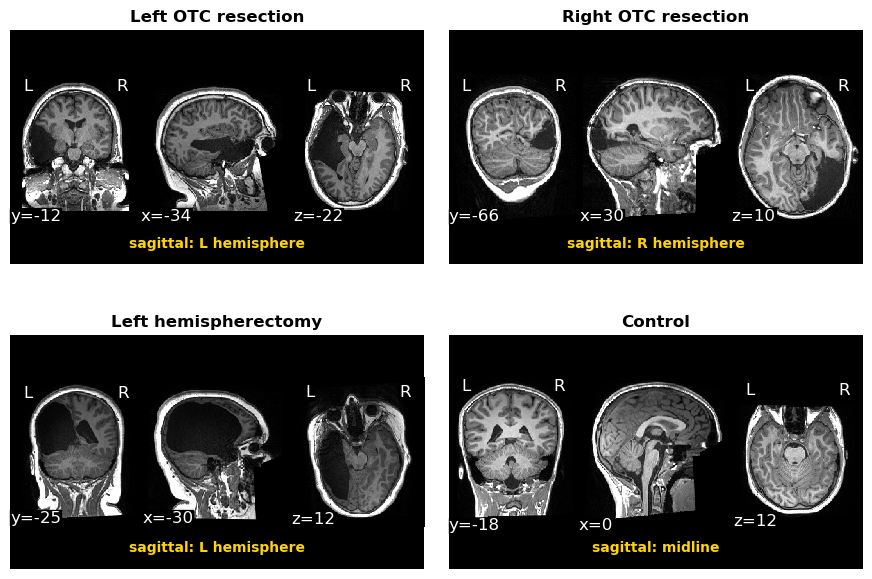

In [6]:
#!/usr/bin/env python
"""
Representative anatomy figure: one exemplar per surgery type + one control = 4 panels (2x2).
RUN ON THE CLUSTER. Cut coords are starting guesses — tune against each scan.
Heads equalized by tight head-bbox crop (world coords preserved). Sagittal (middle)
view labeled with its hemisphere (from cut x-sign).
"""
import os
import nibabel as nib
from matplotlib import gridspec
from nilearn import image, plotting

RAW_DIR = "/lab_data/behrmannlab/hemi/Raw"     # adjust if T1s live elsewhere
SES = "ses-01"
T1  = "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w.nii.gz"
DIM = -1.25

# (row, col, sub, title two-line, (x,y,z) cut)
PANELS = [
    (0,0,"sub-044","Left OTC resection",   (-34,-12,-22)),
    (0,1,"sub-004","Right OTC resection",  ( 30,-66, 10)),
    (1,0,"sub-099","Left hemispherectomy", (-30,-25, 12)),
    (1,1,"sub-094","Control",              (  0,-18, 12)),
]

MARGIN = {"sub-044": 20}   # zero-background frame (voxels); larger = smaller head

def tight_crop(img, margin=6, frac=0.12):
    """Crop to head bbox, then add `margin` voxels of real zero-background on every
    side so the head occupies less of the FOV. World coords preserved."""
    d = img.get_fdata()
    thr = frac * np.percentile(d, 99.5)
    mask = d > thr
    if mask.sum() == 0: return img
    idx = np.array(np.where(mask))
    lo = idx.min(1); hi = idx.max(1) + 1
    sl = tuple(slice(int(a), int(b)) for a, b in zip(lo, hi))
    d = np.pad(d[sl], margin, mode="constant")
    aff = img.affine.copy()
    aff[:3, 3] = aff[:3, 3] + aff[:3, :3].dot(lo - margin)
    return nib.Nifti1Image(d, aff)

def show(ax, sub, title, cut):
    path = T1.format(raw=RAW_DIR, sub=sub, ses=SES)
    if not os.path.exists(path):
        ax.text(0.5,0.5,f"{title}\n(T1 not found)",ha="center",va="center",fontsize=9); ax.axis("off"); return
    anat = tight_crop(image.load_img(path), margin=MARGIN.get(sub, 6))
    plotting.plot_anat(anat, cut_coords=cut, draw_cross=False, dim=DIM, axes=ax, annotate=True)
    ax.set_title(title, fontsize=12, fontweight="bold")
    sag = "midline" if abs(cut[0]) < 5 else ("R hemisphere" if cut[0] > 0 else "L hemisphere")
    ax.text(0.5, 0.06, f"sagittal: {sag}", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#FFD400")

fig = plt.figure(figsize=(11, 7))
gs = gridspec.GridSpec(2, 2, hspace=0.30, wspace=0.06)
for r, c, sub, title, cut in PANELS:
    show(fig.add_subplot(gs[r, c]), sub, title, cut)
plt.savefig(FIG_DIR / 'representative_anatomy.png', dpi=300, bbox_inches='tight')
plt.show()

## 4 · Peak coordinates (MNI)
Reads `peak_coords_mni.csv`. House parcel is `house_PPA_strict`, matching the rest of the figure set.

In [7]:
# ─── Peak-coordinate machinery ───────────────────────────────────────────
# peak_xy() reads an MNI peak from the coords table. Distinct from
# mds_coords() in §9, which embeds a similarity matrix — the two source
# notebooks both called their version `coords`.

pk_c, pk_p = load_harmonized(MNI_CSV, 'peak coords (MNI)', collapse_pairs=True)


def confidence_ellipse(x, y, ax, n_std=1.0, **kw):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson); ry = np.sqrt(1 - pearson)
    e = Ellipse((0, 0), width=2 * rx, height=2 * ry, **kw)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (mtransforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    e.set_transform(t + ax.transData); ax.add_patch(e)


def peak_xy(d, sub, roi, h):
    m = d[(d['subject_id'] == sub) & (d['category'] == roi) & (d['hemi'] == h)]
    if len(m) == 0:
        return None
    x, y = float(m['peak_x_mni'].iloc[0]), float(m['peak_y_mni'].iloc[0])
    return None if (np.isnan(x) or np.isnan(y)) else (x, y)


def intact_of(sub):
    m = pk_p[pk_p['subject_id'] == sub]
    return None if m.empty else ('l' if m['intact_hemi'].iloc[0] == 'left' else 'r')


ctrl_subs_mni = sorted(pk_c['subject_id'].unique())
pt_subs_mni   = sorted(pk_p['subject_id'].unique())
xlim, ylim = (-80, 80), (-100, 0)
midline = (pk_c[pk_c['hemi'] == 'l']['peak_x_mni'].mean()
           + pk_c[pk_c['hemi'] == 'r']['peak_x_mni'].mean()) / 2
print(f'midline estimate: {midline:.1f} mm')

peak coords (MNI): ctrl n=36  pt n=24  {'left': 12, 'right': 12}
midline estimate: 0.3 mm


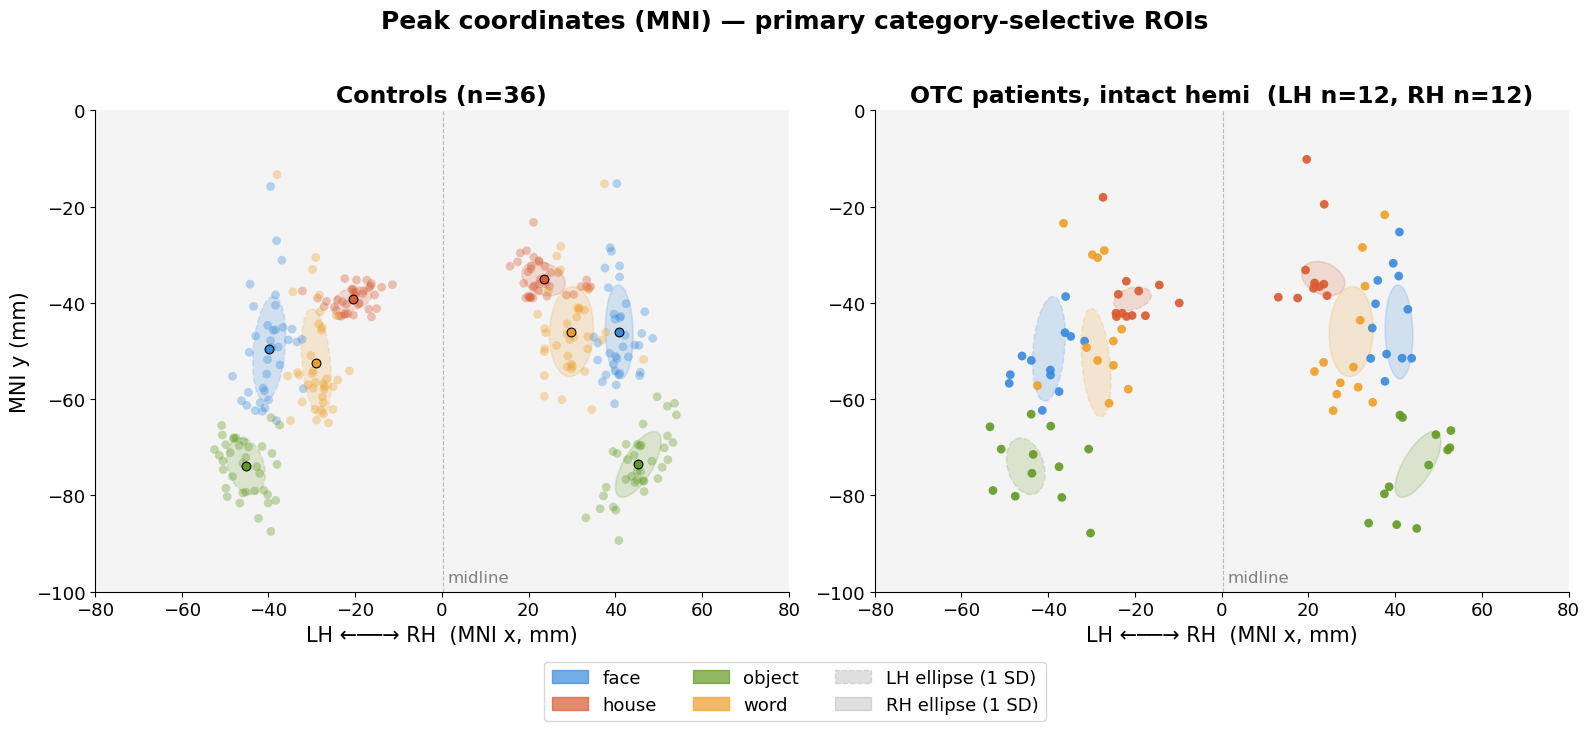

In [8]:
# ─── Peak coordinates plot — primary ROIs ────────────────────────────────
CATS_PRIMARY = [(CAT_PRIMARY[c], CAT_COLORS[c], c)
                for c in ('face', 'house', 'object', 'word')]
n_lh = sum(1 for s in pt_subs_mni if intact_of(s) == 'l')
n_rh = sum(1 for s in pt_subs_mni if intact_of(s) == 'r')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color, _ in CATS_PRIMARY:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [peak_xy(pk_c, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3:
                continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0, facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2, linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=40, edgecolors='none', zorder=2)
                ax.scatter(x.mean(), y.mean(), color=color, s=40, edgecolors='black',
                           linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact_of(sub)
                if pt_h is None:
                    continue
                p = peak_xy(pk_p, sub, roi, pt_h)
                if p is None:
                    continue
                ax.scatter(p[0], p[1], color=color, s=40, edgecolors='none',
                           alpha=0.9, zorder=6)
    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=12, color='gray')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('LH ←──→ RH  (MNI x, mm)', fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=15)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=17, fontweight='bold')
    else:
        ax.set_title(f'OTC patients, intact hemi  (LH n={n_lh}, RH n={n_rh})',
                     fontsize=17, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=lab) for _, c, lab in CATS_PRIMARY]
leg += [Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--',
              label='LH ellipse (1 SD)'),
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',
              label='RH ellipse (1 SD)')]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=13, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — primary category-selective ROIs',
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni_primary.png', dpi=300, bbox_inches='tight')
plt.show()

## 5 · Peak selectivity
`peak_z` — the single highest z inside each ROI's searchmask for that category's contrast, one value per subject × ROI × hemisphere. No directional arrows on the y label: peak z has no interpretive direction.

peak_selectivity: q cells pt-vs-ctrl 8/8, ctrl asym 4/4, pt subgroup 4/4
panels: ['VWFA', 'FFA', 'PPA', 'LO']
  VWFA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  FFA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  PPA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  LO {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}


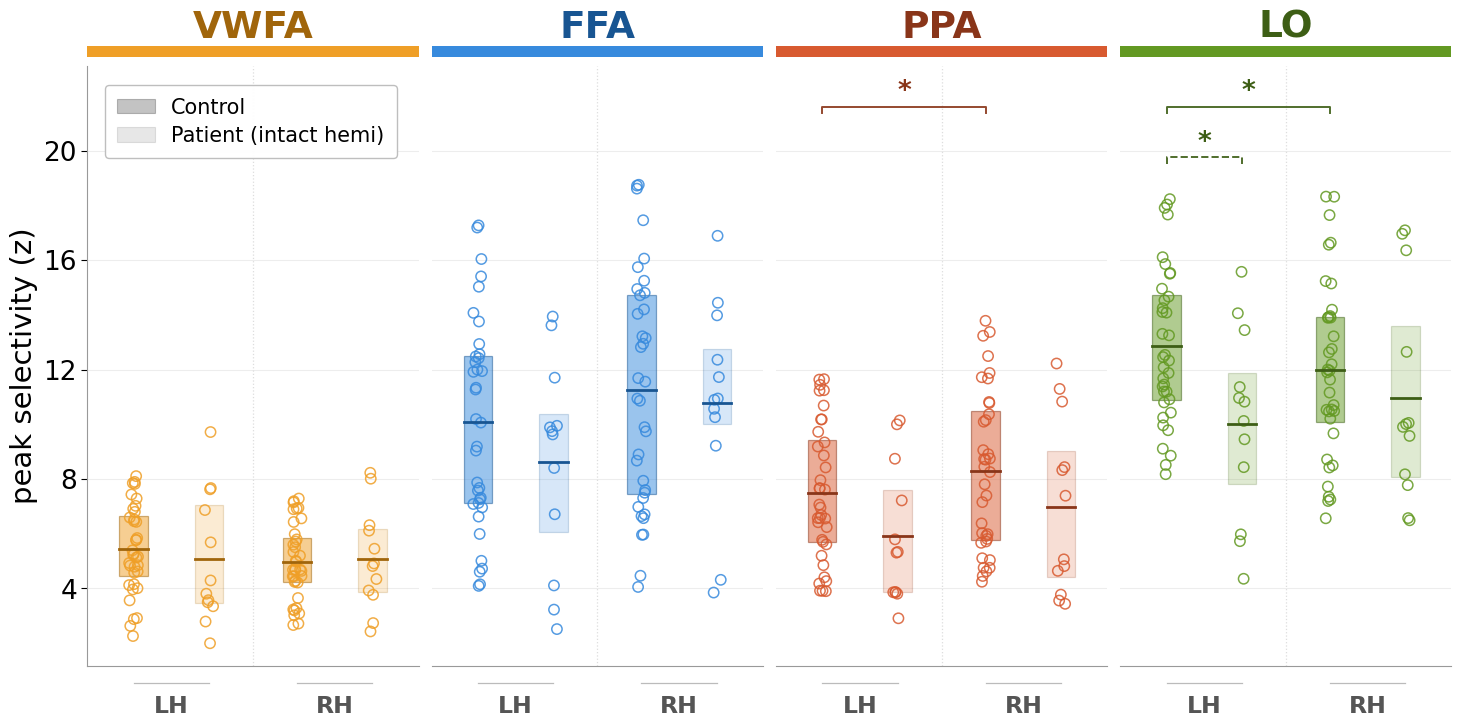

In [9]:
# ─── Peak selectivity ────────────────────────────────────────────────────
Q_PVC_PK, Q_CASY_PK, Q_PSUB_PK = q_sets('peak_selectivity')

panel_row(get_vals=slot_vals(peak_c, peak_p, 'peak_z'),
          rois=ROI_ORDER,
          ylabel='peak selectivity (z)',
          fname='peak_selectivity.png',
          q_pvc=Q_PVC_PK, q_casy=Q_CASY_PK, q_psub=Q_PSUB_PK)

## 6 · Number of category-selective voxels
`volume` is sqrt-transformed before ComBat and left on that scale, so boxes, the mean bar and the q values are all in sqrt(count) units. VWFA, FFA and PPA share one y scale; LO carries its own.

selective_voxels: q cells pt-vs-ctrl 8/8, ctrl asym 4/4, pt subgroup 4/4
panels: ['VWFA', 'FFA', 'PPA', 'LO']
  VWFA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  FFA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  PPA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  LO {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}


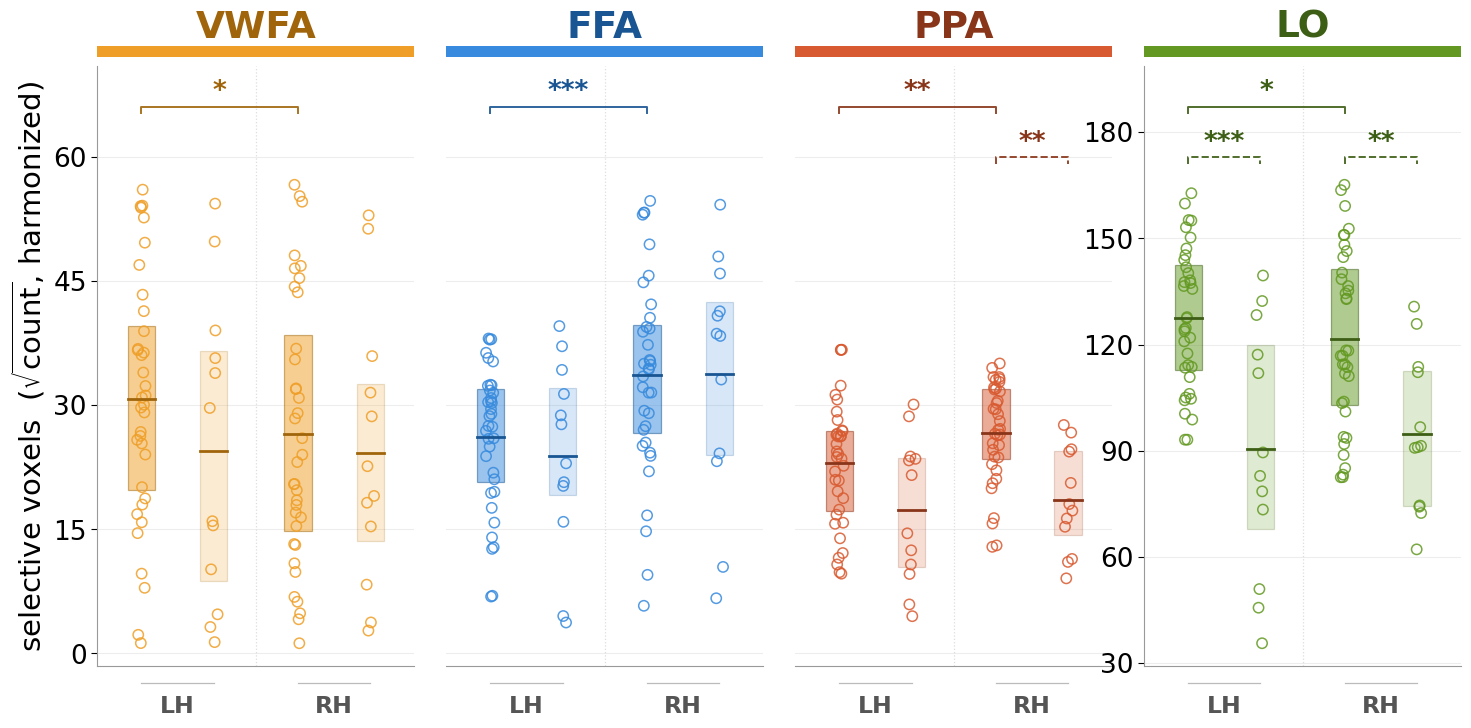

In [10]:
# ─── Number of category-selective voxels ─────────────────────────────────
Q_PVC_VX, Q_CASY_VX, Q_PSUB_VX = q_sets('selective_voxels')

panel_row(get_vals=slot_vals(vox_c, vox_p, 'volume'),
          rois=ROI_ORDER,
          ylabel='selective voxels  ($\\sqrt{\\mathrm{count}}$, harmonized)',
          fname='selective_voxels.png',
          q_pvc=Q_PVC_VX, q_casy=Q_CASY_VX, q_psub=Q_PSUB_VX,
          own_scale={'object_LOC'},
          legend=False)

## 7 · Preferred-category similarity
Raw Fisher-z: higher = more similar = less differentiated.

distinctiveness: q cells pt-vs-ctrl 8/8, ctrl asym 4/4, pt subgroup 4/4
panels: ['VWFA', 'FFA', 'PPA', 'LO']
  VWFA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  FFA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  PPA {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}
  LO {'ctrl L': 36, 'pt L': 12, 'ctrl R': 36, 'pt R': 12}


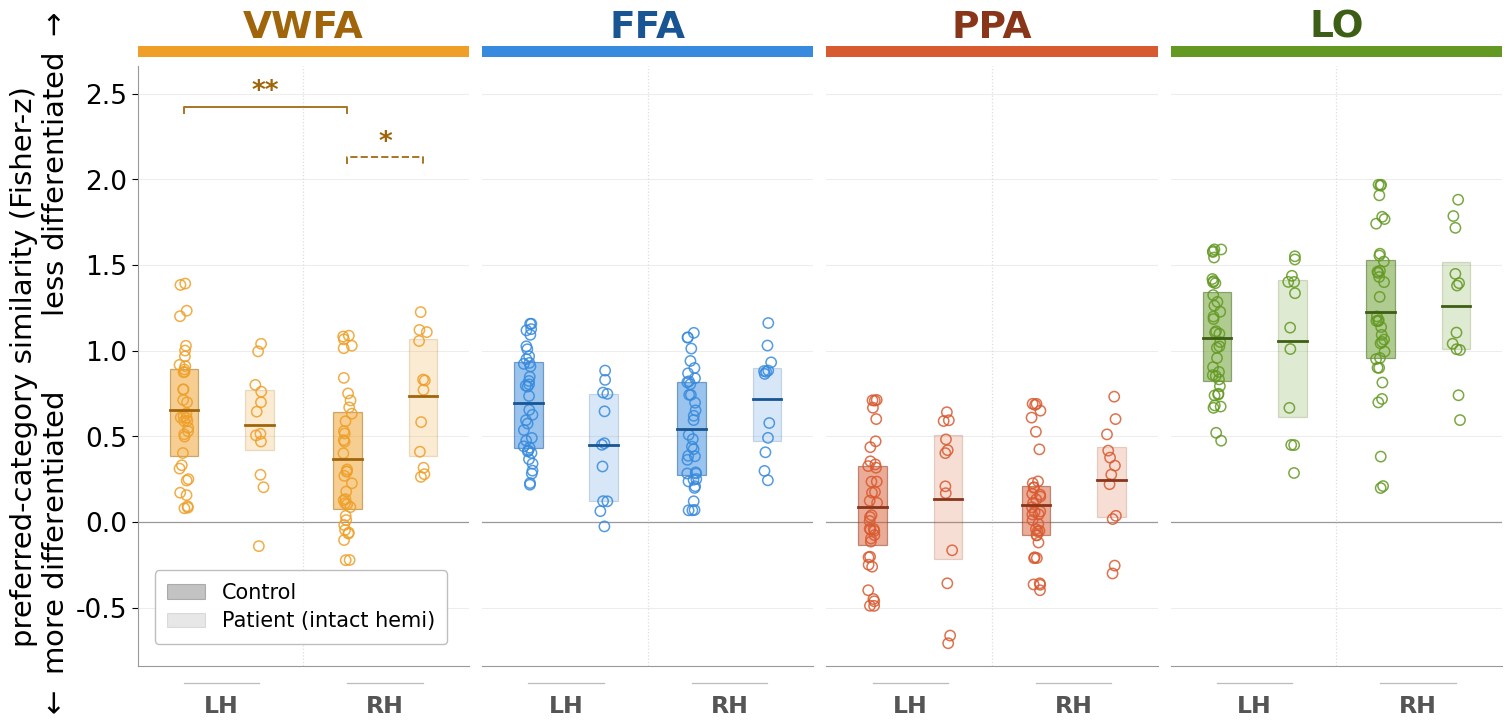

In [11]:
# ─── Preferred-category similarity ───────────────────────────────────────
Q_PVC, Q_CASY, Q_PSUB = q_sets('distinctiveness')

panel_row(get_vals=slot_vals(rsa_c, rsa_p, 'liu_distinctiveness'),
          rois=ROI_ORDER,
          ylabel='preferred-category similarity (Fisher-z)\n'
                 '$\\leftarrow$ more differentiated'
                 '        less differentiated $\\rightarrow$',
          fname='preferred_category_similarity.png',
          q_pvc=Q_PVC, q_casy=Q_CASY, q_psub=Q_PSUB,
          zero_line=True,
          legend_loc='lower left', legend_xy=(0.02, 0.02))

## 8 · Between-category representational similarity
Three rows × four ROIs. Rows: LH-intact vs matched controls, RH-intact vs matched controls, LH-intact vs RH-intact patients. Word-containing pairs left of the dotted line.

`USE_STATS_Q = True` reads per-pair q from `stats_results_harmonized_corrected.csv`. The four values hardcoded in the source cell are kept below only for the printed comparison — set the flag to `False` to plot from them instead.

geometry q cells from STATS_CSV: 48 | q < .05: 5

STATS_CSV vs the hardcoded v3-draft values:
  row       roi               pair              STATS    draft   stars
  LH-intact face_FFA          face-word        0.0234   0.0234     * / *
  RH-intact face_FFA          face-word        0.0006   0.0006   *** / ***
  RH-intact word_VWFA         house-word       0.0054   0.0054    ** / **
  RH-intact word_VWFA         object-word      0.0327   0.0327     * / *


/tmp/ipykernel_4006005/901975400.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hi = max(series[0][0][0][k] + series[0][0][1][k],
/tmp/ipykernel_4006005/901975400.py:77: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series[1][0][0][k] + series[1][0][1][k])
/tmp/ipykernel_4006005/901975400.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hi = max(series[0][0][0][k] + series[0][0][1][k],
/tmp/ipykernel_4006005/901975400.py:7

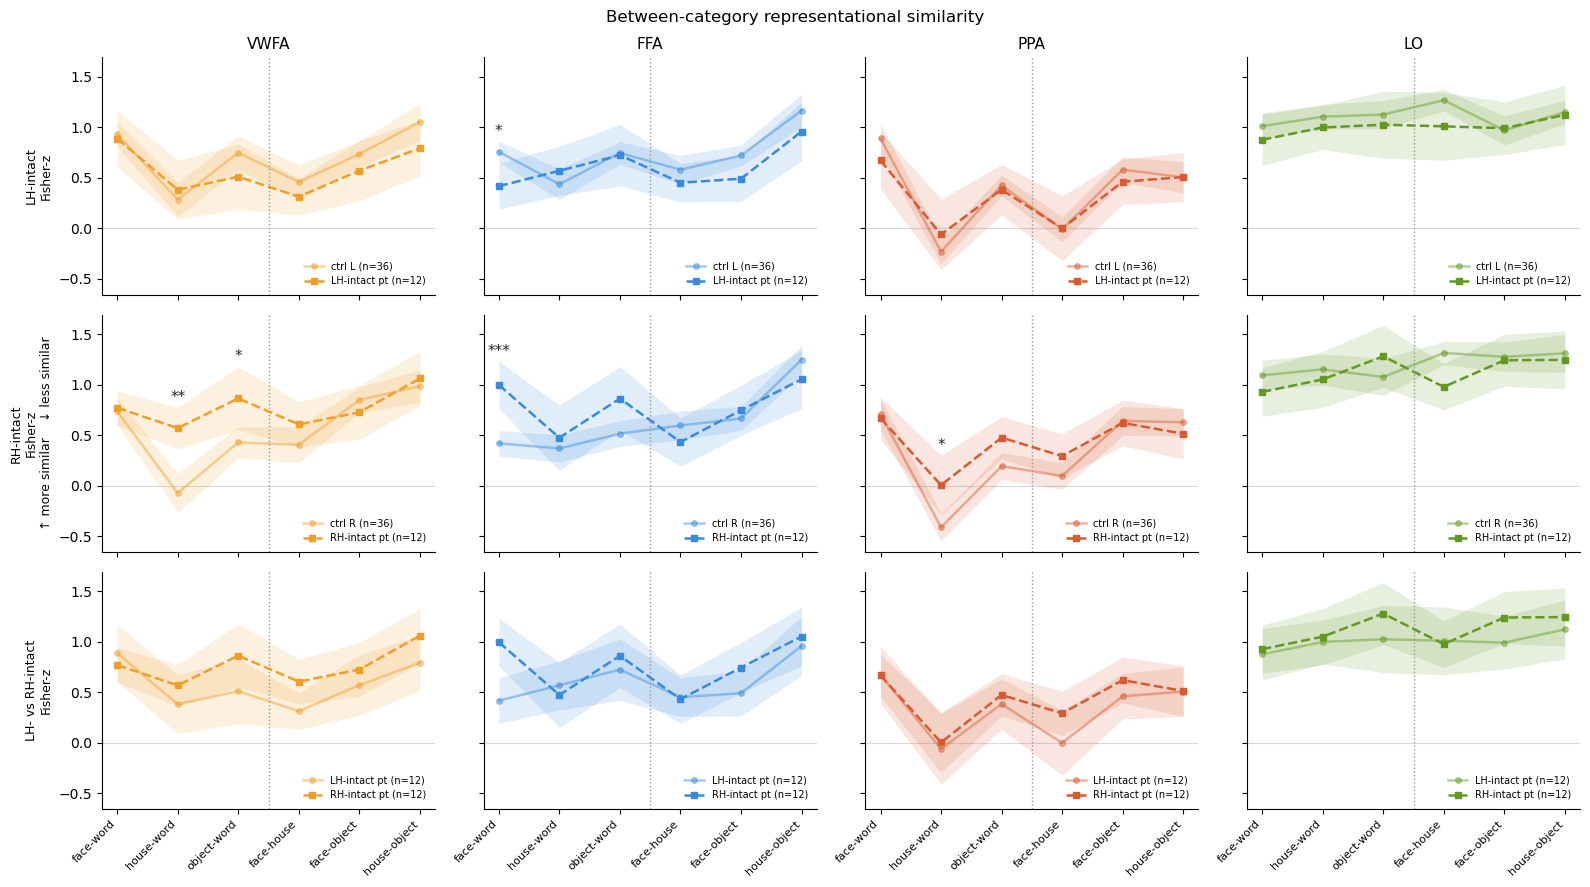

In [12]:
# ─── Between-category profiles ───────────────────────────────────────────
USE_STATS_Q = True
A_CTRL, A_PT = 0.45, 1.0        # line alpha only; patients darker

# Superseded: values as reported in the v3 draft, retained for comparison only.
QVALS_V3_DRAFT = {
    ('LH-intact', 'face_FFA',  'face-word'):   .0234,
    ('RH-intact', 'face_FFA',  'face-word'):   .0006,
    ('RH-intact', 'word_VWFA', 'house-word'):  .0054,
    ('RH-intact', 'word_VWFA', 'object-word'): .0327,
}

_g = STATS[(STATS['measure'] == 'geometry') &
           (STATS['comparison'] == 'patient_vs_control')]
Q_GEO = {}
for r in _g.itertuples():
    m = str(r.model)
    h = 'LH-intact' if 'LH-intact' in m else 'RH-intact' if 'RH-intact' in m else None
    roi = (m.replace('_LH-intact_pt_vs_ctrl', '')
            .replace('_RH-intact_pt_vs_ctrl', ''))
    if h is not None:
        Q_GEO[(h, roi, r.level)] = r.q_fdr
print(f'geometry q cells from STATS_CSV: {len(Q_GEO)}'
      f' | q < .05: {sum(1 for v in Q_GEO.values() if pd.notna(v) and v < .05)}')
print('\nSTATS_CSV vs the hardcoded v3-draft values:')
print(f'  {"row":<10}{"roi":<18}{"pair":<14}{"STATS":>9}{"draft":>9}   stars')
for k, dq in QVALS_V3_DRAFT.items():
    sq = Q_GEO.get(k)
    print(f'  {k[0]:<10}{k[1]:<18}{k[2]:<14}'
          f'{("n/a" if sq is None or pd.isna(sq) else f"{sq:.4f}"):>9}{dq:>9.4f}'
          f'   {stars(sq) or "-":>3} / {stars(dq)}')

QSRC = Q_GEO if USE_STATS_Q else {(k[0], k[1], k[2]): v
                                  for k, v in QVALS_V3_DRAFT.items()}


def _prof(d, roi):
    w = (d[d['category'] == roi]
         .pivot_table(index='subject_id', columns='pair', values='fisher_r')
         .reindex(columns=PAIRS_ORDERED))
    m = w.mean().values
    se = w.std(ddof=1) / np.sqrt(w.notna().sum()) * 1.96
    return m, se, len(w)


x = np.arange(len(PAIRS_ORDERED))
ROWS = [('LH-intact', 'l', 'left'), ('RH-intact', 'r', 'right'),
        ('LH- vs RH-intact', None, None)]

fig, axes = plt.subplots(3, len(ROI_ORDER), figsize=(16, 9), sharex=True, sharey='all')
fig.patch.set_facecolor('white')

for j, roi in enumerate(ROI_ORDER):
    color = CAT_COLORS[ROI_CAT[roi]]
    for i, (row_lab, hemi, intact) in enumerate(ROWS):
        ax = axes[i, j]
        if hemi is not None:
            series = [(_prof(rsa_c_long[rsa_c_long['hemi'] == hemi], roi),
                       f'ctrl {hemi.upper()}', A_CTRL, '-', 'o'),
                      (_prof(rsa_p_long[rsa_p_long['intact_hemi'] == intact], roi),
                       f'{row_lab} pt', A_PT, '--', 's')]
        else:
            series = [(_prof(rsa_p_long[rsa_p_long['intact_hemi'] == 'left'], roi),
                       'LH-intact pt', A_CTRL, '-', 'o'),
                      (_prof(rsa_p_long[rsa_p_long['intact_hemi'] == 'right'], roi),
                       'RH-intact pt', A_PT, '--', 's')]
        for (m, se, n), lab, a, ls, mk in series:
            ax.plot(x, m, ls, marker=mk, color=color, alpha=a, ms=4, lw=1.8,
                    label=f'{lab} (n={n})')
            ax.fill_between(x, m - se, m + se, color=color, alpha=0.15, lw=0)
        ax.axhline(0, color='0.85', lw=0.8, zorder=0)
        ax.axvline(2.5, ls=':', color='0.6', lw=1)
        for k, pr in enumerate(PAIRS_ORDERED):
            st = stars(QSRC.get((row_lab, roi, pr)))
            if st:
                hi = max(series[0][0][0][k] + series[0][0][1][k],
                         series[1][0][0][k] + series[1][0][1][k])
                ax.annotate(st, (k, hi), textcoords='offset points', xytext=(0, 4),
                            ha='center', fontsize=11, color='0.15')
        ax.legend(fontsize=7, frameon=False, loc='lower right')
        ax.spines[['top', 'right']].set_visible(False)
        if i == 0:
            ax.set_title(ROI_TITLE[roi], fontsize=11)
        if j == 0:
            if i == 1:
                ax.set_ylabel(f'{row_lab}\nFisher-z\n'
                              '↑ more similar    ↓ less similar', fontsize=9)
            else:
                ax.set_ylabel(f'{row_lab}\nFisher-z', fontsize=9)
        if i == 2:
            ax.set_xticks(x)
            ax.set_xticklabels(PAIRS_ORDERED, rotation=45, ha='right', fontsize=8)

fig.suptitle('Between-category representational similarity', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'between_category_profiles.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

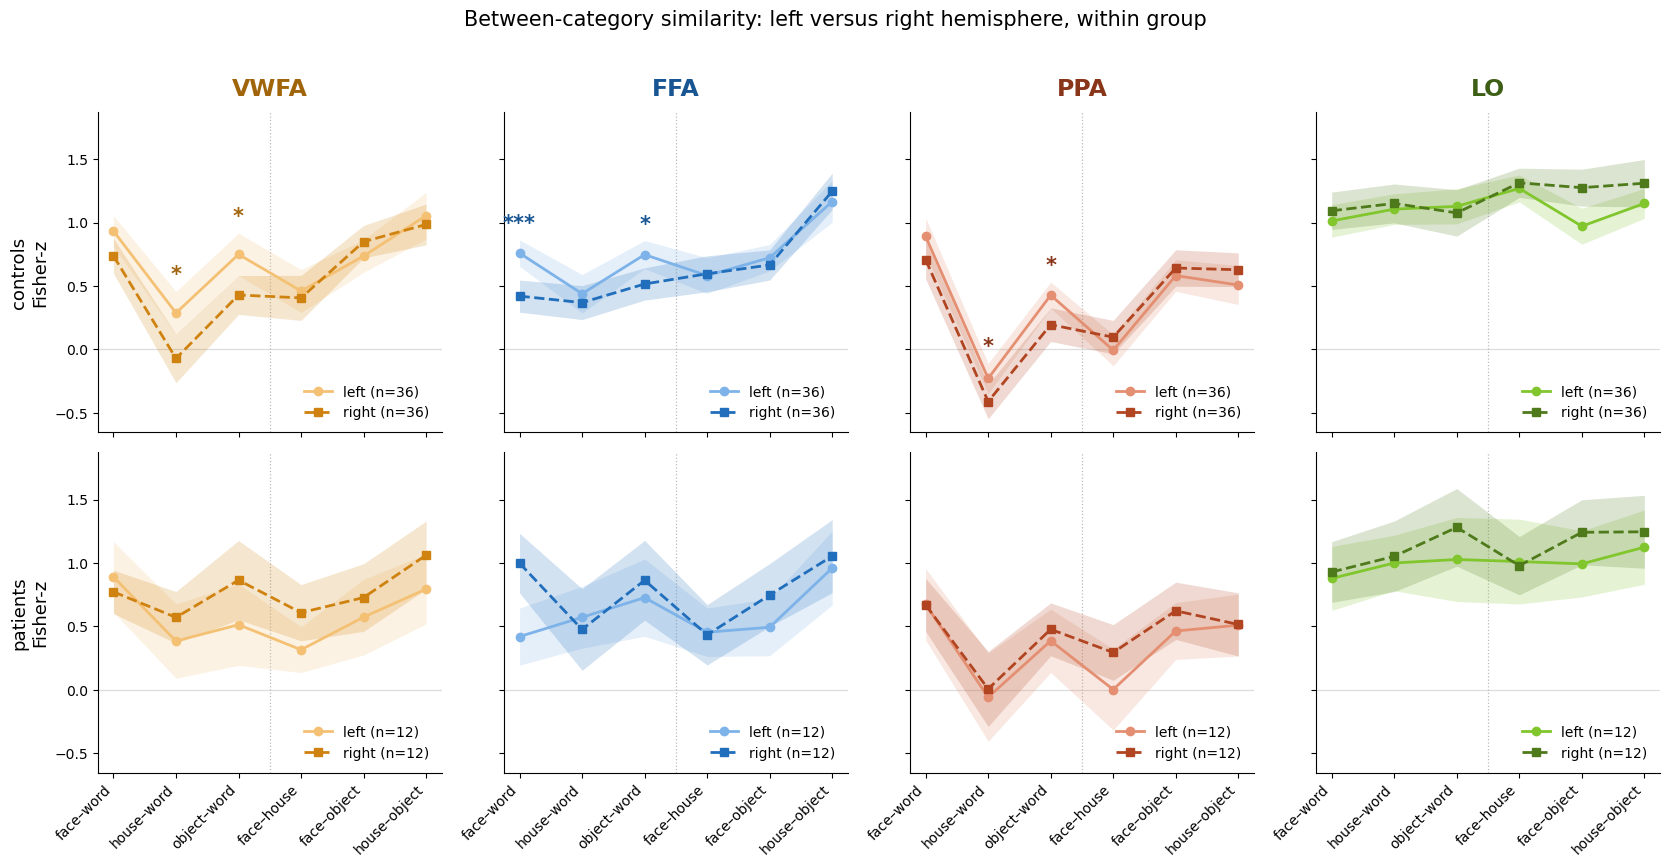

In [13]:
# ─── Between-category similarity: hemispheres within group ───────────────
# Row 1: control left vs control right. Row 2: LH-intact vs RH-intact patients.
# Same axes, so the two rows are directly comparable: controls separate,
# patients overlap.
#
# Asterisks on row 1 come from the control_asymmetry rows of the stats file.
# Row 2 is left unmarked because the stats file has no patient_subgroup rows
# for between-category similarity; the per-ROI omnibus for that comparison is
# null at every ROI (all p >= .113), so there is nothing to mark.

_gg = STATS[STATS['measure'] == 'geometry']
Q_CASY_PAIR = {(r.model.replace('_ctrl_LvsR', ''), r.level): r.q_fdr
               for r in _gg[_gg['model'].str.endswith('ctrl_LvsR')].itertuples()}
OMNI_CASY = {r.model.replace('_ctrl_LvsR', ''): r.omnibus_p
             for r in _gg[(_gg['model'].str.endswith('ctrl_LvsR')) &
                          (_gg['comparison'] == 'omnibus')].itertuples()}

ROWS_WITHIN = [
    ('controls',
     lambda roi, h: rsa_c_long[(rsa_c_long['category'] == roi) &
                               (rsa_c_long['hemi'] == h)],
     True),
    ('patients',
     lambda roi, h: rsa_p_long[(rsa_p_long['category'] == roi) &
                               (rsa_p_long['intact_hemi'] == ('left' if h == 'l' else 'right')) &
                               (rsa_p_long['hemi'] == h)],
     False),
]
HEMI_STYLE = {'l': dict(ls='-',  marker='o', lab='left'),
              'r': dict(ls='--', marker='s', lab='right')}
HEMI_SHADE = {'l': 1.30, 'r': 0.80}

ROIS_LN = [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]
x = np.arange(len(PAIRS_ORDERED))
n_word = sum('word' in p for p in PAIRS_ORDERED)

fig, axes = plt.subplots(len(ROWS_WITHIN), len(ROIS_LN),
                         figsize=(4.2 * len(ROIS_LN), 4.4 * len(ROWS_WITHIN)),
                         sharey=True, sharex=True)
axes = np.atleast_2d(axes)
fig.patch.set_facecolor('white')

for r, (rlab, sel, star_row) in enumerate(ROWS_WITHIN):
    for c, roi in enumerate(ROIS_LN):
        ax = axes[r, c]
        base = CAT_COLORS[ROI_CAT[roi]]
        ax.set_facecolor('white')
        ax.axhline(0, color='#ddd', lw=0.9, zorder=0)
        ax.axvline(n_word - 0.5, color='#bbb', lw=0.9, ls=':', zorder=0)
        hi_by_hemi = {}
        for h in ('l', 'r'):
            d = sel(roi, h)
            m, lo, hi, nn = [], [], [], []
            for pair in PAIRS_ORDERED:
                v = d[d['pair'] == pair]['fisher_r'].dropna().values
                if len(v) < 3:
                    m.append(np.nan); lo.append(np.nan); hi.append(np.nan)
                    continue
                mu = v.mean(); half = 1.96 * v.std(ddof=1) / np.sqrt(len(v))
                m.append(mu); lo.append(mu - half); hi.append(mu + half)
                nn.append(len(v))
            m, lo, hi = map(np.array, (m, lo, hi))
            hi_by_hemi[h] = hi
            col = shade(base, HEMI_SHADE[h])
            st = HEMI_STYLE[h]
            ax.fill_between(x, lo, hi, color=col, alpha=0.20, lw=0, zorder=1)
            ax.plot(x, m, color=col, lw=2.0, ls=st['ls'], marker=st['marker'],
                    ms=6, zorder=2,
                    label=f"{st['lab']} (n={max(nn) if nn else 0})")

        # asterisk just above the taller of the two CIs at that pair
        if star_row and OMNI_CASY.get(roi, 1) < .05:
            top = np.nanmax(np.vstack([hi_by_hemi['l'], hi_by_hemi['r']]), axis=0)
            for i, pair in enumerate(PAIRS_ORDERED):
                s_ = stars(Q_CASY_PAIR.get((roi, pair)))
                if s_ and np.isfinite(top[i]):
                    ax.text(i, top[i] + 0.05, s_, ha='center', va='bottom',
                            fontsize=15, fontweight='bold',
                            color=shade(base, 0.62), clip_on=False)

        if r == 0:
            ax.set_title(ROI_TITLE.get(roi, roi), fontsize=17,
                         fontweight='bold', color=shade(base, 0.62), pad=12)
        if c == 0:
            ax.set_ylabel(f'{rlab}\nFisher-z', fontsize=13)
        ax.legend(frameon=False, fontsize=10, loc='lower right')
        ax.set_xticks(x)
        ax.set_xticklabels([p.replace('-', '\u2013') for p in PAIRS_ORDERED],
                           rotation=45, ha='right', fontsize=10)
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)

# headroom so the asterisks stay inside the axes
axes[0, 0].set_ylim(top=axes[0, 0].get_ylim()[1] + 0.18)

fig.suptitle('Between-category similarity: left versus right hemisphere, within group',
             fontsize=15, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'between_category_within_group.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

## 9 · Procrustes / MDS configuration
Reads `fisher_r` from `rsa_v1_harmonized.csv`, the same harmonized source as §7 and §8 — it reuses the `rsa_*_long` frames already loaded in §1 rather than re-reading anything.

`peak_coords_mni.csv` is still the source for §4, because ComBat harmonizes feature values and not peak coordinates; there is no harmonized equivalent of `peak_x_mni` / `peak_y_mni`.

In [14]:
# ─── MDS data + helpers ──────────────────────────────────────────────────
from scipy.spatial import procrustes
from sklearn.manifold import MDS

np.random.seed(0)
HEMIS = {'l': 'left', 'r': 'right'}

# Harmonized RSA, reusing the long frames from §1 (no second file read).
mds_df = pd.concat([rsa_c_long, rsa_p_long], ignore_index=True)
mds_df = mds_df[mds_df['category'].isin(ROI_ORDER) & mds_df['pair'].notna()].copy()
mds_df['pair_sorted'] = mds_df['pair'].apply(lambda p: '-'.join(sorted(p.split('-'))))
PAIRS_SORTED = sorted(mds_df['pair_sorted'].unique())
assert len(PAIRS_SORTED) == 6, f'expected 6 pairs, got {PAIRS_SORTED}'
print(mds_df.groupby(['category', 'hemi', 'status'])['subject_id']
      .nunique().unstack(fill_value=0))


def stratum(d, roi, hemi):
    s = d[(d['category'] == roi) & (d['hemi'] == hemi)].copy()
    s['grp'] = np.where(s['status'] == 'control', 'control', 'patient')
    return s


def subj_rdm(sub_rows):
    """4x4 similarity matrix on the CATS4 order. fisher_r is Fisher-z, so
    tanh() returns it to the correlation scale."""
    M = np.eye(4)
    for _, row in sub_rows.iterrows():
        a, b = row['pair_sorted'].split('-')
        i, j = CATS4.index(a), CATS4.index(b)
        M[i, j] = M[j, i] = np.tanh(row['fisher_r'])
    return M


def mds_coords(sim_mat):
    """2D metric-MDS embedding of 1 - similarity. Distinct from peak_xy() in §4."""
    M = np.where(np.isnan(sim_mat), 0.0, sim_mat)
    np.fill_diagonal(M, 1.0)
    return MDS(n_components=2, dissimilarity='precomputed',
               random_state=0).fit_transform(1.0 - M)


def subj_mats(s, grp):
    return {sid: subj_rdm(g) for sid, g in s[s['grp'] == grp].groupby('subject_id')
            if g['pair_sorted'].nunique() == 6}

status                 control  patient
category         hemi                  
face_FFA         l          36       12
                 r          36       12
house_PPA_strict l          36       12
                 r          36       12
object_LOC       l          36       12
                 r          36       12
word_VWFA        l          36       12
                 r          36       12


word_VWFA        r  ctrl n=36  pt n=12


/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


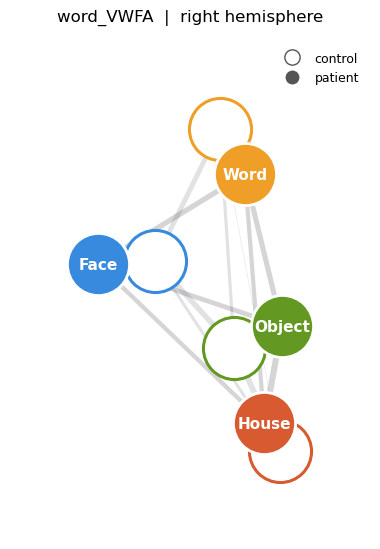

/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


face_FFA         r  ctrl n=36  pt n=12


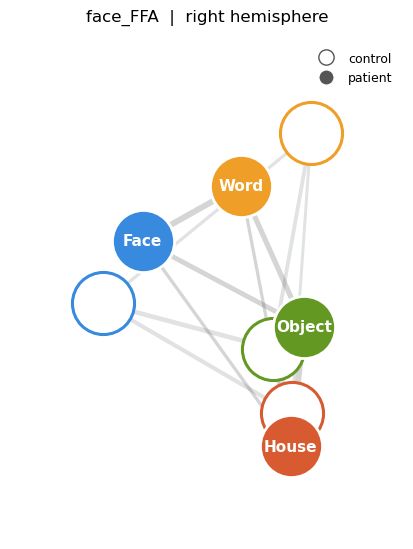

/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


face_FFA         l  ctrl n=36  pt n=12


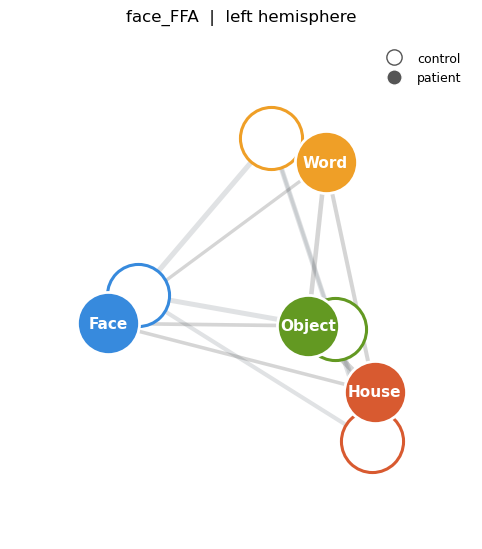

In [15]:
# ─── Procrustes/MDS configuration plots — selected ROI x hemi ────────────
def aligned_configs(s):
    cmats = list(subj_mats(s, 'control').values())
    pmats = list(subj_mats(s, 'patient').values())
    if len(cmats) < 2 or len(pmats) < 1:
        return None
    csim = np.nanmean(np.stack(cmats), axis=0)
    psim = np.nanmean(np.stack(pmats), axis=0)
    mtx1, mtx2, _ = procrustes(mds_coords(csim), mds_coords(psim))
    return csim, psim, mtx1, mtx2, len(cmats), len(pmats)


def plot_procrustes(roi, hemi):
    s = stratum(mds_df, roi, hemi)
    out = aligned_configs(s)
    if out is None:
        print(f'{roi} {hemi}: too few subjects to plot')
        return
    csim, psim, c_xy, p_xy, nc, npt = out
    print(f'{roi:16s} {hemi}  ctrl n={nc}  pt n={npt}')
    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.set_facecolor('white')
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(csim[i, j]), 0, 1)
        ax.plot([c_xy[i, 0], c_xy[j, 0]], [c_xy[i, 1], c_xy[j, 1]], color='#9aa0a6',
                lw=0.4 + r * 5.5, alpha=0.30, solid_capstyle='round', zorder=1)
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(psim[i, j]), 0, 1)
        ax.plot([p_xy[i, 0], p_xy[j, 0]], [p_xy[i, 1], p_xy[j, 1]], color='#444',
                lw=0.4 + r * 5.5, alpha=0.22, solid_capstyle='round', zorder=2)
    for k, cat in enumerate(CATS4):
        ax.scatter(*c_xy[k], s=2000, facecolor='white', edgecolor=CAT_COLORS[cat],
                   linewidth=2.2, zorder=4)
        ax.scatter(*p_xy[k], s=2000, facecolor=CAT_COLORS[cat], edgecolor='white',
                   linewidth=2.0, zorder=5)
        ax.annotate(cat.capitalize(), p_xy[k], fontsize=11, fontweight='bold',
                    color='white', ha='center', va='center', zorder=6)
    ax.set_title(f'{roi}  |  {HEMIS[hemi]} hemisphere', fontsize=12, pad=14)
    ax.set_aspect('equal'); ax.axis('off')
    pad = 0.35
    allxy = np.vstack([c_xy, p_xy])
    ax.set_xlim(allxy[:, 0].min() - pad, allxy[:, 0].max() + pad)
    ax.set_ylim(allxy[:, 1].min() - pad, allxy[:, 1].max() + pad)
    legend = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                         markeredgecolor='#555', markersize=11, label='control'),
              plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#555',
                         markersize=11, label='patient')]
    ax.legend(handles=legend, loc='upper right', frameon=False, fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'procrustes_{roi}_{hemi}.png', dpi=300, bbox_inches='tight')
    plt.show()


SELECTED = [('word_VWFA', 'r'), ('face_FFA', 'r'), ('face_FFA', 'l')]
for roi, hemi in SELECTED:
    plot_procrustes(roi, hemi)

## 10 · TFCE — surviving clusters, Table 2, surface figure
`TFCE_DIR` is the ComBat-harmonized run (set in Config). `tstat1` = ctrl > pt, `tstat2` = pt > ctrl; FWE p < .05 via `rand_tfce_corrp_tstat{N} > 0.95`, 10k permutations. Clusters are discovered from the files, so the figure legend and the table cannot disagree with what survived.

In [16]:
# ─── TFCE setup ──────────────────────────────────────────────────────────
import nibabel as nib
from nilearn import plotting
from scipy import ndimage

CORRP_PATTERN = 'rand_tfce_corrp_tstat{tstat}.nii.gz'
TSTAT_PATTERN = 'rand_tstat{tstat}.nii.gz'
DIRECTION     = {1: 'ctrl>pt', 2: 'pt>ctrl'}

# Reporting floor: 0 reports every surviving voxel. TFCE was chosen because it
# needs no cluster-forming threshold, and corrp > 0.95 is already voxel-level
# FWE, so an extent floor adds no error control. Keep at 0 unless the
# manuscript states otherwise.
MIN_VOX = 0

# Rendering floor: connected components smaller than this are omitted from the
# surface figure only. A handful of voxels cannot be localised on an inflated
# surface and renders as visual noise; the table still reports them. State the
# value in the figure caption, not the Methods.
MIN_VOX_RENDER = 30

print('TFCE_DIR:', TFCE_DIR, '| exists:', TFCE_DIR.exists())
print(f'MIN_VOX (table) = {MIN_VOX}   MIN_VOX_RENDER (figure) = {MIN_VOX_RENDER}')
if TFCE_DIR.exists():
    print('contents:', sorted(p.name for p in TFCE_DIR.iterdir())[:12])

TFCE_DIR: /user_data/csimmon2/sym_pt/group_results/tfce_votc_harmonized | exists: True
MIN_VOX (table) = 0   MIN_VOX_RENDER (figure) = 30
contents: ['comparison_with_without.csv', 'face_l_pt_vs_ctrl', 'face_r_pt_vs_ctrl', 'harmonized_subject_maps', 'house_l_pt_vs_ctrl', 'house_r_pt_vs_ctrl', 'object_l_pt_vs_ctrl', 'object_r_pt_vs_ctrl', 'tfce_summary.BAK_20260809.csv', 'tfce_summary.csv', 'votc_l_mask.nii.gz', 'votc_r_mask.nii.gz']


In [17]:
# ─── Discover surviving clusters (no hardcoded list) ─────────────────────
rows = []
for cat in CATEGORIES:
    for hemi in ('l', 'r'):
        test_dir = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl'
        if not test_dir.exists():
            continue
        for tstat in (1, 2):
            fc = test_dir / CORRP_PATTERN.format(tstat=tstat)
            ft = test_dir / TSTAT_PATTERN.format(tstat=tstat)
            if not fc.exists():
                continue
            corrp_img = nib.load(fc)
            corrp = corrp_img.get_fdata()
            sig = corrp > 0.95
            n_vox = int(sig.sum())
            if n_vox == 0:
                continue
            if ft.exists():
                tvals = nib.load(ft).get_fdata()
                masked_t = np.where(sig, tvals, -np.inf)
                peak_ijk = np.unravel_index(np.argmax(masked_t), masked_t.shape)
                peak_t = float(tvals[peak_ijk])
                peak_mni = nib.affines.apply_affine(corrp_img.affine, peak_ijk)
                peak_pfwe = float(1 - corrp[peak_ijk])
            else:
                peak_t = np.nan; peak_mni = (np.nan,) * 3; peak_pfwe = np.nan
            rows.append(dict(category=cat, hemi=hemi, tstat=tstat,
                             direction=DIRECTION[tstat], n_vox=n_vox,
                             mm3=n_vox * 8, peak_t=peak_t, peak_pfwe=peak_pfwe,
                             x=peak_mni[0], y=peak_mni[1], z=peak_mni[2]))

clusters = pd.DataFrame(rows).sort_values('n_vox', ascending=False).reset_index(drop=True)
print(f'Surviving clusters (FWE p<.05), MIN_VOX={MIN_VOX}:')
print(clusters.round(2).to_string(index=False))

reportable = clusters[clusters['n_vox'] >= MIN_VOX].copy()
below = clusters[clusters['n_vox'] < MIN_VOX]
if len(below):
    print('\nBelow MIN_VOX and therefore excluded from figures/tables:')
    print(below[['category', 'hemi', 'direction', 'n_vox']].to_string(index=False))

CLUSTER_LIST = [(r.category, r.hemi, int(r.tstat),
                 f'{r.category}_{r.hemi.upper()}  {r.direction}')
                for r in reportable.itertuples()]
print('\nGAINS  (pt>ctrl):', [(c, h, t) for c, h, t, _ in CLUSTER_LIST if t == 2])
print('LOSSES (ctrl>pt):', [(c, h, t) for c, h, t, _ in CLUSTER_LIST if t == 1])

Surviving clusters (FWE p<.05), MIN_VOX=0:
category hemi  tstat direction  n_vox   mm3  peak_t  peak_pfwe     x     y     z
  object    l      1   ctrl>pt   1295 10360    4.87       0.00 -54.0 -70.0  -4.0
   house    r      1   ctrl>pt    759  6072    3.92       0.01  30.0 -42.0  -6.0
    word    r      2   pt>ctrl    463  3704    6.46       0.00  48.0 -64.0  -8.0
   house    l      1   ctrl>pt    153  1224    4.07       0.01 -30.0 -46.0  -4.0
  object    r      1   ctrl>pt     54   432    3.86       0.03  34.0 -56.0 -10.0

GAINS  (pt>ctrl): [('word', 'r', 2)]
LOSSES (ctrl>pt): [('object', 'l', 1), ('house', 'r', 1), ('house', 'l', 1), ('object', 'r', 1)]


In [18]:
# ─── BH-FDR across the 8 category x hemisphere comparisons ───────────────
# TFCE gives voxel-level FWE within each test. The reported family is the
# 8 category x hemisphere comparisons, so peak p_FWE values are then
# BH-corrected across all 8 (not just the ones that survived FWE).
# Tests with no surviving voxel enter the family with p_FWE = 1.0.

FAMILY = [(c, h) for c in CATEGORIES for h in ('l', 'r')]

fam_rows = []
for cat, hemi in FAMILY:
    hit = clusters[(clusters.category == cat) & (clusters.hemi == hemi)]
    if len(hit):
        best = hit.loc[hit['peak_pfwe'].idxmin()]
        fam_rows.append(dict(category=cat, hemi=hemi, direction=best.direction,
                             n_vox=int(best.n_vox), peak_t=best.peak_t,
                             p_fwe=float(best.peak_pfwe)))
    else:
        fam_rows.append(dict(category=cat, hemi=hemi, direction='—',
                             n_vox=0, peak_t=np.nan, p_fwe=1.0))
fam = pd.DataFrame(fam_rows)

m = len(fam)
fam = fam.sort_values('p_fwe').reset_index(drop=True)
fam['rank'] = np.arange(1, m + 1)
fam['bh_crit'] = fam['rank'] * 0.05 / m
q, run = np.empty(m), 1.0
for i in range(m - 1, -1, -1):
    run = min(run, fam.loc[i, 'p_fwe'] * m / (i + 1))
    q[i] = run
fam['q_fdr'] = q
fam['survives_fdr'] = fam['q_fdr'] < 0.05

print(f'BH-FDR family: {m} category x hemisphere comparisons, q < .05')
print(fam[['category', 'hemi', 'direction', 'n_vox', 'peak_t',
           'p_fwe', 'rank', 'bh_crit', 'q_fdr', 'survives_fdr']]
      .round(5).to_string(index=False))

REPORTABLE = fam[fam['survives_fdr']][['category', 'hemi', 'direction', 'n_vox']]
print(f'\nReportable ({len(REPORTABLE)}):')
print(REPORTABLE.to_string(index=False))

BH-FDR family: 8 category x hemisphere comparisons, q < .05
category hemi direction  n_vox  peak_t  p_fwe  rank  bh_crit   q_fdr  survives_fdr
  object    l   ctrl>pt   1295 4.87149 0.0001     1  0.00625 0.00080          True
    word    r   pt>ctrl    463 6.46099 0.0044     2  0.01250 0.01653          True
   house    l   ctrl>pt    153 4.07453 0.0062     3  0.01875 0.01653          True
   house    r   ctrl>pt    759 3.92368 0.0085     4  0.02500 0.01700          True
  object    r   ctrl>pt     54 3.86209 0.0256     5  0.03125 0.04096          True
    face    l         —      0     NaN 1.0000     6  0.03750 1.00000         False
    face    r         —      0     NaN 1.0000     7  0.04375 1.00000         False
    word    l         —      0     NaN 1.0000     8  0.05000 1.00000         False

Reportable (5):
category hemi direction  n_vox
  object    l   ctrl>pt   1295
    word    r   pt>ctrl    463
   house    l   ctrl>pt    153
   house    r   ctrl>pt    759
  object    r   ctrl>

In [19]:
# ─── Table 2 values + Harvard-Oxford labels at each peak ─────────────────
from nilearn import datasets as nl_datasets

ho = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho.maps if isinstance(ho.maps, nib.Nifti1Image) else nib.load(ho.maps)
ho_data = ho_img.get_fdata()

# % of OTC uses the per-hemisphere VOTC mask voxel counts
otc_n = {}
for hemi in ('l', 'r'):
    f = TFCE_DIR / f'votc_{hemi}_mask.nii.gz'
    otc_n[hemi] = int((nib.load(f).get_fdata() > 0.5).sum()) if f.exists() else np.nan
print('VOTC mask voxels:', otc_n)

out = []
for r in reportable.itertuples():
    ijk = np.round(nib.affines.apply_affine(np.linalg.inv(ho_img.affine),
                                            (r.x, r.y, r.z))).astype(int)
    try:
        label = ho.labels[int(ho_data[tuple(ijk)])]
    except (IndexError, ValueError):
        label = 'n/a'
    out.append(dict(cluster=f'{r.category}_{r.hemi.upper()}', contrast=r.direction,
                    vox=r.n_vox, mm3=r.mm3,
                    pct_otc=round(100 * r.n_vox / otc_n[r.hemi], 1) if otc_n[r.hemi] else np.nan,
                    peak_mni=f'[{r.x:.0f},{r.y:.0f},{r.z:.0f}]',
                    peak_t=round(r.peak_t, 2), p_fwe=round(r.peak_pfwe, 4),
                    ho_label=label))
table2 = pd.DataFrame(out)
print()
print(table2.to_string(index=False))
table2.to_csv(FIG_DIR / 'table2_tfce_clusters.csv', index=False)

VOTC mask voxels: {'l': 11340, 'r': 11540}

 cluster contrast  vox   mm3  pct_otc     peak_mni  peak_t  p_fwe                                    ho_label
object_L  ctrl>pt 1295 10360     11.4 [-54,-70,-4]    4.87 0.0001 Lateral Occipital Cortex, inferior division
 house_R  ctrl>pt  759  6072      6.6  [30,-42,-6]    3.92 0.0085                               Lingual Gyrus
  word_R  pt>ctrl  463  3704      4.0  [48,-64,-8]    6.46 0.0044 Lateral Occipital Cortex, inferior division
 house_L  ctrl>pt  153  1224      1.3 [-30,-46,-4]    4.07 0.0062                               Lingual Gyrus
object_R  ctrl>pt   54   432      0.5 [34,-56,-10]    3.86 0.0256          Temporal Occipital Fusiform Cortex


In [20]:
# ─── Harvard-Oxford label at each surviving TFCE peak ────────────────────
# Reads the collapsed cluster table straight from tfce_clusters.csv rather than
# re-deriving it, so the labels attach to exactly the values reported.
#
# One row per category x hemisphere: extent is summed across contiguous
# sub-clusters, and the peak is taken from the sub-cluster with the highest
# 1 - p_FWE, matching the convention the manuscript states.
#
# The atlas label is a lookup at a single voxel, not a description of the
# cluster, so it is reported here to be paraphrased in the text rather than
# quoted verbatim.
from nilearn import datasets as nl_datasets

CLUSTER_CSV = REPO / 'D_liu' / 'tfce_clusters.csv'
cl = pd.read_csv(CLUSTER_CSV)
print(f'{len(cl)} sub-clusters read from {CLUSTER_CSV.name}')

# collapse: sum extent, take the peak from the highest-corrp sub-cluster
peak = cl.sort_values('max_corrp').groupby(['category', 'hemi', 'direction']).tail(1)
tot = (cl.groupby(['category', 'hemi', 'direction'])
         .agg(vox=('n_voxels', 'sum'), mm3=('volume_mm3', 'sum'),
              n_sub=('n_voxels', 'size')).reset_index())
cls = tot.merge(peak[['category', 'hemi', 'direction', 'peak_t',
                      'peak_x_mni', 'peak_y_mni', 'peak_z_mni', 'max_corrp']],
                on=['category', 'hemi', 'direction'])
cls['p_fwe'] = (1 - cls['max_corrp']).round(4)

# BH-FDR over the eight category x hemisphere comparisons, not over rows
ALL_CMP = [(c, h) for c in CATEGORIES for h in ('l', 'r')]
pv = {(r.category, r.hemi): r.p_fwe for r in cls.itertuples()}
ordered = sorted([(c, h, pv.get((c, h), 1.0)) for c, h in ALL_CMP], key=lambda z: z[2])
m, prev, qmap = len(ordered), 1.0, {}
for k, (c, h, p) in enumerate(reversed(ordered), start=1):
    prev = min(prev, p * m / (m - k + 1))
    qmap[(c, h)] = prev
cls['q_fdr'] = [round(qmap[(r.category, r.hemi)], 4) for r in cls.itertuples()]

# atlas lookup
ho = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho.maps if isinstance(ho.maps, nib.Nifti1Image) else nib.load(ho.maps)
ho_dat = ho_img.get_fdata()
inv = np.linalg.inv(ho_img.affine)

labels = []
for r in cls.itertuples():
    ijk = np.round(nib.affines.apply_affine(
        inv, (r.peak_x_mni, r.peak_y_mni, r.peak_z_mni))).astype(int)
    try:
        labels.append(ho.labels[int(ho_dat[tuple(ijk)])])
    except (IndexError, ValueError):
        labels.append('n/a')
cls['ho_label'] = labels

cls = cls.sort_values(['category', 'hemi']).reset_index(drop=True)
cls['peak_mni'] = [f'[{r.peak_x_mni:.0f}, {r.peak_y_mni:.0f}, {r.peak_z_mni:.0f}]'
                   for r in cls.itertuples()]
pd.set_option('display.width', 250)
pd.set_option('display.max_colwidth', 46)
print()
print(cls[['category', 'hemi', 'direction', 'vox', 'mm3', 'n_sub',
           'peak_t', 'peak_mni', 'p_fwe', 'q_fdr', 'ho_label']].to_string(index=False))
cls.to_csv(FIG_DIR / 'tfce_clusters_collapsed.csv', index=False)
print(f'\nsaved: {FIG_DIR / "tfce_clusters_collapsed.csv"}')

# sub-cluster detail, for the supplemental table
print('\nsub-clusters, with the atlas label at each peak:')
sub = cl.copy()
sl = []
for r in sub.itertuples():
    ijk = np.round(nib.affines.apply_affine(
        inv, (r.peak_x_mni, r.peak_y_mni, r.peak_z_mni))).astype(int)
    try:
        sl.append(ho.labels[int(ho_dat[tuple(ijk)])])
    except (IndexError, ValueError):
        sl.append('n/a')
sub['ho_label'] = sl
sub['peak_mni'] = [f'[{r.peak_x_mni:.0f}, {r.peak_y_mni:.0f}, {r.peak_z_mni:.0f}]'
                   for r in sub.itertuples()]
print(sub.sort_values(['category', 'hemi', 'n_voxels'], ascending=[True, True, False])
        [['category', 'hemi', 'direction', 'n_voxels', 'volume_mm3',
          'peak_t', 'peak_mni', 'max_corrp', 'ho_label']].to_string(index=False))

14 sub-clusters read from tfce_clusters.csv

category hemi direction  vox   mm3  n_sub  peak_t       peak_mni  p_fwe  q_fdr                                    ho_label
   house    l   ctrl>pt  153  1224      3    4.00 [-30, -50, -4] 0.0062 0.0124                               Lingual Gyrus
   house    r   ctrl>pt  759  6072      3    3.77  [28, -78, 16] 0.0025 0.0100 Lateral Occipital Cortex, superior division
  object    l   ctrl>pt 1295 10360      2    4.51 [-54, -72, -6] 0.0001 0.0008 Lateral Occipital Cortex, inferior division
  object    r   ctrl>pt   54   432      1    3.86 [34, -56, -10] 0.0256 0.0410          Temporal Occipital Fusiform Cortex
    word    r   pt>ctrl  463  3704      5    6.46  [48, -64, -8] 0.0044 0.0117 Lateral Occipital Cortex, inferior division

saved: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact/tfce_clusters_collapsed.csv

sub-clusters, with the atlas label at each peak:
category hemi direction  n_voxels  volume_mm3  peak_t        peak_

In [ ]:
# ─── TFCE clusters on inflated surfaces ──────────────────────────────────
# Plots only clusters surviving BH-FDR across the 8 category x hemisphere
# comparisons (cell above). Requires REPORTABLE.
#
# Inflated surface, vol_to_surf kind='line' / interpolation='linear',
# vertex threshold 0.3. Connected components below MIN_VOX_RENDER are omitted
# from the render only: a handful of voxels cannot be localised on an inflated
# surface and shows as visual noise. Those voxels survive FWE and remain in
# Table 2, so the floor is a visibility choice and belongs in the figure
# caption, not the Methods.
from matplotlib.colors import ListedColormap
from nilearn import surface
from nilearn.plotting import plot_surf_roi

CAT_INT   = {'face': 1, 'house': 2, 'object': 3, 'word': 4}
TSTAT_FOR = {'ctrl>pt': 1, 'pt>ctrl': 2}

GAINS_FDR  = [(r.category, r.hemi, TSTAT_FOR[r.direction])
              for r in REPORTABLE.itertuples() if r.direction == 'pt>ctrl']
LOSSES_FDR = [(r.category, r.hemi, TSTAT_FOR[r.direction])
              for r in REPORTABLE.itertuples() if r.direction == 'ctrl>pt']
print('GAINS_FDR :', GAINS_FDR)
print('LOSSES_FDR:', LOSSES_FDR)

VIEWS = {
    'l': [('lateral-posterior', 'lateral', (10, -150)),
          ('ventral',           'ventral', None)],
    'r': [('lateral-posterior', 'lateral', (10,  -30)),
          ('ventral',           'ventral', None)],
}

fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
cat_cmap = ListedColormap(['#cccccc'] + [CAT_COLORS[c] for c in CATEGORIES])


def project_clusters_to_surface(cluster_list, hemi, min_vox=MIN_VOX_RENDER,
                                report=None):
    """Combine clusters in one hemisphere into a single surface map.

    vertex value = CAT_INT for that category, 0 elsewhere. Connected components
    below min_vox are dropped from the render; if `report` is a list, each drop
    is appended to it as (category, hemi, direction, [component sizes]).
    """
    hemi_full = 'left' if hemi == 'l' else 'right'
    n_vert = surface.load_surf_mesh(fsaverage[f'infl_{hemi_full}'])[0].shape[0]
    out = np.zeros(n_vert, dtype=np.int16)
    for cat, h, tstat in cluster_list:
        if h != hemi:
            continue
        fpath = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl' / CORRP_PATTERN.format(tstat=tstat)
        vol_img = nib.load(fpath)
        sig = vol_img.get_fdata() > 0.95

        lab, n_comp = ndimage.label(sig)
        if n_comp:
            sizes = ndimage.sum(sig, lab, range(1, n_comp + 1))
            keep_ids = [i + 1 for i, s in enumerate(sizes) if s >= min_vox]
            dropped = sorted((int(s) for s in sizes if s < min_vox), reverse=True)
            keep = np.isin(lab, keep_ids) if keep_ids else np.zeros_like(sig)
        else:
            dropped, keep = [], np.zeros_like(sig)
        if report is not None and dropped:
            report.append((cat, h, DIRECTION[tstat], dropped))

        sig_img = nib.Nifti1Image(keep.astype(np.float32), vol_img.affine)
        surf_vals = surface.vol_to_surf(
            sig_img, fsaverage[f'pial_{hemi_full}'],
            radius=3.0, kind='line', interpolation='linear',
        )
        out[surf_vals > 0.3] = CAT_INT[cat]
    return out


for label, cluster_list, tag in [
        ('Patients > Controls  (territory gains)', GAINS_FDR,  'gains'),
        ('Controls > Patients  (territory losses)', LOSSES_FDR, 'losses')]:
    if not cluster_list:
        print(f'no FDR-surviving clusters for: {label}')
        continue
    present = [c for c in CATEGORIES if c in {x[0] for x in cluster_list}]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': '3d'})
    fig.suptitle(label, fontsize=13, y=0.98)

    dropped_report = []
    for col, (hemi, hemi_full) in enumerate([('l', 'left'), ('r', 'right')]):
        roi_map = project_clusters_to_surface(
            cluster_list, hemi, report=dropped_report).astype(float)
        for row, (view_label, view_named, view_custom) in enumerate(VIEWS[hemi]):
            plot_surf_roi(
                fsaverage[f'infl_{hemi_full}'], roi_map=roi_map,
                hemi=hemi_full, view=view_named,
                cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
                bg_map=fsaverage[f'sulc_{hemi_full}'],
                bg_on_data=True, darkness=0.6,
                axes=axes[row, col], figure=fig,
            )
            if view_custom is not None:
                elev, azim = view_custom
                axes[row, col].view_init(elev=elev, azim=azim)
            axes[row, col].set_title(f'{hemi_full.upper()}H — {view_label}', fontsize=10)

    handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in present]
    fig.legend(handles=handles, loc='lower center', ncol=len(present),
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(FIG_DIR / f'tfce_surface_fdr_{tag}.png', dpi=300, bbox_inches='tight')
    plt.show()

    if dropped_report:
        print(f'  omitted from render (< {MIN_VOX_RENDER} vox, still reportable):')
        for cat, h, direc, sizes in dropped_report:
            print(f'    {cat}_{h.upper()} {direc}: components of {sizes}')

GAINS_FDR : [('word', 'r', 2)]
LOSSES_FDR: [('object', 'l', 1), ('house', 'l', 1), ('house', 'r', 1), ('object', 'r', 1)]


In [ ]:
print('CATEGORIES:', list(CATEGORIES))
print('CAT_INT   :', CAT_INT)
for c in CATEGORIES:
    slot = list(CATEGORIES).index(c) + 1
    print(f'{c:7} CAT_INT={CAT_INT[c]}  cmap slot={slot}  '
          f'{"OK" if CAT_INT[c] == slot else "MISMATCH"}')

CATEGORIES: ['face', 'house', 'object', 'word']
CAT_INT   : {'face': 1, 'house': 2, 'object': 3, 'word': 4}
face    CAT_INT=1  cmap slot=1  OK
house   CAT_INT=2  cmap slot=2  OK
object  CAT_INT=3  cmap slot=3  OK
word    CAT_INT=4  cmap slot=4  OK


## 11 · QC — not a manuscript figure
Significant t-stats on the standard brain, one row per surviving cluster. Per-cluster t range is narrow, so `vmax` is set per panel; colorbars are not comparable across rows.

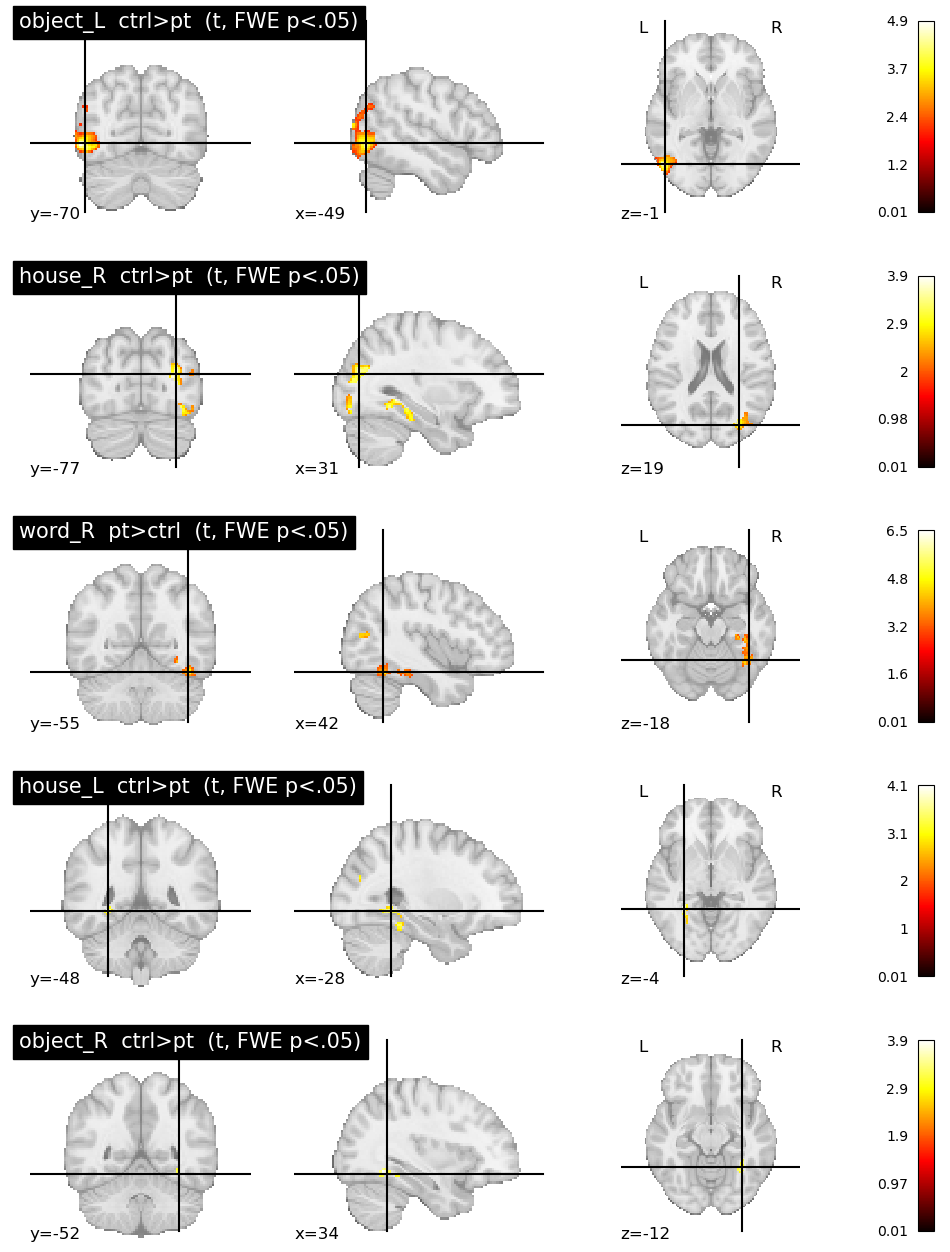

In [ ]:
# ─── QC: FWE-significant t-stats on the standard brain (ortho cuts) ──────
n = len(CLUSTER_LIST)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n))
axes = np.atleast_1d(axes)
for ax, (cat, hemi, tstat, title) in zip(axes, CLUSTER_LIST):
    test_dir = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl'
    corrp_img = nib.load(test_dir / CORRP_PATTERN.format(tstat=tstat))
    tstat_img = nib.load(test_dir / TSTAT_PATTERN.format(tstat=tstat))
    tstat_data = tstat_img.get_fdata() * (corrp_img.get_fdata() > 0.95)
    masked = nib.Nifti1Image(tstat_data, tstat_img.affine)
    vmax = float(tstat_data.max()) if tstat_data.max() > 0 else 1.0
    plotting.plot_stat_map(masked, threshold=0.01, display_mode='ortho',
                           colorbar=True, cmap='hot', vmax=vmax,
                           title=f'{title}  (t, FWE p<.05)', axes=ax)
plt.show()

# Play ground

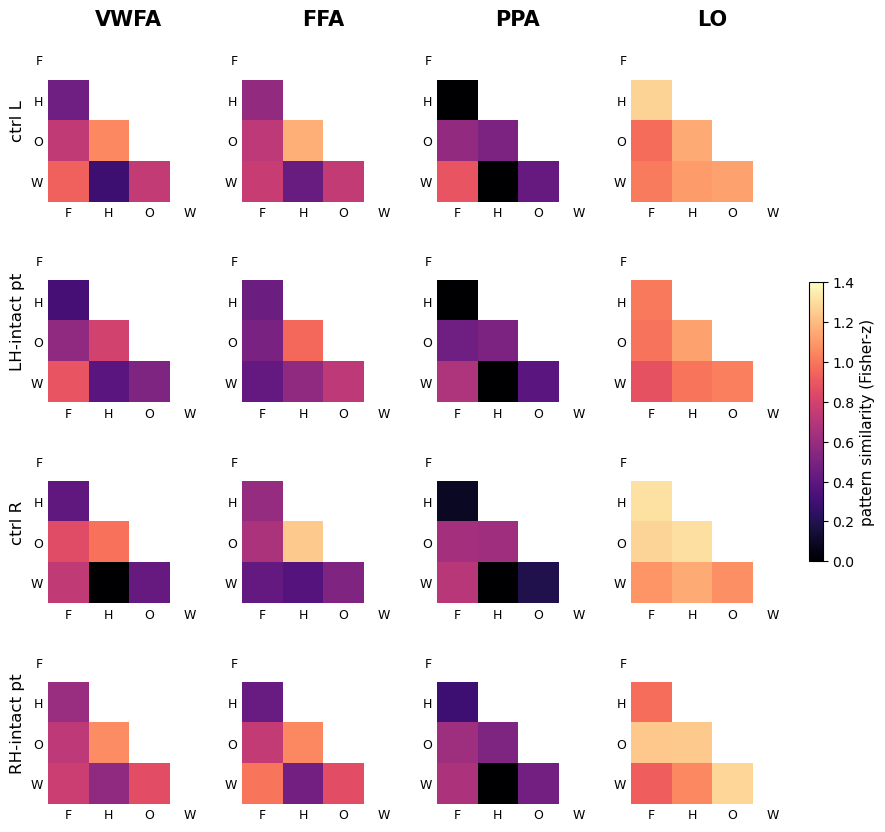

In [ ]:
# =========================================================================
# CELL 1 · Absolute similarity matrices, four groups x four ROIs
# Conventional RSM display: what the six pairs actually look like.
# =========================================================================
from matplotlib.colors import TwoSlopeNorm
 
CAT_LBL = [c[0].upper() for c in CATEGORIES]
NC = len(CATEGORIES)
 
PAIR_IJ = {}
for i, a in enumerate(CATEGORIES):
    for j, b in enumerate(CATEGORIES):
        if i < j:
            PAIR_IJ[f'{a}-{b}'] = PAIR_IJ[f'{b}-{a}'] = (i, j)
 
 
def _mean_matrix(df, roi, hemi, intact=None):
    """Group-mean 4x4 Fisher-z matrix; lower triangle filled, rest NaN."""
    d = df[(df['category'] == roi) & (df['hemi'] == hemi)]
    if intact is not None:
        d = d[d['intact_hemi'] == intact]
    M = np.full((NC, NC), np.nan)
    for pair, g in d.groupby('pair'):
        if pair in PAIR_IJ:
            i, j = PAIR_IJ[pair]
            M[max(i, j), min(i, j)] = g['fisher_r'].mean()
    return M
 
 
ROWS_ABS = [('ctrl L',        lambda roi: _mean_matrix(rsa_c_long, roi, 'l')),
            ('LH-intact pt',  lambda roi: _mean_matrix(rsa_p_long, roi, 'l', 'left')),
            ('ctrl R',        lambda roi: _mean_matrix(rsa_c_long, roi, 'r')),
            ('RH-intact pt',  lambda roi: _mean_matrix(rsa_p_long, roi, 'r', 'right'))]
 
ROIS_RSM = [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]
vmin, vmax = 0.0, 1.4
 
fig, axes = plt.subplots(len(ROWS_ABS), len(ROIS_RSM),
                         figsize=(2.5 * len(ROIS_RSM), 2.5 * len(ROWS_ABS)))
fig.patch.set_facecolor('white')
for r, (rlab, fn) in enumerate(ROWS_ABS):
    for c, roi in enumerate(ROIS_RSM):
        ax = axes[r, c]
        im = ax.imshow(fn(roi), cmap='magma', vmin=vmin, vmax=vmax)
        ax.set_xticks(range(NC)); ax.set_xticklabels(CAT_LBL, fontsize=9)
        ax.set_yticks(range(NC)); ax.set_yticklabels(CAT_LBL, fontsize=9)
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(False)
        if r == 0:
            ax.set_title(ROI_TITLE.get(roi, roi), fontsize=15,
                         fontweight='bold', pad=10)
        if c == 0:
            ax.set_ylabel(rlab, fontsize=12)
cb = fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02)
cb.set_label('pattern similarity (Fisher-z)', fontsize=11)
fig.savefig(FIG_DIR / 'rsm_absolute.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

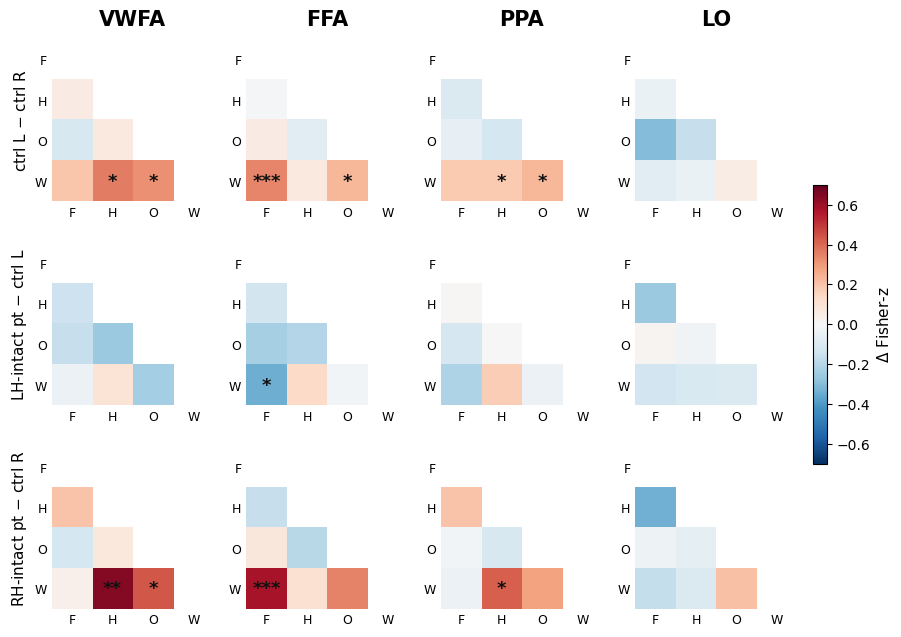

In [ ]:
# =========================================================================
# CELL 2 · Difference matrices with FDR markers
# One row per comparison the manuscript reports, so the panels map onto the
# per-pair tests. Asterisks come straight from the stats file.
# =========================================================================
_g = STATS[STATS['measure'] == 'geometry'].copy()


def _q_lookup(model_suffix):
    """{(roi, pair): q} for one comparison, from the packed `model` column."""
    d = _g[_g['model'].str.endswith(model_suffix)]
    out = {}
    for r in d.itertuples():
        roi = r.model[:-(len(model_suffix) + 1)]
        out[(roi, r.level)] = r.q_fdr
    return out


def _omni_lookup(model_suffix):
    d = _g[(_g['model'].str.endswith(model_suffix)) & (_g['comparison'] == 'omnibus')]
    return {r.model[:-(len(model_suffix) + 1)]: r.omnibus_p for r in d.itertuples()}


ROWS_DIFF = [
    ('ctrl L $-$ ctrl R',
     lambda roi: _mean_matrix(rsa_c_long, roi, 'l') - _mean_matrix(rsa_c_long, roi, 'r'),
     _q_lookup('ctrl_LvsR'), _omni_lookup('ctrl_LvsR')),
    ('LH-intact pt $-$ ctrl L',
     lambda roi: _mean_matrix(rsa_p_long, roi, 'l', 'left') - _mean_matrix(rsa_c_long, roi, 'l'),
     _q_lookup('LH-intact_pt_vs_ctrl'), _omni_lookup('LH-intact_pt_vs_ctrl')),
    ('RH-intact pt $-$ ctrl R',
     lambda roi: _mean_matrix(rsa_p_long, roi, 'r', 'right') - _mean_matrix(rsa_c_long, roi, 'r'),
     _q_lookup('RH-intact_pt_vs_ctrl'), _omni_lookup('RH-intact_pt_vs_ctrl')),
]

lim = 0.7
fig, axes = plt.subplots(len(ROWS_DIFF), len(ROIS_RSM),
                         figsize=(2.5 * len(ROIS_RSM), 2.5 * len(ROWS_DIFF)))
fig.patch.set_facecolor('white')
for r, (rlab, fn, QL, OM) in enumerate(ROWS_DIFF):
    for c, roi in enumerate(ROIS_RSM):
        ax = axes[r, c]
        D = fn(roi)
        im = ax.imshow(D, cmap='RdBu_r',
                       norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim))
        gate_open = OM.get(roi, np.nan) < .05
        for pair, (i, j) in PAIR_IJ.items():
            s = stars(QL.get((roi, pair))) if gate_open else ''
            if s:
                ax.text(min(i, j), max(i, j), s, ha='center', va='center',
                        fontsize=13, fontweight='bold', color='#111')
        ax.set_xticks(range(NC)); ax.set_xticklabels(CAT_LBL, fontsize=9)
        ax.set_yticks(range(NC)); ax.set_yticklabels(CAT_LBL, fontsize=9)
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(False)
        if r == 0:
            ax.set_title(ROI_TITLE.get(roi, roi), fontsize=15,
                         fontweight='bold', pad=10)
        if c == 0:
            ax.set_ylabel(rlab, fontsize=11)
cb = fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02)
cb.set_label('$\\Delta$ Fisher-z', fontsize=11)
fig.savefig(FIG_DIR / 'rsm_difference.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

MDS: 36 control sessions, 24 patient sessions


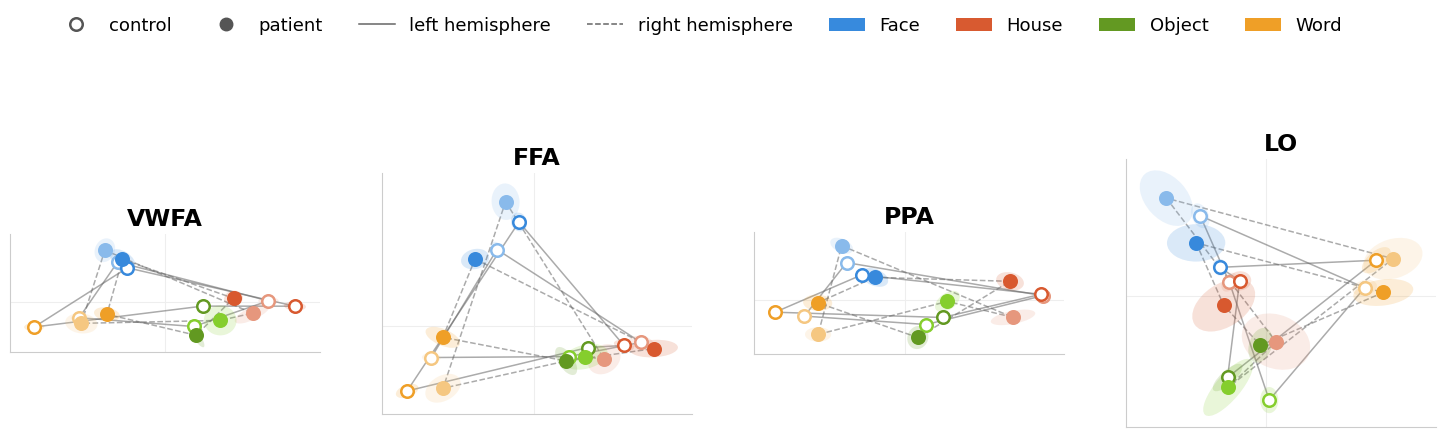

In [ ]:
# ─── MDS: four group configurations in one space, per ROI ────────────────
# Weber et al. (2026) Fig. 4f as the model: mean RDMs projected to 2D by
# classical MDS, individual solutions Procrustes-aligned to a common frame,
# SE ellipses around group means.
#
# Here all four groups share one space per ROI, so the question the figure
# answers is relational: does each patient group's configuration sit closer to
# its own controls or to the other hemisphere's controls?
#
# Dissimilarity = 1 - r, with r recovered from the Fisher-z values by tanh.
# Alignment is rotation/reflection only (no rescaling), so distances stay
# comparable across groups.
from matplotlib.patches import Ellipse

MDS_GROUPS = [('ctrl L',  'l', 'ctrl'), ('ctrl R',  'r', 'ctrl'),
              ('pt L',    'l', 'pt'),   ('pt R',    'r', 'pt')]
MDS_STYLE  = {'ctrl L': dict(mfc='white', ls='-'),  'ctrl R': dict(mfc='white', ls='-'),
              'pt L':   dict(mfc=None,    ls='--'), 'pt R':   dict(mfc=None,    ls='--')}
GRP_SHADE  = {'ctrl L': 1.35, 'ctrl R': 1.0, 'pt L': 1.35, 'pt R': 1.0}

PAIR_IDX = {}
for i, a in enumerate(CATEGORIES):
    for j, b in enumerate(CATEGORIES):
        if i < j:
            PAIR_IDX[f'{a}-{b}'] = (i, j)
            PAIR_IDX[f'{b}-{a}'] = (i, j)


def _subject_dissim(df, sub, ses, roi, hemi):
    """4x4 dissimilarity (1 - r) for one subject-session-ROI-hemisphere."""
    d = df[(df['subject_id'] == sub) & (df['ses_num'] == ses) &
           (df['category'] == roi) & (df['hemi'] == hemi)]
    D = np.full((len(CATEGORIES), len(CATEGORIES)), np.nan)
    np.fill_diagonal(D, 0.0)
    for r in d.itertuples():
        if r.pair not in PAIR_IDX or not np.isfinite(r.fisher_r):
            continue
        i, j = PAIR_IDX[r.pair]
        val = 1.0 - np.tanh(r.fisher_r)
        D[i, j] = D[j, i] = val
    return None if np.isnan(D).any() else D


def _classical_mds(D):
    """Torgerson MDS to two dimensions."""
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    w, V = np.linalg.eigh(B)
    k = np.argsort(w)[::-1][:2]
    return V[:, k] * np.sqrt(np.maximum(w[k], 0))


def _procrustes_align(X, ref):
    """Rotate/reflect X onto ref about their centroids; scale preserved."""
    Xc, Rc = X - X.mean(0), ref - ref.mean(0)
    U, _, Vt = np.linalg.svd(Xc.T @ Rc)
    return Xc @ (U @ Vt)


def _group_configs(roi):
    """Per-group mean configuration and per-category SE, in a shared frame."""
    # reference frame = control grand mean across both hemispheres
    ref_mats = []
    for hemi in ('l', 'r'):
        for s, ses in ctrl_keys:
            D = _subject_dissim(rsa_c_long, s, ses, roi, hemi)
            if D is not None:
                ref_mats.append(D)
    if not ref_mats:
        return {}
    ref = _classical_mds(np.mean(ref_mats, axis=0))

    out = {}
    for label, hemi, kind in MDS_GROUPS:
        coords = []
        if kind == 'ctrl':
            keys, src = ctrl_keys, rsa_c_long
            sel = lambda s, ses: _subject_dissim(src, s, ses, roi, hemi)
        else:
            intact = 'left' if hemi == 'l' else 'right'
            keys = [(s, ses) for s, ses, ih in pt_keys if ih == intact]
            sel = lambda s, ses: _subject_dissim(rsa_p_long, s, ses, roi, hemi)
        for s, ses in keys:
            D = sel(s, ses)
            if D is None:
                continue
            coords.append(_procrustes_align(_classical_mds(D), ref))
        if len(coords) < 3:
            continue
        A = np.stack(coords)                       # subjects x category x 2
        out[label] = dict(mean=A.mean(0),
                          cov=[np.cov(A[:, c, :].T) / A.shape[0]
                               for c in range(len(CATEGORIES))],
                          n=A.shape[0])
    return out


# subject-session keys, taken from the same frames the other panels use
ctrl_keys = sorted(set(zip(rsa_c_long['subject_id'], rsa_c_long['ses_num'])))
pt_keys = sorted(set(zip(rsa_p_long['subject_id'], rsa_p_long['ses_num'],
                         rsa_p_long['intact_hemi'])))
print(f'MDS: {len(ctrl_keys)} control sessions, {len(pt_keys)} patient sessions')

ROIS_MDS = [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]
fig, axes = plt.subplots(1, len(ROIS_MDS), figsize=(4.6 * len(ROIS_MDS), 5.0))
axes = np.atleast_1d(axes)
fig.patch.set_facecolor('white')

for ax, roi in zip(axes, ROIS_MDS):
    cfg = _group_configs(roi)
    ax.set_facecolor('white')
    ax.axhline(0, color='#eee', lw=0.8, zorder=0)
    ax.axvline(0, color='#eee', lw=0.8, zorder=0)
    for label, hemi, kind in MDS_GROUPS:
        if label not in cfg:
            continue
        M, C = cfg[label]['mean'], cfg[label]['cov']
        st = MDS_STYLE[label]
        # closed polygon through the four categories, in CATEGORIES order
        loop = np.vstack([M, M[:1]])
        ax.plot(loop[:, 0], loop[:, 1], color='#666', lw=1.1,
                ls=st['ls'], alpha=0.55, zorder=1)
        for c, cat in enumerate(CATEGORIES):
            col = shade(CAT_COLORS[cat], GRP_SHADE[label])
            w, V = np.linalg.eigh(C[c])
            k = np.argsort(w)[::-1]
            ang = np.degrees(np.arctan2(V[1, k[0]], V[0, k[0]]))
            ax.add_patch(Ellipse(M[c], 2 * np.sqrt(max(w[k[0]], 0)),
                                 2 * np.sqrt(max(w[k[1]], 0)), angle=ang,
                                 facecolor=col, alpha=0.18, edgecolor='none',
                                 zorder=2))
            ax.plot(*M[c], 'o', ms=9, color=col,
                    mfc=st['mfc'] if st['mfc'] else col,
                    mec=col, mew=1.8, ls=st['ls'], zorder=3)
    ax.set_title(ROI_TITLE.get(roi, roi), fontsize=17, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_color('#ccc')

handles = ([Line2D([], [], marker='o', ls='', ms=9, mfc='white', mec='#555',
                   mew=1.8, label='control')] +
           [Line2D([], [], marker='o', ls='', ms=9, color='#555', label='patient')] +
           [Line2D([], [], color='#666', lw=1.1, ls='-',  label='left hemisphere'),
            Line2D([], [], color='#666', lw=1.1, ls='--', label='right hemisphere')] +
           [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES])
fig.legend(handles=handles, loc='upper center', frameon=False,
           ncol=len(handles), bbox_to_anchor=(0.5, 1.08), fontsize=13)

fig.savefig(FIG_DIR / 'mds_four_group.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

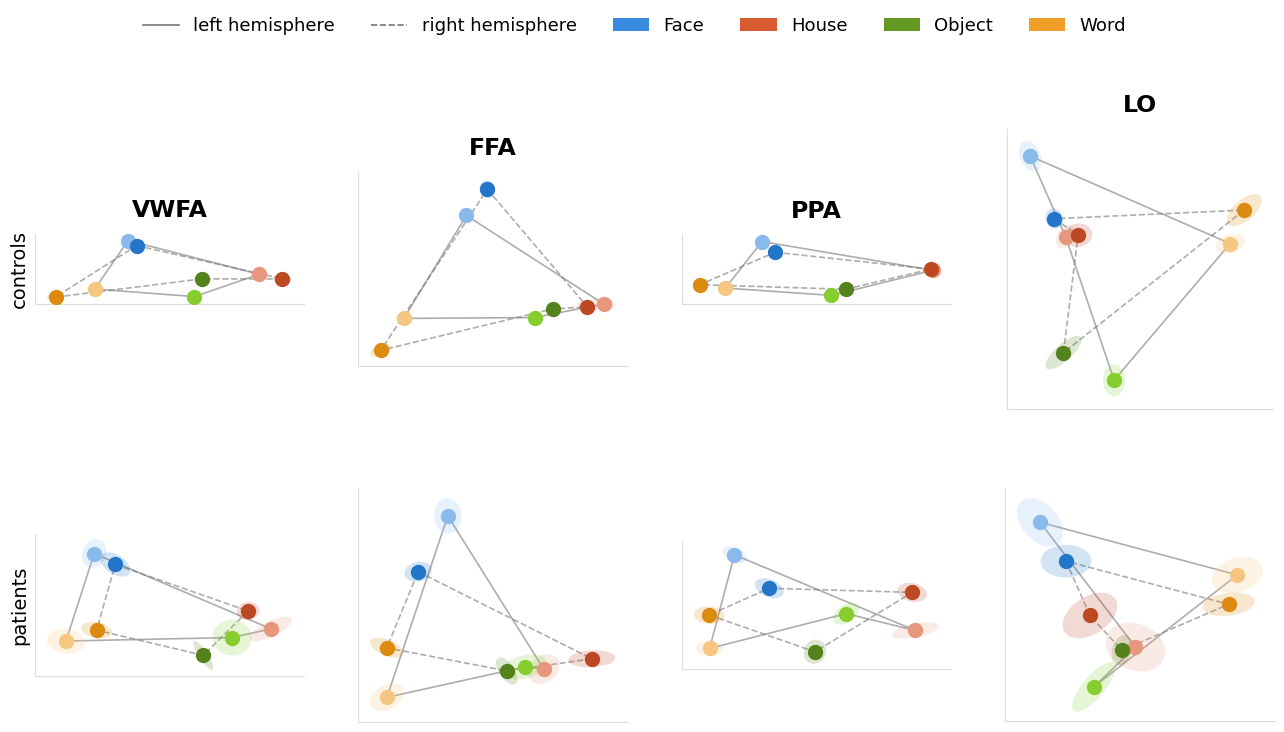

In [ ]:
# =========================================================================
# CELL 3 · MDS, two rows: controls against each other, patients against
# each other. Requires the helpers from the four-group MDS cell
# (_subject_dissim, _classical_mds, _procrustes_align, ctrl_keys, pt_keys).
# =========================================================================
from matplotlib.patches import Ellipse

MDS_ROWS = [('controls', [('ctrl L', 'l', 'ctrl'), ('ctrl R', 'r', 'ctrl')]),
            ('patients', [('pt L',   'l', 'pt'),   ('pt R',   'r', 'pt')])]
ROW_STYLE = {'ctrl L': '-', 'pt L': '-', 'ctrl R': '--', 'pt R': '--'}
ROW_SHADE = {'ctrl L': 1.35, 'pt L': 1.35, 'ctrl R': 0.85, 'pt R': 0.85}

fig, axes = plt.subplots(2, len(ROIS_RSM),
                         figsize=(4.0 * len(ROIS_RSM), 8.0))
fig.patch.set_facecolor('white')
for r, (rlab, groups) in enumerate(MDS_ROWS):
    for c, roi in enumerate(ROIS_RSM):
        ax = axes[r, c]
        cfg = _group_configs(roi)
        ax.set_facecolor('white')
        for label, hemi, kind in groups:
            if label not in cfg:
                continue
            M, C = cfg[label]['mean'], cfg[label]['cov']
            loop = np.vstack([M, M[:1]])
            ax.plot(loop[:, 0], loop[:, 1], color='#777', lw=1.2,
                    ls=ROW_STYLE[label], alpha=0.6, zorder=1)
            for k, cat in enumerate(CATEGORIES):
                col = shade(CAT_COLORS[cat], ROW_SHADE[label])
                w, V = np.linalg.eigh(C[k])
                o = np.argsort(w)[::-1]
                ang = np.degrees(np.arctan2(V[1, o[0]], V[0, o[0]]))
                ax.add_patch(Ellipse(M[k], 2 * np.sqrt(max(w[o[0]], 0)),
                                     2 * np.sqrt(max(w[o[1]], 0)), angle=ang,
                                     facecolor=col, alpha=0.20,
                                     edgecolor='none', zorder=2))
                ax.plot(*M[k], 'o', ms=10, color=col, zorder=3)
        if r == 0:
            ax.set_title(ROI_TITLE.get(roi, roi), fontsize=17,
                         fontweight='bold', pad=12)
        if c == 0:
            ax.set_ylabel(rlab, fontsize=14)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_color('#ddd')

handles = ([Line2D([], [], color='#777', lw=1.2, ls='-',  label='left hemisphere'),
            Line2D([], [], color='#777', lw=1.2, ls='--', label='right hemisphere')] +
           [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES])
fig.legend(handles=handles, loc='upper center', frameon=False,
           ncol=len(handles), bbox_to_anchor=(0.5, 1.04), fontsize=13)
fig.savefig(FIG_DIR / 'mds_two_row.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

In [ ]:
# ─── MDS: how much do two dimensions actually retain? ────────────────────
# Weber et al. could compress ten interdigit distances into one MDS panel
# because digit structure is essentially one-dimensional. Four visual
# categories have no such ordering, so the question is empirical: what
# fraction of the structure survives the 2D projection?
#
# Printed per ROI on the control grand-mean matrix, which is the frame every
# subject is aligned to. A high value means a flat-looking MDS reflects small
# effects; a low value means the projection is discarding them.

PAIR_IJ_MDS = {}
for i, a in enumerate(CATEGORIES):
    for j, b in enumerate(CATEGORIES):
        if i < j:
            PAIR_IJ_MDS[f'{a}-{b}'] = PAIR_IJ_MDS[f'{b}-{a}'] = (i, j)
NCM = len(CATEGORIES)


def _mean_dissim(df, roi, hemi, intact=None):
    """Group-mean 4x4 dissimilarity (1 - r) from the Fisher-z values."""
    d = df[(df['category'] == roi) & (df['hemi'] == hemi)]
    if intact is not None:
        d = d[d['intact_hemi'] == intact]
    D = np.full((NCM, NCM), np.nan)
    np.fill_diagonal(D, 0.0)
    for pair, g in d.groupby('pair'):
        if pair in PAIR_IJ_MDS:
            i, j = PAIR_IJ_MDS[pair]
            D[i, j] = D[j, i] = 1.0 - np.tanh(g['fisher_r'].mean())
    return D


def _mds_eigs(D):
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    w = np.sort(np.linalg.eigvalsh(B))[::-1]
    pos = np.clip(w, 0, None)
    return w, pos[:2].sum() / pos.sum() if pos.sum() > 0 else np.nan


print('2D variance explained by classical MDS, per ROI')
print(f"{'ROI':8}{'ctrl L':>10}{'ctrl R':>10}{'LH pt':>10}{'RH pt':>10}")
for roi in [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]:
    vals = []
    for df, hemi, intact in [(rsa_c_long, 'l', None), (rsa_c_long, 'r', None),
                             (rsa_p_long, 'l', 'left'), (rsa_p_long, 'r', 'right')]:
        D = _mean_dissim(df, roi, hemi, intact)
        vals.append(np.nan if np.isnan(D).any() else _mds_eigs(D)[1])
    print(f"{ROI_TITLE.get(roi, roi):8}" + ''.join(f'{v:>9.1%}' if np.isfinite(v)
                                                   else f'{"n/a":>10}' for v in vals))

print('\nEigenvalues of the control grand-mean matrix (all four dimensions):')
for roi in [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]:
    D = np.nanmean(np.stack([_mean_dissim(rsa_c_long, roi, 'l'),
                             _mean_dissim(rsa_c_long, roi, 'r')]), axis=0)
    w, frac = _mds_eigs(D)
    print(f"  {ROI_TITLE.get(roi, roi):8}" +
          '  '.join(f'{v:+.3f}' for v in w) + f'   -> 2D = {frac:.1%}')

2D variance explained by classical MDS, per ROI
ROI         ctrl L    ctrl R     LH pt     RH pt
VWFA       100.0%   100.0%    97.0%    98.1%
FFA        100.0%    98.9%    93.0%   100.0%
PPA        100.0%   100.0%    96.0%    97.7%
LO          88.4%    81.3%    79.1%    97.6%

Eigenvalues of the control grand-mean matrix (all four dimensions):
  VWFA    +0.433  +0.036  -0.000  -0.054   -> 2D = 100.0%
  FFA     +0.206  +0.100  -0.000  -0.001   -> 2D = 100.0%
  PPA     +0.951  +0.026  -0.000  -0.057   -> 2D = 100.0%
  LO      +0.025  +0.018  +0.008  -0.000   -> 2D = 84.2%


In [ ]:
for roi in [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]:
    D = np.nanmean(np.stack([_mean_dissim(rsa_c_long, roi, 'l'),
                             _mean_dissim(rsa_c_long, roi, 'r')]), axis=0)
    X = _classical_mds(D)
    order = np.argsort(X[:, 0])
    print(ROI_TITLE.get(roi, roi),
          [f'{CATEGORIES[i]} {X[i,0]:+.2f}' for i in order])

VWFA ['word -0.43', 'face -0.14', 'object +0.11', 'house +0.46']
FFA ['word -0.33', 'face -0.06', 'object +0.11', 'house +0.28']
PPA ['word -0.60', 'face -0.26', 'object +0.16', 'house +0.71']
LO ['word -0.12', 'object -0.01', 'house +0.04', 'face +0.09']


In [ ]:
# ─── Is MDS dimension 1 just preferred-category similarity? ──────────────
# A category's coordinate on dimension 1 should track its mean dissimilarity
# from the other three, which is preferred-category similarity with the sign
# flipped. If the correlation is near -1, the axis carries no information
# beyond that measure and the MDS panel is a restatement.
#
# Needs _mean_dissim, _mds_eigs and _classical_mds from the earlier cells.
from scipy.stats import pearsonr, spearmanr

print(f"{'ROI':8}{'r(dim1, mean dissim)':>24}{'rank match':>13}")
for roi in [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]:
    D = np.nanmean(np.stack([_mean_dissim(rsa_c_long, roi, 'l'),
                             _mean_dissim(rsa_c_long, roi, 'r')]), axis=0)
    X = _classical_mds(D)
    dim1 = X[:, 0]
    # mean dissimilarity of each category from the other three
    md = np.array([np.nanmean(np.delete(D[i], i)) for i in range(len(CATEGORIES))])
    r = pearsonr(dim1, md)[0]
    rho = spearmanr(dim1, md)[0]
    print(f'{ROI_TITLE.get(roi, roi):8}{r:>24.3f}{rho:>13.2f}')

print('\nper-category detail (control grand mean)')
for roi in [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]:
    D = np.nanmean(np.stack([_mean_dissim(rsa_c_long, roi, 'l'),
                             _mean_dissim(rsa_c_long, roi, 'r')]), axis=0)
    X = _classical_mds(D)
    md = np.array([np.nanmean(np.delete(D[i], i)) for i in range(len(CATEGORIES))])
    print(f'  {ROI_TITLE.get(roi, roi)}')
    for i, cat in enumerate(CATEGORIES):
        print(f'    {cat:8} dim1 = {X[i,0]:+.3f}   mean dissim = {md[i]:.3f}')

ROI         r(dim1, mean dissim)   rank match
VWFA                      -0.002         0.20
FFA                       -0.747        -0.80
PPA                        0.375         0.20
LO                        -0.674        -0.40

per-category detail (control grand mean)
  VWFA
    face     dim1 = -0.143   mean dissim = 0.418
    house    dim1 = +0.461   mean dissim = 0.573
    object   dim1 = +0.115   mean dissim = 0.351
    word     dim1 = -0.433   mean dissim = 0.566
  FFA
    face     dim1 = -0.060   mean dissim = 0.451
    house    dim1 = +0.280   mean dissim = 0.418
    object   dim1 = +0.113   mean dissim = 0.337
    word     dim1 = -0.333   mean dissim = 0.515
  PPA
    face     dim1 = -0.260   mean dissim = 0.584
    house    dim1 = +0.706   mean dissim = 0.918
    object   dim1 = +0.155   mean dissim = 0.549
    word     dim1 = -0.601   mean dissim = 0.784
  LO
    face     dim1 = +0.092   mean dissim = 0.185
    house    dim1 = +0.042   mean dissim = 0.163
    object   dim1 

# ROSENKE

In [ ]:
# ─── Whole-OTC odRSM: do patients' two preserved hemispheres resemble each
# ─── other more than controls' two hemispheres resemble each other? ─────────
# Source: otc_rsm_persubject.csv, from `python otc_rsm_rosenke.py --csv otc_rsm.csv`
# Whole OTC parcel, cat-vs-all-others copes 6-9, no ROI, no peak-finding.
#
# Patient side : LH-intact x RH-intact          -> 12 x 12 = 144 pairs
# Control side : control-left x control-right,  -> 36 x 35 = 1260 pairs
#                same-subject pairs dropped, because the patient side has none.
# Inference    : side is held fixed (left rows stay left), patient/control
#                label shuffled within each side, 12 vs 36 preserved. Two-tailed.

RSM_CSV_CH = REPO / 'H_RosenkeRSM/otc_rsm_persubject.csv'
NPERM_CH   = 10000
rng_ch     = np.random.default_rng(42)

ch = pd.read_csv(RSM_CSV_CH)
PAIRS_CH = [c for c in ch.columns if '-' in c]
assert len(PAIRS_CH) == 6, PAIRS_CH

L, R = ch[ch.hemi == 'l'], ch[ch.hemi == 'r']
sets_ch = {
    'ctl_L': L[L.group == 'control'],
    'ctl_R': R[R.group == 'control'],
    'pt_L' : L[(L.group == 'OTC') & (L.intact_hemi == 'left')],
    'pt_R' : R[(R.group == 'OTC') & (R.intact_hemi == 'right')],
}
n_ch = {k: len(v) for k, v in sets_ch.items()}
print(f'{len(ch)} subject x hemisphere rows | pairs: {PAIRS_CH}')
print('  ' + '   '.join(f'{k} {v}' for k, v in n_ch.items()))
if not (n_ch['ctl_L'] == n_ch['ctl_R'] == 36 and n_ch['pt_L'] == n_ch['pt_R'] == 12):
    print('  ** not the cohort of record (36/12/12) — rerun otc_rsm_rosenke.py **')


def _z_ch(M):
    """Z-score each row over its six values, so row-pair correlation is a dot
    product divided by 6."""
    M = np.asarray(M, float)
    return (M - M.mean(1, keepdims=True)) / M.std(1, ddof=0, keepdims=True)


# side matrices: controls first, then patients
ZL = _z_ch(pd.concat([sets_ch['ctl_L'], sets_ch['pt_L']])[PAIRS_CH].to_numpy())
ZR = _z_ch(pd.concat([sets_ch['ctl_R'], sets_ch['pt_R']])[PAIRS_CH].to_numpy())
idL = pd.concat([sets_ch['ctl_L'], sets_ch['pt_L']])['subject_id'].to_numpy()
idR = pd.concat([sets_ch['ctl_R'], sets_ch['pt_R']])['subject_id'].to_numpy()

XR_CH = ZL @ ZR.T / len(PAIRS_CH)          # every left row vs every right row
SAME  = idL[:, None] == idR[None, :]       # same-subject pairs to drop
nCL, nPL = n_ch['ctl_L'], n_ch['pt_L']
nCR, nPR = n_ch['ctl_R'], n_ch['pt_R']


def _cross_ch(li, ri):
    blk = XR_CH[np.ix_(li, ri)]
    keep = ~SAME[np.ix_(li, ri)]
    return blk[keep].mean(), int(keep.sum())


ctl_i_L, pt_i_L = np.arange(nCL), np.arange(nCL, nCL + nPL)
ctl_i_R, pt_i_R = np.arange(nCR), np.arange(nCR, nCR + nPR)
pt_cross,  n_pt  = _cross_ch(pt_i_L,  pt_i_R)
ctl_cross, n_ctl = _cross_ch(ctl_i_L, ctl_i_R)
obs_ch = pt_cross - ctl_cross

null_ch = np.empty(NPERM_CH)
for b in range(NPERM_CH):
    iL, iR = rng_ch.permutation(len(ZL)), rng_ch.permutation(len(ZR))
    a, _ = _cross_ch(iL[:nPL], iR[:nPR])
    c, _ = _cross_ch(iL[nPL:], iR[nPR:])
    null_ch[b] = a - c
p_ch = (np.sum(np.abs(null_ch) >= abs(obs_ch) - 1e-12) + 1) / (NPERM_CH + 1)

print('\nCROSS-SET AGREEMENT IN WHOLE-OTC odRSM')
print(f'  patients  LH-intact x RH-intact   mean r = {pt_cross:+.3f}  ({n_pt} pairs)')
print(f'  controls  left x right            mean r = {ctl_cross:+.3f}  ({n_ctl} pairs)')
print(f'  difference (patients - controls)  {obs_ch:+.3f}   p = {p_ch:.4f}'
      + ('  *' if p_ch < .05 else ''))
print('  positive and significant = patients two preserved hemispheres resemble')
print('  each other more than controls two hemispheres do; null or negative = not')


def _within_ch(Z):
    C = Z @ Z.T / len(PAIRS_CH)
    np.fill_diagonal(C, np.nan)
    return np.nanmean(C)


print('\n  for context, agreement WITHIN each set')
for lab, Z in [('controls left', ZL[ctl_i_L]), ('controls right', ZR[ctl_i_R]),
               ('LH-intact', ZL[pt_i_L]),      ('RH-intact', ZR[pt_i_R])]:
    print(f'    {lab:15s} {_within_ch(Z):+.3f}')

96 subject x hemisphere rows | pairs: ['face-house', 'face-object', 'face-word', 'house-object', 'house-word', 'object-word']
  ctl_L 36   ctl_R 36   pt_L 12   pt_R 12

CROSS-SET AGREEMENT IN WHOLE-OTC odRSM
  patients  LH-intact x RH-intact   mean r = +0.508  (144 pairs)
  controls  left x right            mean r = +0.556  (1260 pairs)
  difference (patients - controls)  -0.048   p = 0.5521
  positive and significant = patients two preserved hemispheres resemble
  each other more than controls two hemispheres do; null or negative = not

  for context, agreement WITHIN each set
    controls left   +0.703
    controls right  +0.606
    LH-intact       +0.419
    RH-intact       +0.533


In [ ]:
# ─── Whole-OTC odRSM: specialised (controls) vs generalist (patients) ────────
# Source: H_RosenkeRSM/otc_rsm_persubject.csv, from
#     python otc_rsm_rosenke.py --csv otc_rsm.csv
# Whole OTC parcel, cat-vs-all-others copes 6-9, no ROI, no peak-finding. Each
# subject x hemisphere contributes six between-category pattern similarities.
#
# Agreement between any two sets = mean correlation of their six-value vectors
# over all cross pairs, same-subject pairs dropped (the patient sets share no
# subjects, so control left-vs-right must not either).
#
# GAP CONTRAST. For each group: within-side agreement (mean of left-within and
# right-within) minus across-side agreement. A specialised pair of hemispheres
# agrees more within a side than across it, so the gap is positive. A generalist
# pair does not. Statistic = gap(controls) - gap(patients); the side structure is
# held fixed and the patient/control label shuffled within each side, 12 vs 36
# preserved. Two-tailed.

RSM_CSV_CH = REPO / 'H_RosenkeRSM' / 'otc_rsm_persubject.csv'
NPERM_CH   = 10000
rng_ch     = np.random.default_rng(42)

ch = pd.read_csv(RSM_CSV_CH)
PAIRS_CH = [c for c in ch.columns if '-' in c]
assert len(PAIRS_CH) == 6, PAIRS_CH

ch['set'] = np.where(ch.group == 'control',
                     'ctl_' + ch.hemi.str.upper(),
                     np.where(ch.intact_hemi == ch.hemi.map({'l': 'left', 'r': 'right'}),
                              'pt_' + ch.hemi.str.upper(), 'drop'))
ch = ch[ch['set'] != 'drop'].reset_index(drop=True)
SETS_CH = ['ctl_L', 'pt_L', 'ctl_R', 'pt_R']
n_ch = {s: int((ch['set'] == s).sum()) for s in SETS_CH}
print('  ' + '   '.join(f'{k} {v}' for k, v in n_ch.items()))
if not (n_ch['ctl_L'] == n_ch['ctl_R'] == 36 and n_ch['pt_L'] == n_ch['pt_R'] == 12):
    print('  ** not the cohort of record (36/12/12) — rerun otc_rsm_rosenke.py **')

M = ch[PAIRS_CH].to_numpy(float)
Z = (M - M.mean(1, keepdims=True)) / M.std(1, ddof=0, keepdims=True)
CORR_CH = Z @ Z.T / len(PAIRS_CH)
sid_ch  = ch['subject_id'].to_numpy()
SAME_CH = sid_ch[:, None] == sid_ch[None, :]
IDX_CH  = {s: np.where(ch['set'].to_numpy() == s)[0] for s in SETS_CH}
SIDE_CH = {'L': np.where(ch.hemi.to_numpy() == 'l')[0],
           'R': np.where(ch.hemi.to_numpy() == 'r')[0]}


def _agree(i, j=None):
    """Mean r between two index sets, or within one set if j is None."""
    j = i if j is None else j
    blk, keep = CORR_CH[np.ix_(i, j)], ~SAME_CH[np.ix_(i, j)]
    return blk[keep].mean(), int(keep.sum())


# ---- 1. every set against every set ---------------------------------------
print('\nAGREEMENT BETWEEN SETS  (mean r over cross pairs; diagonal = within set)')
print('              ' + ''.join(f'{s:>10s}' for s in SETS_CH))
for a in SETS_CH:
    row = ''.join(f'{_agree(IDX_CH[a], IDX_CH[b])[0]:+10.3f}' for b in SETS_CH)
    print(f'  {a:11s}' + row)

print('\n  key comparisons')
for lab, a, b in [('ctl_L  vs ctl_R  (control hemispheres)', 'ctl_L', 'ctl_R'),
                  ('pt_L   vs pt_R   (patient hemispheres)', 'pt_L',  'pt_R'),
                  ('ctl_L  vs pt_L   (left, matched)',       'ctl_L', 'pt_L'),
                  ('ctl_R  vs pt_R   (right, matched)',      'ctl_R', 'pt_R'),
                  ('ctl_R  vs pt_L   (crossed)',             'ctl_R', 'pt_L'),
                  ('ctl_L  vs pt_R   (crossed)',             'ctl_L', 'pt_R')]:
    r, n = _agree(IDX_CH[a], IDX_CH[b])
    print(f'    {lab:40s} {r:+.3f}  ({n} pairs)')


# ---- 2. gap contrast -------------------------------------------------------
def _gap(iL, iR):
    within = (_agree(iL)[0] + _agree(iR)[0]) / 2
    return within - _agree(iL, iR)[0], within, _agree(iL, iR)[0]


gap_c, wc, ac = _gap(IDX_CH['ctl_L'], IDX_CH['ctl_R'])
gap_p, wp, ap = _gap(IDX_CH['pt_L'],  IDX_CH['pt_R'])
obs_ch = gap_c - gap_p

nPL, nPR = n_ch['pt_L'], n_ch['pt_R']
null_ch = np.empty(NPERM_CH)
for b in range(NPERM_CH):
    pL = rng_ch.permutation(SIDE_CH['L']); pR = rng_ch.permutation(SIDE_CH['R'])
    null_ch[b] = (_gap(pL[nPL:], pR[nPR:])[0] - _gap(pL[:nPL], pR[:nPR])[0])
p_ch = (np.sum(np.abs(null_ch) >= abs(obs_ch) - 1e-12) + 1) / (NPERM_CH + 1)

print('\nGAP CONTRAST  (within-side agreement minus across-side agreement)')
print(f'  controls  within {wc:+.3f}   across {ac:+.3f}   gap {gap_c:+.3f}')
print(f'  patients  within {wp:+.3f}   across {ap:+.3f}   gap {gap_p:+.3f}')
print(f'  controls - patients  {obs_ch:+.3f}   p = {p_ch:.4f}'
      + ('  *' if p_ch < .05 else ''))
print('  positive and significant = controls hemispheres are differentiated from')
print('  each other in a way patients preserved hemispheres are not')

  ctl_L 36   pt_L 12   ctl_R 36   pt_R 12

AGREEMENT BETWEEN SETS  (mean r over cross pairs; diagonal = within set)
                   ctl_L      pt_L     ctl_R      pt_R
  ctl_L          +0.703    +0.521    +0.556    +0.572
  pt_L           +0.521    +0.419    +0.519    +0.508
  ctl_R          +0.556    +0.519    +0.606    +0.564
  pt_R           +0.572    +0.508    +0.564    +0.533

  key comparisons
    ctl_L  vs ctl_R  (control hemispheres)   +0.556  (1260 pairs)
    pt_L   vs pt_R   (patient hemispheres)   +0.508  (144 pairs)
    ctl_L  vs pt_L   (left, matched)         +0.521  (432 pairs)
    ctl_R  vs pt_R   (right, matched)        +0.564  (432 pairs)
    ctl_R  vs pt_L   (crossed)               +0.519  (432 pairs)
    ctl_L  vs pt_R   (crossed)               +0.572  (432 pairs)

GAP CONTRAST  (within-side agreement minus across-side agreement)
  controls  within +0.654   across +0.556   gap +0.098
  patients  within +0.476   across +0.508   gap -0.032
  controls - patients  +0.

In [ ]:
# ─── Whole-OTC odRSM: is the agreement above chance, and is it side-specific? ─
# Source: H_RosenkeRSM/otc_rsm_persubject.csv
#
# Three parts.
#  1  CHANCE BASELINE. Every subject shares a common six-value profile (e.g.
#     house-word near -0.69 in everyone), so correlating profiles largely
#     recovers that shared shape and nothing falls near zero. The null shuffles
#     the six pair labels within each subject, which destroys the shared shape
#     while keeping each subject's own six numbers.
#  2  SIDE TYPICALITY, raw profiles. Per subject: mean agreement with
#     same-side controls minus mean agreement with opposite-side controls.
#     Positive = the subject's geometry is side-typical. Controls should be
#     positive; the question is whether patients are near zero.
#  3  SIDE TYPICALITY, grand-mean removed. The grand mean profile over all
#     subjects is subtracted first, so agreement reflects shared DEVIATION from
#     the common shape rather than the shape itself.
# Same-subject pairs are always dropped, so a control's left profile is never
# correlated with its own right profile.

RSM_CSV_CH = REPO / 'H_RosenkeRSM' / 'otc_rsm_persubject.csv'
NPERM_CH   = 10000
rng_ch     = np.random.default_rng(42)

ch = pd.read_csv(RSM_CSV_CH)
PAIRS_CH = [c for c in ch.columns if '-' in c]
assert len(PAIRS_CH) == 6, PAIRS_CH
ch['set'] = np.where(
    ch.group == 'control', 'ctl_' + ch.hemi.str.upper(),
    np.where(ch.intact_hemi == ch.hemi.map({'l': 'left', 'r': 'right'}),
             'pt_' + ch.hemi.str.upper(), 'drop'))
ch = ch[ch['set'] != 'drop'].reset_index(drop=True)
SETS_CH = ['ctl_L', 'pt_L', 'ctl_R', 'pt_R']
print('  ' + '   '.join(f'{s} {int((ch["set"] == s).sum())}' for s in SETS_CH))

M_CH    = ch[PAIRS_CH].to_numpy(float)
sid_ch  = ch['subject_id'].to_numpy()
set_ch  = ch['set'].to_numpy()
SAME_CH = sid_ch[:, None] == sid_ch[None, :]
IDX_CH  = {s: np.where(set_ch == s)[0] for s in SETS_CH}


def _zc(M):
    return (M - M.mean(1, keepdims=True)) / M.std(1, ddof=0, keepdims=True)


def _corr(M):
    Z = _zc(M)
    return Z @ Z.T / M.shape[1]


def _blk(C, i, j):
    b, keep = C[np.ix_(i, j)], ~SAME_CH[np.ix_(i, j)]
    return b[keep].mean()


def _perm1(a, b, n=NPERM_CH):
    a, b = np.asarray(a, float), np.asarray(b, float)
    obs = a.mean() - b.mean()
    pool, na, k = np.concatenate([a, b]), len(a), 0
    for _ in range(n):
        p = rng_ch.permutation(pool)
        if abs(p[:na].mean() - p[na:].mean()) >= abs(obs) - 1e-12:
            k += 1
    return obs, (k + 1) / (n + 1)


# ── 1. chance baseline ──────────────────────────────────────────────────────
C_RAW = _corr(M_CH)
off = ~SAME_CH & ~np.eye(len(M_CH), dtype=bool)
obs_all = C_RAW[off].mean()
null_all = np.empty(2000)
for b in range(2000):
    Ms = np.array([rng_ch.permutation(r) for r in M_CH])
    null_all[b] = _corr(Ms)[off].mean()
print('\n1. IS THE AGREEMENT ABOVE CHANCE')
print(f'   observed mean r over all between-subject pairs   {obs_all:+.3f}')
print(f'   null (six pair labels shuffled within subject)   {null_all.mean():+.3f} '
      f'[{np.percentile(null_all, 2.5):+.3f}, {np.percentile(null_all, 97.5):+.3f}]')
print(f'   p = {(np.sum(null_all >= obs_all) + 1) / 2001:.4f}')
print('   A null near -0.2 is expected: six values shuffled within subject are')
print('   still constrained to the same sum, so they anti-correlate slightly.')

# ── 2 & 3. side typicality ──────────────────────────────────────────────────
for tag, Mx in [('RAW PROFILES', M_CH),
                ('GRAND-MEAN REMOVED', M_CH - M_CH.mean(0, keepdims=True))]:
    C = _corr(Mx)
    typ = np.full(len(Mx), np.nan)
    for i in range(len(Mx)):
        same, opp = ('ctl_L', 'ctl_R') if set_ch[i].endswith('L') else ('ctl_R', 'ctl_L')
        typ[i] = _blk(C, [i], IDX_CH[same]) - _blk(C, [i], IDX_CH[opp])

    print(f'\n{"2" if tag == "RAW PROFILES" else "3"}. SIDE TYPICALITY — {tag}')
    print('   agreement with same-side controls minus opposite-side controls')
    print(f'   {"set":8s} {"n":>3s} {"mean":>8s} {"sd":>7s}')
    for s in SETS_CH:
        v = typ[IDX_CH[s]]
        print(f'   {s:8s} {len(v):3d} {v.mean():+8.3f} {v.std(ddof=1):7.3f}')
    for side in ('L', 'R'):
        d, p = _perm1(typ[IDX_CH['ctl_' + side]], typ[IDX_CH['pt_' + side]])
        print(f'   ctl_{side} vs pt_{side}:  diff {d:+.3f}  p = {p:.4f}'
              + ('  *' if p < .05 else ''))
    print(f'   4x4 agreement matrix under {tag.lower()}')
    print('              ' + ''.join(f'{s:>9s}' for s in SETS_CH))
    for a in SETS_CH:
        print(f'     {a:9s}' + ''.join(f'{_blk(C, IDX_CH[a], IDX_CH[b]):+9.3f}'
                                       for b in SETS_CH))
    if tag == 'RAW PROFILES':
        TYP_RAW_CH = typ.copy()
    else:
        TYP_GMR_CH = typ.copy()

  ctl_L 36   pt_L 12   ctl_R 36   pt_R 12

1. IS THE AGREEMENT ABOVE CHANCE
   observed mean r over all between-subject pairs   +0.575
   null (six pair labels shuffled within subject)   -0.000 [-0.009, +0.015]
   p = 0.0005
   A null near -0.2 is expected: six values shuffled within subject are
   still constrained to the same sum, so they anti-correlate slightly.

2. SIDE TYPICALITY — RAW PROFILES
   agreement with same-side controls minus opposite-side controls
   set        n     mean      sd
   ctl_L     36   +0.147   0.098
   pt_L      12   +0.002   0.217
   ctl_R     36   +0.050   0.160
   pt_R      12   -0.008   0.183
   ctl_L vs pt_L:  diff +0.145  p = 0.0021  *
   ctl_R vs pt_R:  diff +0.058  p = 0.2976
   4x4 agreement matrix under raw profiles
                  ctl_L     pt_L    ctl_R     pt_R
     ctl_L       +0.703   +0.521   +0.556   +0.572
     pt_L        +0.521   +0.419   +0.519   +0.508
     ctl_R       +0.556   +0.519   +0.606   +0.564
     pt_R        +0.572   +0.5

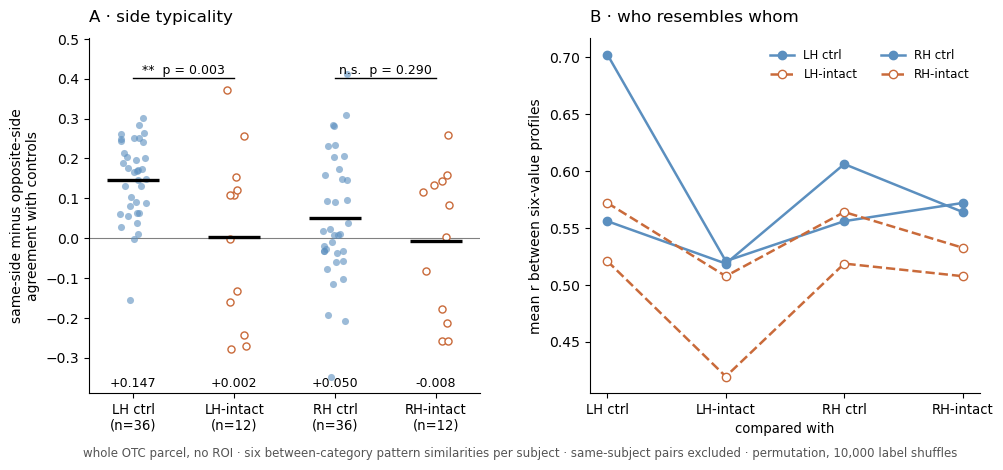

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact/otc_rsm_side_typicality.png


In [ ]:
# ─── Figure: side typicality of whole-OTC category geometry ─────────────────
# Needs TYP_RAW_CH, IDX_CH, SETS_CH, ch from the side-typicality cell above.
#
# Panel A  per-subject side typicality: agreement with same-side controls minus
#          agreement with opposite-side controls. Above zero = side-typical.
# Panel B  the 4x4 agreement matrix as a slope plot. Each set's agreement with
#          itself and with the other three, so a set whose own side is highest
#          reads as a peak on its own column.

CC_TYP, PC_TYP = '#5b8fbf', '#c96a3a'
LBL_TYP = {'ctl_L': 'LH ctrl', 'pt_L': 'LH-intact',
           'ctl_R': 'RH ctrl', 'pt_R': 'RH-intact'}
rng_typ = np.random.default_rng(0)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 4.6),
                               gridspec_kw=dict(wspace=0.28))

# ---- A: per-subject typicality --------------------------------------------
for i, s in enumerate(SETS_CH):
    v = TYP_RAW_CH[IDX_CH[s]]
    solid = s.startswith('ctl')
    col = CC_TYP if solid else PC_TYP
    axA.scatter(i + rng_typ.uniform(-.13, .13, len(v)), v, s=26,
                facecolor=col if solid else 'white', edgecolor=col,
                linewidth=0 if solid else 1.0, alpha=.6 if solid else 1, zorder=3)
    axA.hlines(v.mean(), i - .26, i + .26, color='k', lw=2.4, zorder=4)
    axA.text(i, axA.get_ylim()[0], '', ha='center')

axA.axhline(0, color='grey', lw=.8, zorder=1)
axA.set_xticks(range(4))
axA.set_xticklabels([f'{LBL_TYP[s]}\n(n={len(IDX_CH[s])})' for s in SETS_CH],
                    fontsize=9.5)
axA.set_ylabel('same-side minus opposite-side\nagreement with controls', fontsize=10)
axA.set_title('A · side typicality', loc='left', fontsize=12, pad=12)
for sp in ('top', 'right'):
    axA.spines[sp].set_visible(False)

ylo, yhi = axA.get_ylim()
pad = (yhi - ylo) * .06
for side, gi in (('L', 0), ('R', 2)):
    a = TYP_RAW_CH[IDX_CH['ctl_' + side]]; b = TYP_RAW_CH[IDX_CH['pt_' + side]]
    d, p = _perm1(a, b)
    y = yhi - pad
    axA.plot([gi, gi + 1], [y, y], color='k', lw=1)
    axA.text(gi + .5, y + pad * .25,
             ('***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.')
             + f'  p = {p:.3f}', ha='center', fontsize=9)
for i, s in enumerate(SETS_CH):
    axA.text(i, ylo + pad * .3, f'{TYP_RAW_CH[IDX_CH[s]].mean():+.3f}',
             ha='center', fontsize=9)
axA.set_ylim(ylo, yhi + pad)

# ---- B: agreement slopes ---------------------------------------------------
C_TYP = _corr(M_CH)
for s in SETS_CH:
    y = [_blk(C_TYP, IDX_CH[s], IDX_CH[t]) for t in SETS_CH]
    solid = s.startswith('ctl')
    axB.plot(range(4), y, '-o' if solid else '--o', color=CC_TYP if solid else PC_TYP,
             mfc=(CC_TYP if solid else 'white'), mec=CC_TYP if solid else PC_TYP,
             lw=1.8, ms=6, label=LBL_TYP[s])
axB.set_xticks(range(4))
axB.set_xticklabels([LBL_TYP[s] for s in SETS_CH], fontsize=9.5)
axB.set_ylabel('mean r between six-value profiles', fontsize=10)
axB.set_xlabel('compared with', fontsize=9.5)
axB.set_title('B · who resembles whom', loc='left', fontsize=12, pad=12)
axB.legend(fontsize=8.5, frameon=False, ncol=2)
for sp in ('top', 'right'):
    axB.spines[sp].set_visible(False)

fig.text(0.5, -0.03,
         'whole OTC parcel, no ROI · six between-category pattern similarities per '
         'subject · same-subject pairs excluded · permutation, 10,000 label shuffles',
         ha='center', fontsize=8.5, color='#555')
out_typ = FIG_DIR / 'otc_rsm_side_typicality.png'
plt.savefig(out_typ, dpi=300, bbox_inches='tight')
plt.show()
print('saved', out_typ)

In [ ]:
# ─── Does each patient group differentiate the other patient group from its ──
# ─── own homologous controls? ───────────────────────────────────────────────
# Needs M_CH, IDX_CH, SETS_CH, set_ch, SAME_CH, _corr, _blk from the
# side-typicality cell.
#
# Per patient, two agreements with their six-value whole-OTC geometry:
#   own-side controls      the homologous control hemisphere
#   other patient group    the patients whose opposite hemisphere is preserved
# The difference is one value per patient, tested against zero by sign-flip
# permutation. Near zero = a patient's geometry is no more like its own
# homologous controls than like the opposite patient group, i.e. the two
# preserved hemispheres are not differentiated from each other.
#
# The control analogue is the side-typicality value already computed: agreement
# with same-side minus opposite-side control hemispheres.

NPERM_D = 10000
rng_d = np.random.default_rng(7)
C_D = _corr(M_CH)


def _sign_flip(v, n=NPERM_D):
    v = np.asarray(v, float)
    obs = v.mean()
    k = 0
    for _ in range(n):
        if abs((v * rng_d.choice([-1, 1], len(v))).mean()) >= abs(obs) - 1e-12:
            k += 1
    return obs, (k + 1) / (n + 1)


print('PATIENTS — own-side controls vs the other patient group')
print(f'  {"":10s} {"n":>3s} {"own ctrl":>9s} {"other pt":>9s} {"diff":>8s} {"p":>8s}')
store_d = {}
for side, other in (('L', 'R'), ('R', 'L')):
    idx = IDX_CH['pt_' + side]
    own = np.array([_blk(C_D, [i], IDX_CH['ctl_' + side]) for i in idx])
    oth = np.array([_blk(C_D, [i], IDX_CH['pt_' + other]) for i in idx])
    d, p = _sign_flip(own - oth)
    store_d['pt_' + side] = own - oth
    print(f'  {"pt_" + side:10s} {len(idx):3d} {own.mean():+9.3f} {oth.mean():+9.3f} '
          f'{d:+8.3f} {p:8.4f}' + ('  *' if p < .05 else ''))

pooled = np.concatenate([store_d['pt_L'], store_d['pt_R']])
d, p = _sign_flip(pooled)
print(f'  {"pooled":10s} {len(pooled):3d} {"":9s} {"":9s} {d:+8.3f} {p:8.4f}'
      + ('  *' if p < .05 else ''))

print('\nCONTROLS — same-side vs opposite-side control hemispheres (side typicality)')
ctl_typ = np.concatenate([TYP_RAW_CH[IDX_CH['ctl_L']], TYP_RAW_CH[IDX_CH['ctl_R']]])
d, p = _sign_flip(ctl_typ)
print(f'  pooled     {len(ctl_typ):3d} {"":9s} {"":9s} {d:+8.3f} {p:8.4f}'
      + ('  *' if p < .05 else ''))

print('\n  A null for patients with a positive, reliable value for controls is the')
print('  claim: control hemispheres are differentiated by side, patients are not.')
print('  A null is not evidence of equivalence; report it as an absence of')
print('  differentiation at this n, not as sameness.')

PATIENTS — own-side controls vs the other patient group
               n  own ctrl  other pt     diff        p
  pt_L        12    +0.521    +0.508   +0.013   0.7510
  pt_R        12    +0.564    +0.508   +0.056   0.0083  *
  pooled      24                       +0.035   0.1399

CONTROLS — same-side vs opposite-side control hemispheres (side typicality)
  pooled      72                       +0.098   0.0001  *

  A null for patients with a positive, reliable value for controls is the
  claim: control hemispheres are differentiated by side, patients are not.
  A null is not evidence of equivalence; report it as an absence of
  differentiation at this n, not as sameness.


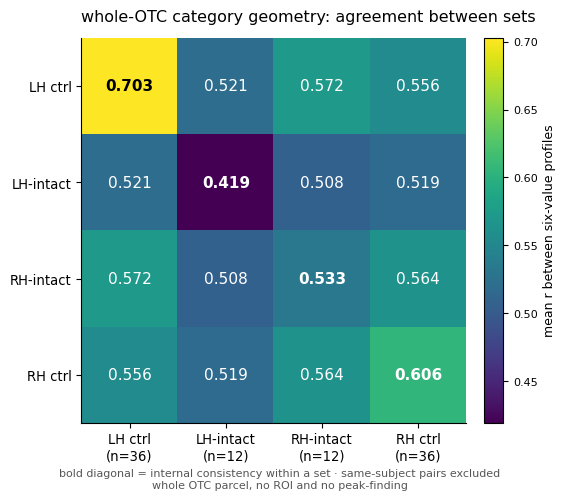

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact/otc_rsm_agreement_heatmap.png
  LH ctrl    consistency +0.703
  LH-intact  consistency +0.419
  RH-intact  consistency +0.533
  RH ctrl    consistency +0.606


In [ ]:
# ─── Figure: whole-OTC agreement heat map ───────────────────────────────────
# Needs M_CH, IDX_CH, SETS_CH, SAME_CH, _corr, _blk from the side-typicality
# cell. Source: H_RosenkeRSM/otc_rsm_persubject.csv
#
# Each subject x hemisphere contributes six between-category pattern
# similarities over the whole OTC parcel. Every cell is the mean correlation
# between the six-value profiles of two sets, same-subject pairs dropped.
#   diagonal      internal consistency: how much a set's members agree
#   off-diagonal  cross-set agreement
# A set whose highest value is its own diagonal has a geometry shared by its
# members; a set whose row is flat does not.

LBL_H = {'ctl_L': 'LH ctrl', 'pt_L': 'LH-intact',
         'ctl_R': 'RH ctrl', 'pt_R': 'RH-intact'}
ORDER_H = ['ctl_L', 'pt_L', 'pt_R', 'ctl_R']      # controls outside, patients inside
C_H = _corr(M_CH)

A_H = np.array([[_blk(C_H, IDX_CH[a], IDX_CH[b]) for b in ORDER_H]
                for a in ORDER_H])

fig, ax = plt.subplots(figsize=(5.6, 5.0))
im = ax.imshow(A_H, cmap='viridis')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{A_H[i, j]:.3f}', ha='center', va='center', fontsize=11,
                color='white' if A_H[i, j] < A_H.max() - .08 else 'black',
                fontweight='bold' if i == j else 'normal')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([f'{LBL_H[s]}\n(n={len(IDX_CH[s])})' for s in ORDER_H], fontsize=9.5)
ax.set_yticklabels([LBL_H[s] for s in ORDER_H], fontsize=9.5)
ax.set_title('whole-OTC category geometry: agreement between sets',
             loc='left', fontsize=11.5, pad=12)
cb = fig.colorbar(im, ax=ax, fraction=.046, pad=.04)
cb.set_label('mean r between six-value profiles', fontsize=9)
cb.ax.tick_params(labelsize=8)
fig.text(0.5, -0.02,
         'bold diagonal = internal consistency within a set · same-subject pairs '
         'excluded\nwhole OTC parcel, no ROI and no peak-finding',
         ha='center', fontsize=8, color='#555')
out_h = FIG_DIR / 'otc_rsm_agreement_heatmap.png'
plt.savefig(out_h, dpi=300, bbox_inches='tight')
plt.show()
print('saved', out_h)
for s in ORDER_H:
    print(f'  {LBL_H[s]:10s} consistency {_blk(C_H, IDX_CH[s], IDX_CH[s]):+.3f}')

96 subject x hemisphere rows | pairs: ['face-house', 'face-object', 'face-word', 'house-object', 'house-word', 'object-word']
[LH] ctrl +0.703 (n=36)   pt +0.419 (n=12)   diff -0.283  p=0.0001
[RH] ctrl +0.606 (n=36)   pt +0.533 (n=12)   diff -0.074  p=0.1413
[consistency] LH ctrl vs RH ctrl (paired)  diff +0.096  p=0.0001
[consistency] LH-intact vs RH-intact       diff +0.113  p=0.1061


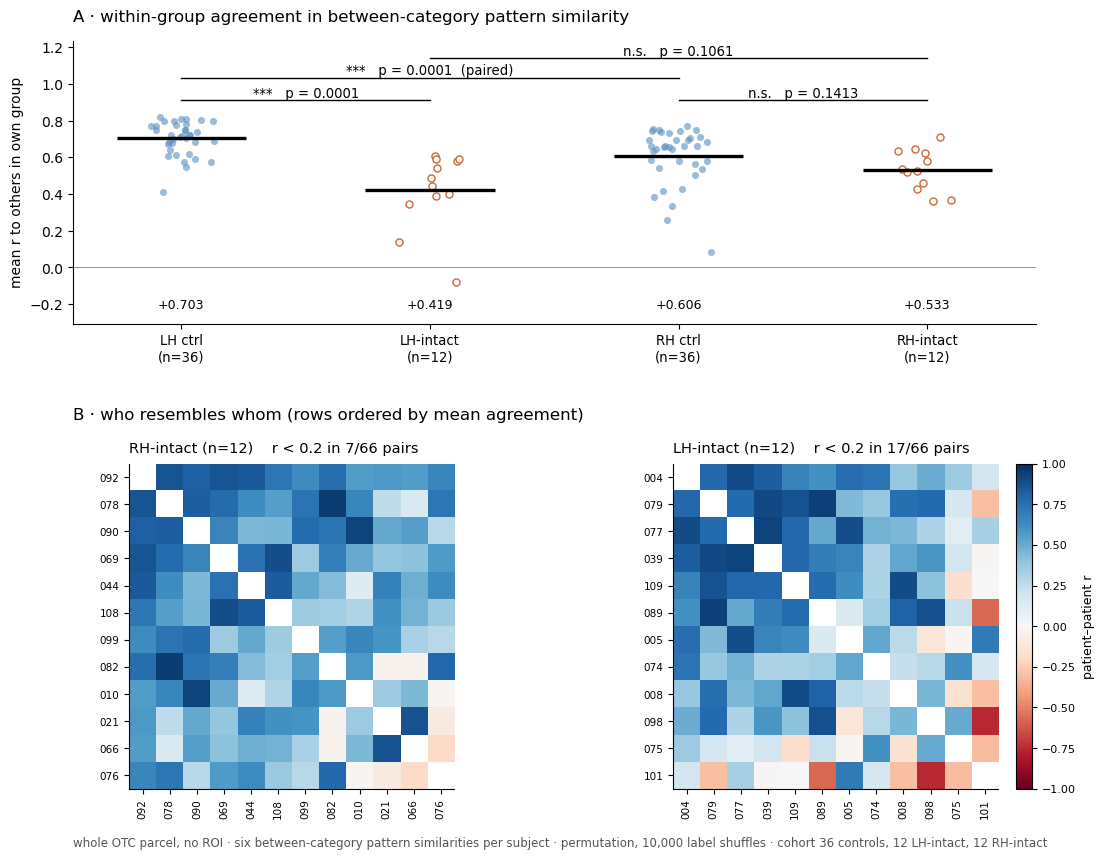

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact/otc_rsm_consistency.png


In [ ]:
# ─── Within-group representational consistency (Rosenke Fig 4 + 5 style) ─────
# Prereqs from cell 2: FIG_DIR, np, pd, plt, Path
#
# Source: otc_rsm_persubject.csv, written by
#     python otc_rsm_rosenke.py --csv otc_rsm.csv
# Whole OTC parcel, cat-vs-all-others copes 6-9, no ROI and no peak-finding, so
# this measure is independent of the searchmask and cope-13 definitions.
#
# Each subject contributes six between-category pattern similarities
# (face-house ... object-word). Consistency = the mean correlation of a
# subject's six values against every other member of their own group.
#
# Panel A  per-subject consistency, four columns
# Panel B  patient x patient matrices, rows ordered by mean agreement
#
# Local names are suffixed _RSM so nothing in the rest of the notebook is
# overwritten.

from matplotlib.gridspec import GridSpec

RSM_CSV      = REPO / 'H_RosenkeRSM' / 'otc_rsm_persubject.csv'
EXCLUDE_RSM  = set()   # cohort now set upstream by load_subjects(): 36 ctrl, 12 + 12 patients
NPERM_RSM    = 10000
INTACT_RSM   = {'l': 'left', 'r': 'right'}
CC_RSM, PC_RSM = '#5b8fbf', '#c96a3a'
rng_rsm = np.random.default_rng(42)

rsm = pd.read_csv(RSM_CSV)
rsm = rsm[~rsm['subject_id'].isin(EXCLUDE_RSM)]
PAIRS_RSM = [c for c in rsm.columns if '-' in c]
assert len(PAIRS_RSM) == 6, PAIRS_RSM
print(f'{len(rsm)} subject x hemisphere rows | pairs: {PAIRS_RSM}')


def _within_rsm(mat):
    """Each row's mean correlation to every other row."""
    n = len(mat)
    out = np.full(n, np.nan)
    for i in range(n):
        o = [j for j in range(n) if j != i]
        out[i] = np.mean([np.corrcoef(mat[i], mat[j])[0, 1] for j in o])
    return out


def _perm_rsm(a, b, n=NPERM_RSM):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    obs = b.mean() - a.mean()
    pool = np.concatenate([a, b]); na = len(a); k = 0
    for _ in range(n):
        p = rng_rsm.permutation(pool)
        if abs(p[na:].mean() - p[:na].mean()) >= abs(obs) - 1e-12:
            k += 1
    return obs, (k + 1) / (n + 1)


def _star_rsm(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'


D_RSM = {}
for hemi in ('l', 'r'):
    d = rsm[rsm['hemi'] == hemi]
    c = d[d['group'] == 'control']
    p = d[(d['group'] == 'OTC') & (d['intact_hemi'] == INTACT_RSM[hemi])]
    ctrl_v = _within_rsm(c[PAIRS_RSM].to_numpy(float))
    pt_v   = _within_rsm(p[PAIRS_RSM].to_numpy(float))
    diff, pv = _perm_rsm(ctrl_v, pt_v)
    D_RSM[hemi] = dict(ctrl=ctrl_v, pt=pt_v, diff=diff, p=pv,
                       pt_ids=p['subject_id'].str[-3:].to_numpy(),
                       pt_mat=p[PAIRS_RSM].to_numpy(float),
                       n_ctrl=len(c), n_pt=len(p))
    print(f'[{hemi.upper()}H] ctrl {ctrl_v.mean():+.3f} (n={len(c)})   '
          f'pt {pt_v.mean():+.3f} (n={len(p)})   diff {diff:+.3f}  p={pv:.4f}')

# ---- figure ---------------------------------------------------------------
fig = plt.figure(figsize=(11, 8.8))
gs = GridSpec(2, 2, height_ratios=[1.0, 1.15], hspace=0.46, wspace=0.20,
              left=0.075, right=0.95, top=0.93, bottom=0.08)

axA = fig.add_subplot(gs[0, :])
cols_rsm = [('LH ctrl', D_RSM['l']['ctrl'], CC_RSM, True),
            ('LH-intact', D_RSM['l']['pt'], PC_RSM, False),
            ('RH ctrl', D_RSM['r']['ctrl'], CC_RSM, True),
            ('RH-intact', D_RSM['r']['pt'], PC_RSM, False)]
for i, (lbl, v, col, solid) in enumerate(cols_rsm):
    axA.scatter(i + rng_rsm.uniform(-.13, .13, len(v)), v, s=26,
                facecolor=col if solid else 'white', edgecolor=col,
                linewidth=0 if solid else 1.0, alpha=.6 if solid else 1, zorder=3)
    axA.hlines(np.mean(v), i - .26, i + .26, color='k', lw=2.4, zorder=4)

lo_rsm = min(np.min(c[1]) for c in cols_rsm)
hi_rsm = max(np.max(c[1]) for c in cols_rsm)
pad = (hi_rsm - lo_rsm) * 0.30
for gi, hemi in [(0, 'l'), (2, 'r')]:
    y = hi_rsm + pad * 0.35
    axA.plot([gi, gi + 1], [y, y], color='k', lw=1)
    axA.text(gi + .5, y + pad * 0.06,
             f"{_star_rsm(D_RSM[hemi]['p'])}   p = {D_RSM[hemi]['p']:.4f}",
             ha='center', fontsize=9.5)
# hemisphere comparisons of consistency.
# Controls contribute both hemispheres, so LH ctrl vs RH ctrl is PAIRED
# (sign-flip on the within-subject difference). The two patient groups are
# different people, so LH-intact vs RH-intact is unpaired.
cl = rsm[(rsm.hemi == 'l') & (rsm.group == 'control')]
cr = rsm[(rsm.hemi == 'r') & (rsm.group == 'control')]
ord_l = np.argsort(cl['subject_id'].to_numpy())
ord_r = np.argsort(cr['subject_id'].to_numpy())
assert (cl['subject_id'].to_numpy()[ord_l] == cr['subject_id'].to_numpy()[ord_r]).all()
dv_rsm = D_RSM['l']['ctrl'][ord_l] - D_RSM['r']['ctrl'][ord_r]
obs_ctl = dv_rsm.mean()
k = sum(abs((dv_rsm * rng_rsm.choice([-1, 1], len(dv_rsm))).mean()) >= abs(obs_ctl) - 1e-12
        for _ in range(NPERM_RSM))
p_ctl = (k + 1) / (NPERM_RSM + 1)
obs_pt, p_pt = _perm_rsm(D_RSM['l']['pt'], D_RSM['r']['pt'])
print(f'[consistency] LH ctrl vs RH ctrl (paired)  diff {obs_ctl:+.3f}  p={p_ctl:.4f}')
print(f'[consistency] LH-intact vs RH-intact       diff {obs_pt:+.3f}  p={p_pt:.4f}')

for (gi, gj), (dd, pp), tag in [((0, 2), (obs_ctl, p_ctl), 'paired'),
                                ((1, 3), (obs_pt, p_pt), '')]:
    y = hi_rsm + pad * (0.80 if gi == 0 else 1.20)
    axA.plot([gi, gj], [y, y], color='k', lw=1)
    axA.text((gi + gj) / 2, y + pad * 0.06,
             f'{_star_rsm(pp)}   p = {pp:.4f}' + (f'  ({tag})' if tag else ''),
             ha='center', fontsize=9.5)

for i, (lbl, v, col, solid) in enumerate(cols_rsm):
    axA.text(i, lo_rsm - pad * 0.55, f'{np.mean(v):+.3f}', ha='center', fontsize=9)

axA.set_xticks(range(4))
axA.set_xticklabels([f'{c[0]}\n(n={len(c[1])})' for c in cols_rsm], fontsize=9.5)
axA.set_ylabel('mean r to others in own group', fontsize=10)
axA.set_ylim(lo_rsm - pad * 0.85, hi_rsm + pad * 1.55)
axA.axhline(0, color='grey', lw=.6, zorder=1)
axA.spines['top'].set_visible(False)
axA.spines['right'].set_visible(False)
axA.set_title('A · within-group agreement in between-category pattern similarity',
              loc='left', fontsize=12, pad=14)

for k, (hemi, name) in enumerate([('r', 'RH-intact'), ('l', 'LH-intact')]):
    ax = fig.add_subplot(gs[1, k])
    M = D_RSM[hemi]['pt_mat']; ids = D_RSM[hemi]['pt_ids']
    R = np.corrcoef(M); np.fill_diagonal(R, np.nan)
    order = np.argsort(-np.nanmean(R, axis=1))
    Rs = R[np.ix_(order, order)]
    im = ax.imshow(Rs, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_xticks(range(len(ids))); ax.set_yticks(range(len(ids)))
    ax.set_xticklabels(ids[order], fontsize=7.5, rotation=90)
    ax.set_yticklabels(ids[order], fontsize=7.5)
    offd = Rs[np.triu_indices(len(Rs), 1)]
    ax.set_title(f'{name} (n={len(ids)})    r < 0.2 in '
                 f'{int((offd < .2).sum())}/{len(offd)} pairs',
                 loc='left', fontsize=10.5, pad=8)
    if k == 1:
        cb = fig.colorbar(im, ax=ax, fraction=.045, pad=.04)
        cb.set_label('patient–patient r', fontsize=9)
        cb.ax.tick_params(labelsize=8)

fig.text(0.075, 0.50, 'B · who resembles whom (rows ordered by mean agreement)',
         fontsize=12, ha='left')
fig.text(0.075, 0.015,
         'whole OTC parcel, no ROI · six between-category pattern similarities per subject · '
         'permutation, 10,000 label shuffles · cohort 36 controls, 12 LH-intact, 12 RH-intact',
         fontsize=8.5, color='#555')

out_rsm = FIG_DIR / 'otc_rsm_consistency.png'
plt.savefig(out_rsm, dpi=300, bbox_inches='tight')
plt.show()
print('saved', out_rsm)

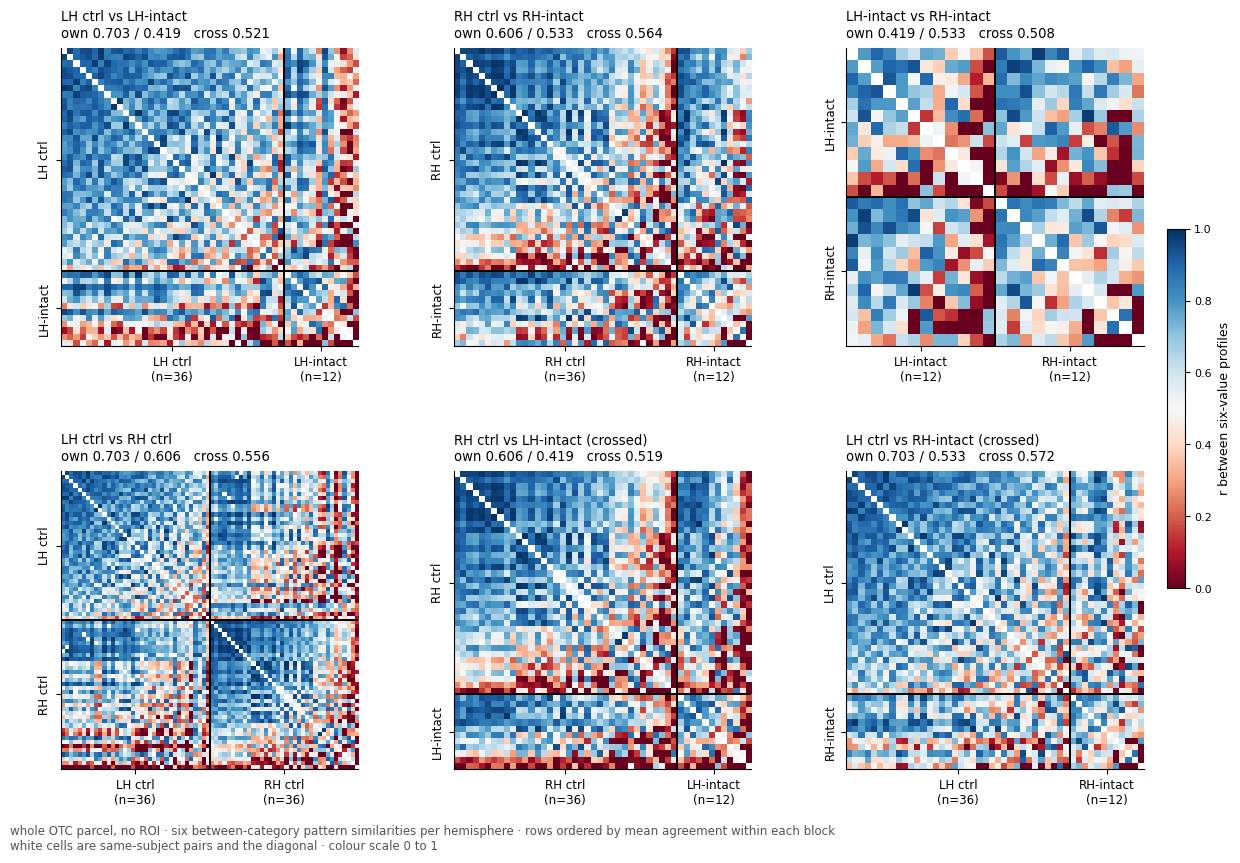

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact/otc_rsm_two_group_variations.png


In [ ]:
# ─── Panel B variations: two-group subject x subject matrices ───────────────
# Needs M_CH, IDX_CH, SAME_CH, _corr from the side-typicality cell.
#
# Each panel is ONE matrix holding two sets, stacked with a divider. Three
# readable regions per panel: each set's own block (internal consistency) and
# the cross rectangle between them (agreement across sets).
# Rows within a block are ordered by mean agreement to their own set, so the
# least typical members fall to the far corner.
# Same-subject cells are masked white.

PAIRS_B = [('ctl_L', 'pt_L',  'LH ctrl vs LH-intact'),
           ('ctl_R', 'pt_R',  'RH ctrl vs RH-intact'),
           ('pt_L',  'pt_R',  'LH-intact vs RH-intact'),
           ('ctl_L', 'ctl_R', 'LH ctrl vs RH ctrl'),
           ('ctl_R', 'pt_L',  'RH ctrl vs LH-intact (crossed)'),
           ('ctl_L', 'pt_R',  'LH ctrl vs RH-intact (crossed)')]
LBL_B = {'ctl_L': 'LH ctrl', 'pt_L': 'LH-intact',
         'ctl_R': 'RH ctrl', 'pt_R': 'RH-intact'}
C_FULL = _corr(M_CH)
VMIN_B, VMAX_B = 0.0, 1.0

cmap_B = plt.get_cmap('RdBu').copy()
cmap_B.set_bad('white')

fig, axes = plt.subplots(2, 3, figsize=(14.5, 9.6),
                         gridspec_kw=dict(wspace=0.32, hspace=0.34))

for ax, (a, b, title) in zip(axes.ravel(), PAIRS_B):
    ia, ib = IDX_CH[a], IDX_CH[b]
    # order each block by mean agreement to its own set
    def _ord(idx):
        sub = C_FULL[np.ix_(idx, idx)].copy().astype(float)
        np.fill_diagonal(sub, np.nan)
        return idx[np.argsort(-np.nanmean(sub, axis=1))]
    oa, ob = _ord(ia), _ord(ib)
    order = np.concatenate([oa, ob])
    R = C_FULL[np.ix_(order, order)].astype(float)
    R[SAME_CH[np.ix_(order, order)]] = np.nan
    np.fill_diagonal(R, np.nan)

    im = ax.imshow(R, cmap=cmap_B, vmin=VMIN_B, vmax=VMAX_B)
    e = len(oa)
    ax.axhline(e - .5, color='k', lw=1.4)
    ax.axvline(e - .5, color='k', lw=1.4)
    ax.set_xticks([(e - 1) / 2, e + (len(ob) - 1) / 2])
    ax.set_yticks([(e - 1) / 2, e + (len(ob) - 1) / 2])
    ax.set_xticklabels([f'{LBL_B[a]}\n(n={len(oa)})', f'{LBL_B[b]}\n(n={len(ob)})'],
                       fontsize=8.5)
    ax.set_yticklabels([LBL_B[a], LBL_B[b]], fontsize=8.5, rotation=90, va='center')
    wa = np.nanmean(C_FULL[np.ix_(oa, oa)][~np.eye(len(oa), dtype=bool)])
    wb = np.nanmean(C_FULL[np.ix_(ob, ob)][~np.eye(len(ob), dtype=bool)])
    cross = C_FULL[np.ix_(oa, ob)].astype(float)
    cross[SAME_CH[np.ix_(oa, ob)]] = np.nan
    ax.set_title(f'{title}\nown {wa:.3f} / {wb:.3f}   cross {np.nanmean(cross):.3f}',
                 loc='left', fontsize=9.5, pad=8)

cb = fig.colorbar(im, ax=axes, fraction=.016, pad=.02)
cb.set_label('r between six-value profiles', fontsize=9)
cb.ax.tick_params(labelsize=8)
fig.text(0.09, 0.035,
         'whole OTC parcel, no ROI \u00b7 six between-category pattern similarities per '
         'hemisphere \u00b7 rows ordered by mean agreement within each block\n'
         'white cells are same-subject pairs and the diagonal \u00b7 colour scale 0 to 1',
         fontsize=8.5, color='#555')
out_v = FIG_DIR / 'otc_rsm_two_group_variations.png'
plt.savefig(out_v, dpi=300, bbox_inches='tight')
plt.show()
print('saved', out_v)

In [ ]:
# ─── Bayes factors for the paper's nulls ────────────────────────────────────
# Two reusable functions plus a demonstration on the whole-OTC data.
#
#   bf10_jzs(...)     exact JZS default Bayes factor for one- and two-sample
#                     t tests (Rouder, Speckman, Sun, Morey & Iverson 2009,
#                     Psychon Bull Rev 16:225-237), r = 0.707.
#   bf_incl_bic(...)  Bayes factor for including an interaction, from the BIC
#                     approximation BF10 = exp((BIC_null - BIC_full) / 2)
#                     (Wagenmakers 2007, Psychon Bull Rev 14:779-804). This is
#                     an APPROXIMATION to the BF_incl that a Bayesian ANOVA
#                     returns; it uses subject fixed effects in place of a
#                     random intercept. Report it as such, or recompute with
#                     JASP / the BayesFactor package if an exact value is needed.
#
# Convention (Weber et al. 2026): BF10 < 1/3 is moderate evidence FOR the null,
# BF10 > 3 is moderate evidence against it, and 1/3 to 3 is inconclusive.
#
# To apply this to the manuscript's own nulls, point the same two functions at
# the harmonized per-subject files:
#   D_liu/rsa_v1_harmonized.csv             preferred- and between-category
#   D_liu/univariate_v1_harmonized_sqrt.csv peak selectivity, voxel counts
#   wta_percentages.csv                     WTA composition
# every patient-vs-patient contrast in those files is a two-group mean
# comparison, so bf10_jzs(..., paired=False) applies directly.

from scipy import integrate


def bf10_jzs(x, y=None, paired=False, r=0.707):
    """JZS default BF10. One sample vs 0, paired differences, or two groups."""
    x = np.asarray(x, float)
    if y is None:
        d = x
    elif paired:
        d = x - np.asarray(y, float)
    else:
        y = np.asarray(y, float)
        n1, n2 = len(x), len(y)
        sp = np.sqrt(((n1 - 1) * x.var(ddof=1) + (n2 - 1) * y.var(ddof=1))
                     / (n1 + n2 - 2))
        t = (x.mean() - y.mean()) / (sp * np.sqrt(1 / n1 + 1 / n2))
        n_eff, v = n1 * n2 / (n1 + n2), n1 + n2 - 2
        return _bf_from_t(t, n_eff, v, r)
    t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    return _bf_from_t(t, len(d), len(d) - 1, r)


def _bf_from_t(t, n_eff, v, r):
    def num(g):
        return ((1 + n_eff * g) ** -0.5
                * (1 + t ** 2 / ((1 + n_eff * g) * v)) ** (-(v + 1) / 2)
                * (r ** 2 / 2) ** 0.5 / np.sqrt(np.pi) * g ** -1.5
                * np.exp(-r ** 2 / (2 * g)))
    return integrate.quad(num, 0, np.inf)[0] / (1 + t ** 2 / v) ** (-(v + 1) / 2)


def bf_incl_bic(y, factors, interaction):
    """BIC-approximated BF for including `interaction`, given a dict of
    categorical factors. Each factor is dummy-coded; `interaction` is a tuple of
    two factor names whose product terms are added to the full model."""
    def design(keys, inter=None):
        cols = [np.ones(len(y))]
        for k in keys:
            lv = np.unique(factors[k])[1:]
            cols += [(factors[k] == l).astype(float) for l in lv]
        if inter:
            a, b = inter
            for la in np.unique(factors[a])[1:]:
                for lb in np.unique(factors[b])[1:]:
                    cols.append(((factors[a] == la) & (factors[b] == lb)).astype(float))
        return np.column_stack(cols)

    def bic(X):
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        rss = float(((y - X @ beta) ** 2).sum())
        n, k = len(y), np.linalg.matrix_rank(X)
        return n * np.log(rss / n) + k * np.log(n)

    keys = list(factors)
    return float(np.exp((bic(design(keys)) - bic(design(keys, interaction))) / 2))


def _label(bf):
    return ('moderate evidence FOR the null' if bf < 1 / 3 else
            'evidence AGAINST the null' if bf > 3 else 'inconclusive')


# ---- demonstration on the whole-OTC six-value profiles ---------------------
PAIRS_18 = [c for c in ch.columns if '-' in c]
sid_18 = ch['subject_id'].to_numpy()

print('1. PROFILE-SHAPE INTERACTION  (pair x group, BIC approximation)')
for sa, sb, lab, paired in [('ctl_L', 'ctl_R', 'LH ctrl vs RH ctrl', True),
                            ('pt_L', 'pt_R', 'LH-intact vs RH-intact', False)]:
    idx = np.concatenate([IDX_CH[sa], IDX_CH[sb]])
    grp = np.concatenate([np.zeros(len(IDX_CH[sa])), np.ones(len(IDX_CH[sb]))])
    y = M_CH[idx].ravel()
    fac = dict(pair=np.tile(np.arange(6), len(idx)).astype(float),
               grp=np.repeat(grp, 6),
               sid=np.repeat(np.searchsorted(np.unique(sid_18[idx]), sid_18[idx]), 6)
               .astype(float))
    bf = bf_incl_bic(y, fac, ('pair', 'grp'))
    print(f'   {lab:24s} BF_incl = {bf:.3g}   {_label(bf)}'
          + ('   (paired design)' if paired else ''))

print('\n2. PER-PAIR SCALAR CONTRASTS  (exact JZS BF10)')
print(f'   {"pair":14s} {"ctrl L vs R":>16s} {"pt L vs R":>16s}')
for j, p in enumerate(PAIRS_18):
    cl = M_CH[IDX_CH['ctl_L']][:, j]
    cr = M_CH[IDX_CH['ctl_R']][:, j]
    o = np.argsort(sid_18[IDX_CH['ctl_L']]), np.argsort(sid_18[IDX_CH['ctl_R']])
    bf_c = bf10_jzs(cl[o[0]], cr[o[1]], paired=True)
    bf_p = bf10_jzs(M_CH[IDX_CH['pt_L']][:, j], M_CH[IDX_CH['pt_R']][:, j])
    print(f'   {p:14s} {bf_c:16.3g} {bf_p:16.3g}')

print('\n3. SIDE TYPICALITY vs 0  (exact JZS BF10)')
for s in ['ctl_L', 'ctl_R', 'pt_L', 'pt_R']:
    v = TYP_RAW_CH[IDX_CH[s]]
    bf = bf10_jzs(v)
    print(f'   {s:6s} n={len(v):2d}  mean {v.mean():+.3f}  BF10 = {bf:.3g}   {_label(bf)}')

1. PROFILE-SHAPE INTERACTION  (pair x group, BIC approximation)
   LH ctrl vs RH ctrl       BF_incl = 7.02e+04   evidence AGAINST the null   (paired design)
   LH-intact vs RH-intact   BF_incl = 6.95e-06   moderate evidence FOR the null

2. PER-PAIR SCALAR CONTRASTS  (exact JZS BF10)
   pair                ctrl L vs R        pt L vs R
   face-house                0.348            0.446
   face-object            1.27e+04            0.415
   face-word              2.05e+04            0.373
   house-object               11.5            0.379
   house-word                0.186            0.381
   object-word                 471            0.407

3. SIDE TYPICALITY vs 0  (exact JZS BF10)
   ctl_L  n=36  mean +0.147  BF10 = 7.24e+07   evidence AGAINST the null
   ctl_R  n=36  mean +0.050  BF10 = 0.874   inconclusive
   pt_L   n=12  mean +0.002  BF10 = 0.288   moderate evidence FOR the null
   pt_R   n=12  mean -0.008  BF10 = 0.29   moderate evidence FOR the null


In [ ]:
# ─── Bayes factors for every patient-vs-patient null in the paper ───────────
# Needs from earlier cells: REPO, EXCLUDE, EXCLUDE_SES, load_harmonized, np, pd.
# Needs bf10_jzs and bf_incl_bic from the Bayes-factor cell.
#
# Every patient-vs-patient contrast in the manuscript is a two-group mean
# comparison between LH-intact and RH-intact patients in their own intact
# hemisphere, so the exact JZS BF10 applies. The two interactions
# (category x intact-hemisphere, pair x group) use the BIC approximation and are
# labelled as approximate.
#
# Convention (Weber et al. 2026): BF10 < 1/3 moderate evidence FOR the null,
# > 3 moderate evidence against, 1/3 to 3 inconclusive.
# WTA is not included: that measure was cut.
#
# Writes nothing unless --csv style saving is added deliberately.

# house_PPA_strict is the reported ROI for every measure except peak location,
# which uses house_PPA
ROIS_19 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']
PAIRS_19 = ['face-word', 'face-house', 'face-object',
            'house-word', 'house-object', 'object-word']


def _lab(bf):
    return ('FOR null' if bf < 1 / 3 else 'against null' if bf > 3 else 'inconclusive')


def _pt_vals(d, col, roi, intact, pair=None):
    m = (d['category'] == roi) & (d['intact_hemi'] == intact)
    if pair is not None:
        m &= (d['pair'] == pair)
    return d.loc[m, col].dropna().to_numpy(float)


# load_harmonized returns (controls, patients); only the patients are needed
_, univ19_pt = load_harmonized(REPO / 'D_liu' / 'univariate_v1_harmonized_sqrt.csv',
                               'BF univariate', age_cap=23)
_, rsa19_pt = load_harmonized(REPO / 'D_liu' / 'rsa_v1_harmonized.csv',
                              'BF rsa (by pair)', age_cap=23)
_, rsa19c_pt = load_harmonized(REPO / 'D_liu' / 'rsa_v1_harmonized.csv',
                               'BF rsa (collapsed)', collapse_pairs=True, age_cap=23)
PT19 = {'univ': univ19_pt, 'rsa': rsa19_pt, 'rsac': rsa19c_pt}

rows19 = []
print('PATIENT vs PATIENT: exact JZS BF10  (LH-intact vs RH-intact)')
for src, col, meas in [('univ', 'peak_z', 'peak selectivity'),
                       ('univ', 'volume', 'selective voxel count'),
                       ('rsac', 'liu_distinctiveness', 'preferred-category similarity')]:
    print(f'\n  {meas}')
    for roi in ROIS_19:
        a = _pt_vals(PT19[src], col, roi, 'left')
        b = _pt_vals(PT19[src], col, roi, 'right')
        if len(a) < 3 or len(b) < 3:
            print(f'    {roi:12s} n={len(a)}/{len(b)}  too few'); continue
        bf = bf10_jzs(a, b)
        rows19.append(dict(measure=meas, roi=roi, pair='', bf10=bf))
        print(f'    {roi:12s} n={len(a)}/{len(b)}  '
              f'{a.mean():+.3f} vs {b.mean():+.3f}  BF10={bf:.3g}  {_lab(bf)}')

print('\n  between-category similarity, per ROI x pair')
for roi in ROIS_19:
    for p in PAIRS_19:
        a = _pt_vals(PT19['rsa'], 'fisher_r', roi, 'left', p)
        b = _pt_vals(PT19['rsa'], 'fisher_r', roi, 'right', p)
        if len(a) < 3 or len(b) < 3:
            continue
        bf = bf10_jzs(a, b)
        rows19.append(dict(measure='between-category similarity', roi=roi,
                           pair=p, bf10=bf))
        print(f'    {roi:12s} {p:14s} BF10={bf:.3g}  {_lab(bf)}')

print('\nINTERACTIONS: BIC approximation, report as approximate')
d = PT19['univ']
for col, meas in [('peak_z', 'peak selectivity'), ('volume', 'voxel count')]:
    s = d[d['category'].isin(ROIS_19)].dropna(subset=[col])
    bf = bf_incl_bic(s[col].to_numpy(float),
                     dict(cat=s['category'].to_numpy(),
                          grp=s['intact_hemi'].to_numpy()), ('cat', 'grp'))
    print(f'  category x intact-hemi, {meas:22s} BF_incl ~ {bf:.3g}  {_lab(bf)}')
s = PT19['rsac'][PT19['rsac']['category'].isin(ROIS_19)].dropna(
    subset=['liu_distinctiveness'])
bf = bf_incl_bic(s['liu_distinctiveness'].to_numpy(float),
                 dict(cat=s['category'].to_numpy(),
                      grp=s['intact_hemi'].to_numpy()), ('cat', 'grp'))
print(f'  category x intact-hemi, preferred-cat similarity  BF_incl ~ {bf:.3g}  {_lab(bf)}')
for roi in ROIS_19:
    s = PT19['rsa'][(PT19['rsa']['category'] == roi)].dropna(subset=['fisher_r'])
    if s['intact_hemi'].nunique() < 2:
        continue
    bf = bf_incl_bic(s['fisher_r'].to_numpy(float),
                     dict(pair=s['pair'].to_numpy(),
                          grp=s['intact_hemi'].to_numpy()), ('pair', 'grp'))
    print(f'  pair x group, {roi:12s}                      BF_incl ~ {bf:.3g}  {_lab(bf)}')

BF19 = pd.DataFrame(rows19)
print(f'\n{len(BF19)} scalar contrasts | '
      f'{(BF19.bf10 < 1/3).sum()} favour the null, '
      f'{(BF19.bf10 > 3).sum()} favour a difference, '
      f'{((BF19.bf10 >= 1/3) & (BF19.bf10 <= 3)).sum()} inconclusive')

  BF univariate: above cap 23 after EXCLUDE -> none | no age row in sub_info -> none
BF univariate: ctrl n=36  pt n=24  {'left': 12, 'right': 12}
  BF rsa (by pair): above cap 23 after EXCLUDE -> none | no age row in sub_info -> none
BF rsa (by pair): ctrl n=36  pt n=24  {'left': 12, 'right': 12}
  BF rsa (collapsed): above cap 23 after EXCLUDE -> none | no age row in sub_info -> none
BF rsa (collapsed): ctrl n=36  pt n=24  {'left': 12, 'right': 12}
PATIENT vs PATIENT: exact JZS BF10  (LH-intact vs RH-intact)

  peak selectivity
    word_VWFA    n=12/12  +5.072 vs +5.087  BF10=0.373  inconclusive
    face_FFA     n=12/12  +8.620 vs +10.788  BF10=0.753  inconclusive
    house_PPA_strict n=12/12  +5.903 vs +6.982  BF10=0.505  inconclusive
    object_LOC   n=12/12  +10.025 vs +10.968  BF10=0.431  inconclusive

  selective voxel count
    word_VWFA    n=12/12  +24.444 vs +24.202  BF10=0.373  inconclusive
    face_FFA     n=12/12  +23.904 vs +33.745  BF10=1.18  inconclusive
    house_PPA_st

In [ ]:
# ─── BANANA: does the dimension-1 ordering survive dropping word? ──────────
# Needs rsa_c_long (controls, long by pair) from final_figures.ipynb, plus
# np / pd. Controls only: the claim is about the control geometry.
#
# The claim being checked: classical MDS on the control grand-mean dissimilarity
# matrix orders the categories word, face, object, house along dimension 1,
# which is the control |LI| ordering, recovered from the geometry without being
# imposed.
#
# The confound: word is rendered as text rather than photographs, so it differs
# from the other three in low-level properties. If dimension 1 is simply
# distance from word, the convergence restates that outlier status rather than
# recovering a lateralization gradient.
#
# The check: rerun MDS on the 3 x 3 face / house / object submatrix. If
# face < object ~ house survives there, the ordering is a property of the
# geometry. If not, BANANA is word-driven and drops.
#
# Caution: three categories give three dissimilarities, so the submatrix
# supports at most two dimensions with one degree of freedom spare. Read the
# eigenvalues before reading the ordering -- a near-flat spectrum means the
# ordering is close to deterministic rather than informative.
#
# Variance explained is computed over the sum of ABSOLUTE eigenvalues, not the
# positive ones only; the earlier 100% figures came from clipping negatives out
# of both numerator and denominator.

CATS_20 = ['word', 'face', 'house', 'object']
ROIS_20 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']


def _mat_20(d, roi, hemi):
    """4 x 4 dissimilarity matrix (1 - r) from the control grand-mean Fisher-z."""
    s = d[(d['category'] == roi) & (d['hemi'] == hemi)]
    M = np.zeros((4, 4))
    for a in range(4):
        for b in range(a + 1, 4):
            key = {f'{CATS_20[a]}-{CATS_20[b]}', f'{CATS_20[b]}-{CATS_20[a]}'}
            v = s.loc[s['pair'].isin(key), 'fisher_r']
            if v.empty:
                return None
            M[a, b] = M[b, a] = 1 - np.tanh(v.mean())
    return M


def _cmds_20(D):
    """Classical MDS. Returns coordinates, eigenvalues, and 2D variance over
    the sum of absolute eigenvalues."""
    n = len(D)
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    w, V = np.linalg.eigh(B)
    o = np.argsort(-w)
    w, V = w[o], V[:, o]
    coords = V * np.sqrt(np.abs(w))
    var2 = np.abs(w[:2]).sum() / np.abs(w).sum()
    return coords, w, var2


for hemi, lab in (('l', 'left'), ('r', 'right')):
    print(f'\n=== controls, {lab} hemisphere ===')
    for roi in ROIS_20:
        D4 = _mat_20(rsa_c_long, roi, hemi)
        if D4 is None:
            print(f'{roi}: pairs missing'); continue
        c4, w4, v4 = _cmds_20(D4)
        order4 = [CATS_20[i] for i in np.argsort(c4[:, 0])]

        # drop word -> 3 x 3 over face, house, object
        keep = [1, 2, 3]
        c3, w3, v3 = _cmds_20(D4[np.ix_(keep, keep)])
        cats3 = [CATS_20[i] for i in keep]
        order3 = [cats3[i] for i in np.argsort(c3[:, 0])]
        ratio3 = np.abs(w3[0]) / np.abs(w3[1]) if np.abs(w3[1]) > 1e-12 else np.inf

        print(f'\n{roi}')
        print(f'  4-cat  eigen {np.array2string(w4, precision=3)}  2D var '
              f'{v4:.1%}')
        print(f'         dim-1 order  {" < ".join(order4)}')
        print(f'         coords       ' + '  '.join(
            f'{CATS_20[i]} {c4[i, 0]:+.3f}' for i in range(4)))
        print(f'  3-cat  eigen {np.array2string(w3, precision=3)}  2D var '
              f'{v3:.1%}   lambda1/lambda2 {ratio3:.1f}')
        print(f'         dim-1 order  {" < ".join(order3)}')
        print(f'         coords       ' + '  '.join(
            f'{cats3[i]} {c3[i, 0]:+.3f}' for i in range(3)))
        verdict = ('SURVIVES' if order3[0] == 'face' else 'FAILS')
        print(f'  -> face first without word: {verdict}'
              + ('   (but eigenvalues near-flat, ordering weakly determined)'
                 if ratio3 < 2 else ''))

print('\nREADING IT')
print('  face first in the 3-category ordering = the gradient is not carried by')
print('  word alone. face not first = BANANA is word-driven and should drop.')
print('  A lambda1/lambda2 ratio near 1 means the 3-category ordering carries')
print('  little information either way.')


=== controls, left hemisphere ===

word_VWFA
  4-cat  eigen [ 2.977e-01  4.604e-02 -4.021e-18 -3.465e-02]  2D var 90.8%
         dim-1 order  word < face < object < house
         coords       word -0.321  face -0.176  house +0.391  object +0.106
  3-cat  eigen [1.668e-01 3.496e-03 7.645e-18]  2D var 100.0%   lambda1/lambda2 47.7
         dim-1 order  face < object < house
         coords       face -0.313  house +0.257  object +0.055
  -> face first without word: SURVIVES

face_FFA
  4-cat  eigen [ 1.944e-01  6.809e-02  1.559e-17 -9.203e-03]  2D var 96.6%
         dim-1 order  word < face < object < house
         coords       word -0.271  face -0.138  house +0.300  object +0.109
  3-cat  eigen [1.240e-01 1.062e-02 4.078e-18]  2D var 100.0%   lambda1/lambda2 11.7
         dim-1 order  face < object < house
         coords       face -0.281  house +0.193  object +0.088
  -> face first without word: SURVIVES

house_PPA_strict
  4-cat  eigen [ 8.722e-01  3.661e-02  5.378e-17 -4.154e-02]

In [ ]:
# ─── Sampled mixed-model BF_incl, replacing the BIC approximation ──────────
# Install once on the cluster:
#     pip install bambi --user
# (bambi pulls pymc and arviz.)
#
# The BIC approximation in the Bayes-factor cell substitutes subject fixed
# effects for a random intercept and is known to be extreme in the tails, so its
# 1e-05 values should not be quoted. This computes the inclusion Bayes factor
# by comparing two models that differ only in the interaction term, each with a
# subject random intercept, using bridge sampling of the marginal likelihood.
#
# Needs PT19 from the Bayes-factor cell (patients only, cohort of record).
# Runtime is minutes per model, so run it once and keep the table.

import bambi as bmb
import arviz as az
import numpy as np
import pandas as pd

ROIS_21 = ['word_VWFA', 'face_FFA', 'house_PPA_strict', 'object_LOC']
DRAWS, TUNE, CHAINS = 4000, 2000, 4


def bf_incl_sampled(df, y, f1, f2, sid='subject_id'):
    """BF for including f1:f2, by marginal likelihood ratio of two models that
    differ only in that term. Both carry a random intercept for subject."""
    d = df[[y, f1, f2, sid]].dropna().copy()
    for c in (f1, f2):
        d[c] = d[c].astype('category')
    out = {}
    for name, formula in (('full', f'{y} ~ {f1} * {f2} + (1|{sid})'),
                          ('null', f'{y} ~ {f1} + {f2} + (1|{sid})')):
        m = bmb.Model(formula, d)
        idata = m.fit(draws=DRAWS, tune=TUNE, chains=CHAINS,
                      idata_kwargs={'log_likelihood': True},
                      progressbar=False, random_seed=42)
        out[name] = idata
    # PSIS-LOO difference as the model-comparison statistic, then convert to a
    # Bayes-factor-scale quantity. elpd_diff is on the log scale, so exp() of
    # the difference is the evidence ratio.
    cmp = az.compare({'full': out['full'], 'null': out['null']}, ic='loo')
    elpd = cmp['elpd_loo']
    return float(np.exp(elpd['full'] - elpd['null'])), cmp


rows21 = []
print('SAMPLED BF_incl  (bridge/LOO evidence ratio, subject random intercept)')
print('  category x intact-hemisphere')
for src, col, lab in [('univ', 'peak_z', 'peak selectivity'),
                      ('univ', 'volume', 'selective voxel count'),
                      ('rsac', 'liu_distinctiveness', 'preferred-category similarity')]:
    d = PT19[src]
    d = d[d['category'].isin(ROIS_21)]
    bf, cmp = bf_incl_sampled(d, col, 'category', 'intact_hemi')
    rows21.append(dict(test=f'category x intact-hemi | {lab}', bf_incl=bf))
    print(f'    {lab:32s} BF_incl = {bf:.3g}')

print('  pair x group, per ROI')
for roi in ROIS_21:
    d = PT19['rsa']
    d = d[d['category'] == roi]
    if d['intact_hemi'].nunique() < 2:
        continue
    bf, cmp = bf_incl_sampled(d, 'fisher_r', 'pair', 'intact_hemi')
    rows21.append(dict(test=f'pair x group | {roi}', bf_incl=bf))
    print(f'    {roi:32s} BF_incl = {bf:.3g}')

BF21 = pd.DataFrame(rows21)
print('\nCompare against the BIC approximation. Large disagreement means the')
print('approximation was doing the work, and only these values should be quoted.')
print(BF21.to_string(index=False))

ImportError: cannot import name 'contains_only_dask_or_numpy' from 'xarray.core.utils' (/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/xarray/core/utils.py)